<a href="https://colab.research.google.com/github/na-jimenezc/API/blob/master/Proyecto%20Aprendizaje%20de%20M%C3%A1quina%20-%20Pruebas%20Saber%2011.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import datetime
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Dataset Empleado

El Dataset empleado fue extraído de https://www.datos.gov.co/Educaci-n/Resultados-nicos-Saber-11/kgxf-xxbe/about_data .

Este consta de los datos obtenidos de los resultados de las prueba saber 11 entre el periodo del 2010 al 2022. Se define por 50 columnas y 7.11 millones de filas de información.

Por el alto volumen de datos, desde el principio se decidió filtrar filas y recortar columnas, en las siguientes secciones se encuentran descritas en forma de diccionario la base de datos final que será empleada.

## Diccionario de Datos

Como fue mencionado anteriormente contamos con una base de datos extensa, descrita en el siguiente cuadro de código:

In [ ]:
diccionarioDatos = [
    {"campo": "periodo", "tipo": "Texto", "descripcion": "Año o periodo académico en el que se registraron los resultados."},
    {"campo": "estu_tipodocumento", "tipo": "Texto", "descripcion": "Tipo de documento de identidad del examinando (CC, TI, etc.)."},
    {"campo": "estu_consecutivo", "tipo": "Texto", "descripcion": "Código único que identifica al examinando en el sistema."},
    {"campo": "cole_area_ubicacion", "tipo": "Texto", "descripcion": "Área geográfica donde se encuentra la sede (urbana o rural)."},
    {"campo": "cole_bilingue", "tipo": "Texto", "descripcion": "Indica si el colegio es bilingüe (Sí/No)."},
    {"campo": "cole_calendario", "tipo": "Texto", "descripcion": "Tipo de calendario escolar (A, B, etc.)."},
    {"campo": "cole_caracter", "tipo": "Texto", "descripcion": "Carácter del colegio (académico, técnico, etc.)."},
    {"campo": "cole_cod_dane_establecimiento", "tipo": "Texto", "descripcion": "Código oficial DANE del establecimiento educativo."},
    {"campo": "cole_cod_dane_sede", "tipo": "Texto", "descripcion": "Código oficial DANE asignado a la sede específica."},
    {"campo": "cole_cod_depto_ubicacion", "tipo": "Texto", "descripcion": "Código del departamento donde está ubicada la sede."},
    {"campo": "cole_cod_mcpio_ubicacion", "tipo": "Texto", "descripcion": "Código del municipio donde está ubicada la sede."},
    {"campo": "cole_codigo_icfes", "tipo": "Texto", "descripcion": "Código asignado por el ICFES al establecimiento."},
    {"campo": "cole_depto_ubicacion", "tipo": "Texto", "descripcion": "Nombre del departamento donde está ubicada la sede."},
    {"campo": "cole_genero", "tipo": "Texto", "descripcion": "Tipo de población atendida (masculino, femenino, mixto)."},
    {"campo": "cole_jornada", "tipo": "Texto", "descripcion": "Jornada escolar (mañana, tarde, noche, completa)."},
    {"campo": "cole_mcpio_ubicacion", "tipo": "Texto", "descripcion": "Nombre del municipio donde se encuentra la sede."},
    {"campo": "cole_naturaleza", "tipo": "Texto", "descripcion": "Naturaleza jurídica (oficial, privado)."},
    {"campo": "cole_nombre_establecimiento", "tipo": "Texto", "descripcion": "Nombre completo del colegio."},
    {"campo": "cole_nombre_sede", "tipo": "Texto", "descripcion": "Nombre de la sede específica."},
    {"campo": "cole_sede_principal", "tipo": "Texto", "descripcion": "Indica si es la sede principal (Sí/No)."},
    {"campo": "estu_cod_depto_presentacion", "tipo": "Texto", "descripcion": "Código del departamento donde presentó el examen."},
    {"campo": "estu_cod_mcpio_presentacion", "tipo": "Texto", "descripcion": "Código del municipio donde presentó el examen."},
    {"campo": "estu_cod_reside_depto", "tipo": "Texto", "descripcion": "Código del departamento donde reside el examinando."},
    {"campo": "estu_cod_reside_mcpio", "tipo": "Texto", "descripcion": "Código del municipio donde reside el examinando."},
    {"campo": "estu_depto_presentacion", "tipo": "Texto", "descripcion": "Nombre del departamento donde presentó el examen."},
    {"campo": "estu_depto_reside", "tipo": "Texto", "descripcion": "Nombre del departamento donde reside el examinando."},
    {"campo": "estu_estadoinvestigacion", "tipo": "Texto", "descripcion": "Indica si permite el uso de sus datos (Sí/No)."},
    {"campo": "estu_estudiante", "tipo": "Texto", "descripcion": '"S" si es estudiante, "N" si es independiente.'},
    {"campo": "estu_fechanacimiento", "tipo": "Texto", "descripcion": "Fecha de nacimiento en formato YYYY-MM-DD."},
    {"campo": "estu_genero", "tipo": "Texto", "descripcion": "Género (Masculino/Femenino)."},
    {"campo": "estu_mcpio_presentacion", "tipo": "Texto", "descripcion": "Nombre del municipio donde presentó el examen."},
    {"campo": "estu_mcpio_reside", "tipo": "Texto", "descripcion": "Nombre del municipio donde reside el examinando."},
    {"campo": "estu_nacionalidad", "tipo": "Texto", "descripcion": "Nacionalidad del examinando."},
    {"campo": "estu_pais_reside", "tipo": "Texto", "descripcion": "País donde reside el examinando."},
    {"campo": "estu_privado_libertad", "tipo": "Texto", "descripcion": "Indica si está privado de la libertad (Sí/No)."},
    {"campo": "fami_cuartoshogar", "tipo": "Texto", "descripcion": "Cantidad de habitaciones en su hogar."},
    {"campo": "fami_educacionmadre", "tipo": "Texto", "descripcion": "Último nivel de estudios alcanzado por la madre."},
    {"campo": "fami_educacionpadre", "tipo": "Texto", "descripcion": "Último nivel de estudios alcanzado por el padre."},
    {"campo": "fami_estratovivienda", "tipo": "Texto", "descripcion": "Estrato de la vivienda del examinando (1-6)."},
    {"campo": "fami_personashogar", "tipo": "Texto", "descripcion": "Cantidad de personas con las que vive."},
    {"campo": "fami_tieneautomovil", "tipo": "Texto", "descripcion": "Indica si posee automóvil (Sí/No)."},
    {"campo": "fami_tienecomputador", "tipo": "Texto", "descripcion": "Indica si posee computador (Sí/No)."},
    {"campo": "fami_tieneinternet", "tipo": "Texto", "descripcion": "Indica si tiene acceso a internet (Sí/No)."},
    {"campo": "fami_tienelavadora", "tipo": "Texto", "descripcion": "Indica si posee lavadora (Sí/No)."},
    {"campo": "desemp_ingles", "tipo": "Texto", "descripcion": "Categoría de desempeño en inglés (A1, B1, B+, etc.)."},
    {"campo": "punt_ingles", "tipo": "Texto", "descripcion": "Puntaje obtenido en la prueba de inglés."},
    {"campo": "punt_matematicas", "tipo": "Texto", "descripcion": "Puntaje obtenido en la prueba de matemáticas."},
    {"campo": "punt_sociales_ciudadanas", "tipo": "Texto", "descripcion": "Puntaje obtenido en la prueba de sociales y ciudadanas."},
    {"campo": "punt_c_naturales", "tipo": "Texto", "descripcion": "Puntaje obtenido en la prueba de ciencias naturales."},
    {"campo": "punt_lectura_critica", "tipo": "Texto", "descripcion": "Puntaje obtenido en la prueba de lectura crítica."},
    {"campo": "punt_global", "tipo": "Texto", "descripcion": "Puntaje global obtenido."},
]

df_diccionario = pd.DataFrame(diccionarioDatos)

print("Diccionario de Datos:")
display(df_diccionario)

df_diccionario.to_csv("diccionario_datos.csv", index=False)
print("Archivo guardado en .csv")


Diccionario de Datos:


,campo,tipo,descripcion
0,periodo,Texto,Año o periodo académico en el que se registrar...
1,estu_tipodocumento,Texto,Tipo de documento de identidad del examinando ...
2,estu_consecutivo,Texto,Código único que identifica al examinando en e...
3,cole_area_ubicacion,Texto,Área geográfica donde se encuentra la sede (ur...
4,cole_bilingue,Texto,Indica si el colegio es bilingüe (Sí/No).
5,cole_calendario,Texto,"Tipo de calendario escolar (A, B, etc.)."
6,cole_caracter,Texto,"Carácter del colegio (académico, técnico, etc.)."
7,cole_cod_dane_establecimiento,Texto,Código oficial DANE del establecimiento educat...
8,cole_cod_dane_sede,Texto,Código oficial DANE asignado a la sede específ...
9,cole_cod_depto_ubicacion,Texto,Código del departamento donde está ubicada la ...


Archivo guardado en .csv


Tras realizar un análisis de las columnas, se decidieron recortar algunas por las siguientes razones:

* estu_tipodocument: identificador personal que no aporta información.
* estu_consecutivo: identificador del examen, totalmente irrelevante.
* cole_depto_ubicacion: ubicación redundante, se prioriza la residencia.
* cole_mcpio_ubicacion: ubicación redundante, se prioriza la residencia.
* cole_calendario: no se consideró para simplificar modelo.
* cole_cod_dane_establecimiento: identificador del colegio, no relevante
* cole_cod_depto_ubicacioo: redundante con el nombre del departamento.
* cole_cod_mcpio_ubicacion: redundante con el nombre del municipio.
* cole_codigo_icfes: identificador, irrelevante.
* cole_genero: no se consideró para simplificar modelo.
* cole_nombre_establecimiento: poca manejabilidad y complicaba el modelo.
* cole_nombre_sede: poca manejabilidad y complicaba el modelo.
* cole_sede_principal: variable irrelevante si no se considera la sede.
* estu_cod_depto_presentacion: redundante con el nombre del departamento.
* estu_cod_mcpio_presentacion: redundante con el nombre del municipio.
* estu_depto_presentacion: se priorizó la residencia del estudiante.
* estu_estadoinvestigacion: totalmente irrelevante.
* estu_estudiante: campo sin valor predictivo.
* stu_mcpio_presentacion: se priorizó la residencia.
* estu_nacionalidad: baja variabilidad, casi siempre es "Colombiana".
* estu_pais_reside: redundante por el contexto nacional.
* estu_privado_libertad: pocos casos de privados de libertad, baja representación.
* fami_cuartoshogar: no se consideró para simplificar modelo.
* fami_tieneautomovil: poca relación directa con desempeño académico.
* fami_tienelavadora: poca relación directa con desempeño académico.
* desemp_ingles: derivada del puntaje de Inglés.
* estu_depto_reside: redundante, preferimos quedarnos con el código del departamento.
* estu_mcpio_reside: redundante, preferimos quedarnos con el código del municipio.

## Justificación de Datos

Se redujeron de 51 a 25 columnas

In [ ]:
datosFinales = [
    {"campo": "periodo", "tipo": "Texto", "descripcion": "Año o periodo académico en el que se registraron los resultados."},
    {"campo": "cole_area_ubicacion", "tipo": "Texto", "descripcion": "Área geográfica donde se encuentra la sede (urbana o rural)."},
    {"campo": "cole_bilingue", "tipo": "Texto", "descripcion": "Indica si el colegio es bilingüe (Sí/No)."},
    {"campo": "cole_caracter", "tipo": "Texto", "descripcion": "Carácter del colegio (académico, técnico, etc.)."},
    {"campo": "cole_jornada", "tipo": "Texto", "descripcion": "Jornada escolar (mañana, tarde, noche, completa)."},
    {"campo": "cole_naturaleza", "tipo": "Texto", "descripcion": "Naturaleza jurídica (oficial, privado)."},
    {"campo": "estu_cod_reside_depto", "tipo": "Texto", "descripcion": "Código del departamento donde reside el examinando."},
    {"campo": "estu_cod_reside_mcpio", "tipo": "Texto", "descripcion": "Código del municipio donde reside el examinando."},
    {"campo": "estu_fechanacimiento", "tipo": "Texto", "descripcion": "Fecha de nacimiento en formato YYYY-MM-DD."},
    {"campo": "estu_genero", "tipo": "Texto", "descripcion": "Género (Masculino/Femenino)."},
    {"campo": "fami_educacionmadre", "tipo": "Texto", "descripcion": "Último nivel de estudios alcanzado por la madre."},
    {"campo": "fami_educacionpadre", "tipo": "Texto", "descripcion": "Último nivel de estudios alcanzado por el padre."},
    {"campo": "fami_estratovivienda", "tipo": "Texto", "descripcion": "Estrato de la vivienda del examinando (1-6)."},
    {"campo": "fami_personashogar", "tipo": "Texto", "descripcion": "Cantidad de personas con las que vive."},
    {"campo": "fami_tienecomputador", "tipo": "Texto", "descripcion": "Indica si posee computador (Sí/No)."},
    {"campo": "fami_tieneinternet", "tipo": "Texto", "descripcion": "Indica si tiene acceso a internet (Sí/No)."},
    {"campo": "fami_tienelavadora", "tipo": "Texto", "descripcion": "Indica si posee lavadora (Sí/No)."},
    {"campo": "desemp_ingles", "tipo": "Texto", "descripcion": "Categoría de desempeño en inglés (A1, B1, B+, etc.)."},
    {"campo": "punt_ingles", "tipo": "Texto", "descripcion": "Puntaje obtenido en la prueba de inglés."},
    {"campo": "punt_matematicas", "tipo": "Texto", "descripcion": "Puntaje obtenido en la prueba de matemáticas."},
    {"campo": "punt_sociales_ciudadanas", "tipo": "Texto", "descripcion": "Puntaje obtenido en la prueba de sociales y ciudadanas."},
    {"campo": "punt_c_naturales", "tipo": "Texto", "descripcion": "Puntaje obtenido en la prueba de ciencias naturales."},
    {"campo": "punt_lectura_critica", "tipo": "Texto", "descripcion": "Puntaje obtenido en la prueba de lectura crítica."},
    {"campo": "punt_global", "tipo": "Texto", "descripcion": "Puntaje global obtenido."},
]

df_diccionarioFinal = pd.DataFrame(datosFinales)

print("Diccionario de Datos Final:")
display(df_diccionarioFinal)

df_diccionarioFinal.to_csv("diccionario_datos.csv", index=False)
print("Archivo guardado en .csv")

Diccionario de Datos Final:


,campo,tipo,descripcion
0,periodo,Texto,Año o periodo académico en el que se registrar...
1,cole_area_ubicacion,Texto,Área geográfica donde se encuentra la sede (ur...
2,cole_bilingue,Texto,Indica si el colegio es bilingüe (Sí/No).
3,cole_caracter,Texto,"Carácter del colegio (académico, técnico, etc.)."
4,cole_jornada,Texto,"Jornada escolar (mañana, tarde, noche, completa)."
5,cole_naturaleza,Texto,"Naturaleza jurídica (oficial, privado)."
6,estu_cod_reside_depto,Texto,Código del departamento donde reside el examin...
7,estu_cod_reside_mcpio,Texto,Código del municipio donde reside el examinando.
8,estu_fechanacimiento,Texto,Fecha de nacimiento en formato YYYY-MM-DD.
9,estu_genero,Texto,Género (Masculino/Femenino).


Archivo guardado en .csv


#Preprocesamiento de datos

##Cargar los datos a un dataframe

In [ ]:
df00 = pd.read_csv('Resultados_únicos_Saber_11_20250827- 1085937.csv')

##Eliminar las columnas que no son relevantes según el analisis anterior

In [ ]:
desired_columns = [col_info['campo'].upper() for col_info in datosFinales]

current_columns = df00.columns.tolist()

columns_to_drop = [col for col in current_columns if col not in desired_columns]

df00 = df00.drop(columns=columns_to_drop)

# Display the remaining columns to confirm the changes
print("Columnas relevantes:")
display(df00.columns)

Columnas relevantes:


Index(['PERIODO', 'COLE_AREA_UBICACION', 'COLE_BILINGUE', 'COLE_CARACTER',
       'COLE_JORNADA', 'COLE_NATURALEZA', 'ESTU_COD_RESIDE_DEPTO',
       'ESTU_COD_RESIDE_MCPIO', 'ESTU_FECHANACIMIENTO', 'ESTU_GENERO',
       'FAMI_EDUCACIONMADRE', 'FAMI_EDUCACIONPADRE', 'FAMI_ESTRATOVIVIENDA',
       'FAMI_PERSONASHOGAR', 'FAMI_TIENECOMPUTADOR', 'FAMI_TIENEINTERNET',
       'FAMI_TIENELAVADORA', 'DESEMP_INGLES', 'PUNT_INGLES',
       'PUNT_MATEMATICAS', 'PUNT_SOCIALES_CIUDADANAS', 'PUNT_C_NATURALES',
       'PUNT_LECTURA_CRITICA', 'PUNT_GLOBAL'],
      dtype='object')

##Despliegue de datos

In [ ]:
pd.options.display.max_columns = None

display(df00)

,PERIODO,COLE_AREA_UBICACION,COLE_BILINGUE,COLE_CARACTER,COLE_JORNADA,COLE_NATURALEZA,ESTU_COD_RESIDE_DEPTO,ESTU_COD_RESIDE_MCPIO,ESTU_FECHANACIMIENTO,ESTU_GENERO,FAMI_EDUCACIONMADRE,FAMI_EDUCACIONPADRE,FAMI_ESTRATOVIVIENDA,FAMI_PERSONASHOGAR,FAMI_TIENECOMPUTADOR,FAMI_TIENEINTERNET,FAMI_TIENELAVADORA,DESEMP_INGLES,PUNT_INGLES,PUNT_MATEMATICAS,PUNT_SOCIALES_CIUDADANAS,PUNT_C_NATURALES,PUNT_LECTURA_CRITICA,PUNT_GLOBAL
0,20221,URBANO,NaN,ACADÉMICO,COMPLETA,NO OFICIAL,76.0,76520.0,27/06/2005,M,Educación profesional completa,Postgrado,Estrato 3,3 a 4,Si,Si,Si,B+,80.0,77,81,74,67,376
1,20221,RURAL,N,ACADÉMICO,COMPLETA,NO OFICIAL,76.0,76001.0,24/01/2005,M,Postgrado,Postgrado,Estrato 4,5 a 6,Si,Si,Si,B1,74.0,100,76,74,66,393
2,20221,URBANO,N,TÉCNICO/ACADÉMICO,COMPLETA,NO OFICIAL,76.0,76001.0,29/09/2006,F,Postgrado,Secundaria (Bachillerato) completa,Estrato 2,7 a 8,Si,Si,Si,B1,68.0,69,70,67,75,350
3,20221,URBANO,S,ACADÉMICO,COMPLETA,NO OFICIAL,11.0,11001.0,06/06/2004,F,Educación profesional completa,Postgrado,Estrato 6,5 a 6,Si,Si,Si,B1,78.0,63,62,64,58,315
4,20221,URBANO,N,TÉCNICO,MAÑANA,NO OFICIAL,76.0,76001.0,23/01/2006,F,Técnica o tecnológica completa,Técnica o tecnológica completa,Estrato 3,3 a 4,Si,Si,Si,B1,69.0,56,62,59,66,307
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1085932,20224,URBANO,N,ACADÉMICO,MAÑANA,OFICIAL,76.0,76109.0,14/09/2006,F,Secundaria (Bachillerato) completa,Primaria incompleta,Estrato 1,1 a 2,Si,Si,Si,A-,33.0,46,29,49,36,197
1085933,20224,URBANO,N,TÉCNICO,TARDE,OFICIAL,68.0,68276.0,16/06/2004,M,Secundaria (Bachillerato) completa,Secundaria (Bachillerato) completa,Estrato 1,3 a 4,Si,Si,Si,A1,51.0,64,52,60,58,290
1085934,20224,URBANO,N,ACADÉMICO,NOCHE,OFICIAL,5.0,5212.0,23/05/2002,F,Secundaria (Bachillerato) incompleta,Primaria incompleta,Estrato 2,5 a 6,No,Si,Si,A-,28.0,38,40,38,47,199
1085935,20224,URBANO,N,TÉCNICO/ACADÉMICO,UNICA,OFICIAL,41.0,41013.0,04/01/2005,M,Técnica o tecnológica completa,Educación profesional completa,Estrato 1,3 a 4,Si,Si,Si,A1,52.0,52,40,51,49,242


##Tipos de datos por cada columna

In [ ]:
#Tipos de Datos
df00.dtypes

,0
PERIODO,int64
COLE_AREA_UBICACION,object
COLE_BILINGUE,object
COLE_CARACTER,object
COLE_JORNADA,object
COLE_NATURALEZA,object
ESTU_COD_RESIDE_DEPTO,float64
ESTU_COD_RESIDE_MCPIO,float64
ESTU_FECHANACIMIENTO,object
ESTU_GENERO,object


##Casteo de datos

In [ ]:
# Castear periodo a category, ya que es una categoria
df00['PERIODO'] = df00['PERIODO'].astype('category')

#Castear cole_area_ubicacion a category
df00["COLE_AREA_UBICACION"] = df00["COLE_AREA_UBICACION"].astype('category')

#Castear cole_bilingue a boleano # S->True y N->False
df00['COLE_BILINGUE'] = df00['COLE_BILINGUE'].map({'S': True, 'N': False})

#Castear cole_caracter a category
df00["COLE_CARACTER"] = df00["COLE_CARACTER"].astype('category')

#Castear cole_jornada a category
df00["COLE_JORNADA"] = df00["COLE_JORNADA"].astype('category')

#Castear cole_naturaleza a category
df00["COLE_NATURALEZA"] = df00["COLE_NATURALEZA"].astype('category')

#Castear estu_cod_reside_depto y estudi_cpde_reside_mcpio a category
df00["ESTU_COD_RESIDE_DEPTO"] = df00["ESTU_COD_RESIDE_DEPTO"].astype('Int64').astype('category')
df00["ESTU_COD_RESIDE_MCPIO"] = df00["ESTU_COD_RESIDE_MCPIO"].astype('Int64').astype('category')

#Convertir estu_fechanacimiento a datetime
df00["ESTU_FECHANACIMIENTO"] = pd.to_datetime(df00["ESTU_FECHANACIMIENTO"], format='%d/%m/%Y', errors='coerce')

#Convertir estu_genero a category
df00['ESTU_GENERO'] = df00['ESTU_GENERO'].astype('category')

#Convertir fami_educacionmadre, fame_educacionpadre a category
df00['FAMI_EDUCACIONMADRE'] = df00['FAMI_EDUCACIONMADRE'].astype('category')
df00['FAMI_EDUCACIONPADRE'] = df00['FAMI_EDUCACIONPADRE'].astype('category')

#Convertir estrato_vivienda en category
df00['FAMI_ESTRATOVIVIENDA'] = df00['FAMI_ESTRATOVIVIENDA'].astype('category')

#Convertir fami_personashofar a category
df00['FAMI_PERSONASHOGAR'] = df00['FAMI_PERSONASHOGAR'].astype('category')

#Convertir fami_tienecomputador, fami_tieneinternet, fami_tienelavadora en bool
#Si -> true, No -> false
map = {'Si': True, 'No': False}

df00['FAMI_TIENEINTERNET'] = df00['FAMI_TIENEINTERNET'].map(map)
df00['FAMI_TIENECOMPUTADOR'] = df00['FAMI_TIENECOMPUTADOR'].map(map)
df00['FAMI_TIENELAVADORA'] = df00['FAMI_TIENELAVADORA'].map(map)

#Convertir desemp_ingles en category
df00['DESEMP_INGLES'] = df00['DESEMP_INGLES'].astype('category')

#Convertir punt_ingles, punt_matematicas, punt_sociales_ciudadanas, punt_c_naturales,
#punt_lectura_critica, punt_global a int

df00['PUNT_INGLES'] = df00['PUNT_INGLES'].astype('Int64')
df00['PUNT_MATEMATICAS'] = df00['PUNT_MATEMATICAS'].astype('Int64')
df00['PUNT_SOCIALES_CIUDADANAS'] = df00['PUNT_SOCIALES_CIUDADANAS'].astype('Int64')
df00['PUNT_C_NATURALES']= df00['PUNT_C_NATURALES'].astype('Int64')
df00['PUNT_LECTURA_CRITICA'] = df00['PUNT_LECTURA_CRITICA'].astype('Int64')
df00['PUNT_GLOBAL'] = df00['PUNT_GLOBAL'].astype('Int64')

# Verificar los tipos de datos actualizados
display(df00.dtypes)

,0
PERIODO,category
COLE_AREA_UBICACION,category
COLE_BILINGUE,object
COLE_CARACTER,category
COLE_JORNADA,category
COLE_NATURALEZA,category
ESTU_COD_RESIDE_DEPTO,category
ESTU_COD_RESIDE_MCPIO,category
ESTU_FECHANACIMIENTO,datetime64[ns]
ESTU_GENERO,category


In [ ]:
pd.options.display.max_columns = None

display(df00)

,PERIODO,COLE_AREA_UBICACION,COLE_BILINGUE,COLE_CARACTER,COLE_JORNADA,COLE_NATURALEZA,ESTU_COD_RESIDE_DEPTO,ESTU_COD_RESIDE_MCPIO,ESTU_FECHANACIMIENTO,ESTU_GENERO,FAMI_EDUCACIONMADRE,FAMI_EDUCACIONPADRE,FAMI_ESTRATOVIVIENDA,FAMI_PERSONASHOGAR,FAMI_TIENECOMPUTADOR,FAMI_TIENEINTERNET,FAMI_TIENELAVADORA,DESEMP_INGLES,PUNT_INGLES,PUNT_MATEMATICAS,PUNT_SOCIALES_CIUDADANAS,PUNT_C_NATURALES,PUNT_LECTURA_CRITICA,PUNT_GLOBAL
0,20221,URBANO,NaN,ACADÉMICO,COMPLETA,NO OFICIAL,76,76520,2005-06-27,M,Educación profesional completa,Postgrado,Estrato 3,3 a 4,True,True,True,B+,80,77,81,74,67,376
1,20221,RURAL,False,ACADÉMICO,COMPLETA,NO OFICIAL,76,76001,2005-01-24,M,Postgrado,Postgrado,Estrato 4,5 a 6,True,True,True,B1,74,100,76,74,66,393
2,20221,URBANO,False,TÉCNICO/ACADÉMICO,COMPLETA,NO OFICIAL,76,76001,2006-09-29,F,Postgrado,Secundaria (Bachillerato) completa,Estrato 2,7 a 8,True,True,True,B1,68,69,70,67,75,350
3,20221,URBANO,True,ACADÉMICO,COMPLETA,NO OFICIAL,11,11001,2004-06-06,F,Educación profesional completa,Postgrado,Estrato 6,5 a 6,True,True,True,B1,78,63,62,64,58,315
4,20221,URBANO,False,TÉCNICO,MAÑANA,NO OFICIAL,76,76001,2006-01-23,F,Técnica o tecnológica completa,Técnica o tecnológica completa,Estrato 3,3 a 4,True,True,True,B1,69,56,62,59,66,307
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1085932,20224,URBANO,False,ACADÉMICO,MAÑANA,OFICIAL,76,76109,2006-09-14,F,Secundaria (Bachillerato) completa,Primaria incompleta,Estrato 1,1 a 2,True,True,True,A-,33,46,29,49,36,197
1085933,20224,URBANO,False,TÉCNICO,TARDE,OFICIAL,68,68276,2004-06-16,M,Secundaria (Bachillerato) completa,Secundaria (Bachillerato) completa,Estrato 1,3 a 4,True,True,True,A1,51,64,52,60,58,290
1085934,20224,URBANO,False,ACADÉMICO,NOCHE,OFICIAL,5,5212,2002-05-23,F,Secundaria (Bachillerato) incompleta,Primaria incompleta,Estrato 2,5 a 6,False,True,True,A-,28,38,40,38,47,199
1085935,20224,URBANO,False,TÉCNICO/ACADÉMICO,UNICA,OFICIAL,41,41013,2005-01-04,M,Técnica o tecnológica completa,Educación profesional completa,Estrato 1,3 a 4,True,True,True,A1,52,52,40,51,49,242


##Dimensionalidad del df

In [ ]:
#Cantidad total de registros

df00.shape

(1085937, 24)

##Cantidad de nulos

In [ ]:
print("Cantidad y porcentaje de valores nulos por columna (ordenado por porcentaje de mayor a menor):")

null_counts = df00.isnull().sum()
null_percentages = (null_counts / len(df00)) * 100

null_info = pd.DataFrame({
    'Cantidad de nulos': null_counts,
    'Porcentaje de nulos': null_percentages
})

null_info_sorted = null_info.sort_values(by='Porcentaje de nulos', ascending=False)

null_info_sorted['Porcentaje de nulos'] = null_info_sorted['Porcentaje de nulos'].map('{:.2f}%'.format)

print(null_info_sorted)

Cantidad y porcentaje de valores nulos por columna (ordenado por porcentaje de mayor a menor):
                          Cantidad de nulos Porcentaje de nulos
COLE_BILINGUE                        197035              18.14%
FAMI_ESTRATOVIVIENDA                  72891               6.71%
FAMI_TIENEINTERNET                    64279               5.92%
FAMI_EDUCACIONMADRE                   62979               5.80%
FAMI_EDUCACIONPADRE                   62762               5.78%
FAMI_TIENELAVADORA                    48087               4.43%
FAMI_TIENECOMPUTADOR                  47940               4.41%
FAMI_PERSONASHOGAR                    46541               4.29%
COLE_CARACTER                         43426               4.00%
DESEMP_INGLES                          4058               0.37%
PUNT_INGLES                            4058               0.37%
ESTU_FECHANACIMIENTO                    178               0.02%
ESTU_GENERO                              10               0.00%
ESTU_COD_

##Tratamiento de nulos

Para rellenar los nulos de cole_bilingue se usa false, se asume que estos no son bilingues

In [ ]:
# Rellenar valores nulos en la columna 'COLE_BILINGUE' con False (equivalente a 'N' en bool)
df00['COLE_BILINGUE'] = df00['COLE_BILINGUE'].fillna(False)

# Verificar los nulos después de la imputación
print("Cantidad de nulos en COLE_BILINGUE después de imputación:")
print(df00['COLE_BILINGUE'].isnull().sum())

Cantidad de nulos en COLE_BILINGUE después de imputación:
0


Para rellenar los nulos de cole_caracter se utiliza la categoria de no especificado

In [ ]:
# Agregar una nueva categoria 'COLE_CARACTER'
df00['COLE_CARACTER'] = df00['COLE_CARACTER'].cat.add_categories('NO ESPECIFICADO')

# Rellenar valores nulos en la columna 'COLE_CARACTER' con 'NO ESPECIFICADO'
df00['COLE_CARACTER'] = df00['COLE_CARACTER'].fillna('NO ESPECIFICADO')

# Verificar los nulos después de la imputación
print("Cantidad de nulos en COLE_CARACTER después de imputación:")
print(df00['COLE_CARACTER'].isnull().sum())

Cantidad de nulos en COLE_CARACTER después de imputación:
0


Para saber la forma correcta de tratar los nulos en el codigo de departamento y municipio, es importante resolver una duda, si ambos cuentan con la misma cantidad de nulos, ¿se tratan de los mismos registros?

In [ ]:
missing_depto_rows = df00[df00['ESTU_COD_RESIDE_DEPTO'].isnull()]

print("\nRegistros con valores nulos en la columna ESTU_COD_RESIDE_DEPTO:")
display(missing_depto_rows)

missing_mcpio_rows = df00[df00['ESTU_COD_RESIDE_MCPIO'].isnull()]

print("\nRegistros con valores nulos en la columna ESTU_COD_RESIDE_MCPIO:")
display(missing_mcpio_rows)


Registros con valores nulos en la columna ESTU_COD_RESIDE_DEPTO:


,PERIODO,COLE_AREA_UBICACION,COLE_BILINGUE,COLE_CARACTER,COLE_JORNADA,COLE_NATURALEZA,ESTU_COD_RESIDE_DEPTO,ESTU_COD_RESIDE_MCPIO,ESTU_FECHANACIMIENTO,ESTU_GENERO,FAMI_EDUCACIONMADRE,FAMI_EDUCACIONPADRE,FAMI_ESTRATOVIVIENDA,FAMI_PERSONASHOGAR,FAMI_TIENECOMPUTADOR,FAMI_TIENEINTERNET,FAMI_TIENELAVADORA,DESEMP_INGLES,PUNT_INGLES,PUNT_MATEMATICAS,PUNT_SOCIALES_CIUDADANAS,PUNT_C_NATURALES,PUNT_LECTURA_CRITICA,PUNT_GLOBAL
315,20221,RURAL,False,NO ESPECIFICADO,MAÑANA,NO OFICIAL,NaN,NaN,2005-02-04,F,Educación profesional completa,Educación profesional completa,Estrato 5,5 a 6,True,True,True,B+,83,61,49,51,59,286
1226,20221,URBANO,False,ACADÉMICO,MAÑANA,NO OFICIAL,NaN,NaN,2005-03-22,F,Secundaria (Bachillerato) incompleta,Secundaria (Bachillerato) incompleta,Estrato 1,3 a 4,False,True,False,A-,38,42,43,45,44,215
2246,20221,URBANO,False,NO ESPECIFICADO,SABATINA,NO OFICIAL,NaN,NaN,2004-10-01,M,Educación profesional incompleta,Secundaria (Bachillerato) completa,Estrato 1,5 a 6,False,False,True,A-,44,32,36,41,36,184
6425,20221,URBANO,False,TÉCNICO/ACADÉMICO,MAÑANA,OFICIAL,NaN,NaN,2021-03-10,F,Educación profesional incompleta,Secundaria (Bachillerato) completa,Estrato 1,3 a 4,True,False,True,A1,50,51,54,49,52,257
8577,20221,URBANO,False,NO ESPECIFICADO,TARDE,NO OFICIAL,NaN,NaN,2004-06-12,M,Secundaria (Bachillerato) completa,Técnica o tecnológica completa,Estrato 1,1 a 2,True,True,True,B1,70,60,47,41,68,276
13259,20221,URBANO,False,NO ESPECIFICADO,SABATINA,NO OFICIAL,NaN,NaN,2004-06-04,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A-,41,36,43,45,42,207
14889,20221,URBANO,False,NO ESPECIFICADO,COMPLETA,NO OFICIAL,NaN,NaN,2004-01-08,F,No sabe,No sabe,Estrato 5,5 a 6,True,True,True,B1,75,52,56,59,63,294
286944,20224,URBANO,False,ACADÉMICO,SABATINA,NO OFICIAL,NaN,NaN,2005-01-05,F,Primaria incompleta,Primaria incompleta,Estrato 1,3 a 4,False,False,True,A1,48,51,47,41,48,234
816559,20224,URBANO,False,ACADÉMICO,SABATINA,NO OFICIAL,NaN,NaN,2005-01-05,F,Primaria incompleta,Primaria incompleta,Estrato 1,3 a 4,False,False,True,A1,48,51,47,41,48,234



Registros con valores nulos en la columna ESTU_COD_RESIDE_MCPIO:


,PERIODO,COLE_AREA_UBICACION,COLE_BILINGUE,COLE_CARACTER,COLE_JORNADA,COLE_NATURALEZA,ESTU_COD_RESIDE_DEPTO,ESTU_COD_RESIDE_MCPIO,ESTU_FECHANACIMIENTO,ESTU_GENERO,FAMI_EDUCACIONMADRE,FAMI_EDUCACIONPADRE,FAMI_ESTRATOVIVIENDA,FAMI_PERSONASHOGAR,FAMI_TIENECOMPUTADOR,FAMI_TIENEINTERNET,FAMI_TIENELAVADORA,DESEMP_INGLES,PUNT_INGLES,PUNT_MATEMATICAS,PUNT_SOCIALES_CIUDADANAS,PUNT_C_NATURALES,PUNT_LECTURA_CRITICA,PUNT_GLOBAL
315,20221,RURAL,False,NO ESPECIFICADO,MAÑANA,NO OFICIAL,NaN,NaN,2005-02-04,F,Educación profesional completa,Educación profesional completa,Estrato 5,5 a 6,True,True,True,B+,83,61,49,51,59,286
1226,20221,URBANO,False,ACADÉMICO,MAÑANA,NO OFICIAL,NaN,NaN,2005-03-22,F,Secundaria (Bachillerato) incompleta,Secundaria (Bachillerato) incompleta,Estrato 1,3 a 4,False,True,False,A-,38,42,43,45,44,215
2246,20221,URBANO,False,NO ESPECIFICADO,SABATINA,NO OFICIAL,NaN,NaN,2004-10-01,M,Educación profesional incompleta,Secundaria (Bachillerato) completa,Estrato 1,5 a 6,False,False,True,A-,44,32,36,41,36,184
6425,20221,URBANO,False,TÉCNICO/ACADÉMICO,MAÑANA,OFICIAL,NaN,NaN,2021-03-10,F,Educación profesional incompleta,Secundaria (Bachillerato) completa,Estrato 1,3 a 4,True,False,True,A1,50,51,54,49,52,257
8577,20221,URBANO,False,NO ESPECIFICADO,TARDE,NO OFICIAL,NaN,NaN,2004-06-12,M,Secundaria (Bachillerato) completa,Técnica o tecnológica completa,Estrato 1,1 a 2,True,True,True,B1,70,60,47,41,68,276
13259,20221,URBANO,False,NO ESPECIFICADO,SABATINA,NO OFICIAL,NaN,NaN,2004-06-04,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A-,41,36,43,45,42,207
14889,20221,URBANO,False,NO ESPECIFICADO,COMPLETA,NO OFICIAL,NaN,NaN,2004-01-08,F,No sabe,No sabe,Estrato 5,5 a 6,True,True,True,B1,75,52,56,59,63,294
286944,20224,URBANO,False,ACADÉMICO,SABATINA,NO OFICIAL,NaN,NaN,2005-01-05,F,Primaria incompleta,Primaria incompleta,Estrato 1,3 a 4,False,False,True,A1,48,51,47,41,48,234
816559,20224,URBANO,False,ACADÉMICO,SABATINA,NO OFICIAL,NaN,NaN,2005-01-05,F,Primaria incompleta,Primaria incompleta,Estrato 1,3 a 4,False,False,True,A1,48,51,47,41,48,234


Se confirma que se tratan de los mismos registros, por lo que se opta por empezar rellenando los espacios de departamentos con el que sea mas comun

In [ ]:
# Rellenar valores nulos en la columna 'ESTU_COD_RESIDE_DEPTO' con la moda
df00['ESTU_COD_RESIDE_DEPTO'] = df00['ESTU_COD_RESIDE_DEPTO'].fillna(df00['ESTU_COD_RESIDE_DEPTO'].mode()[0])

print("Se llenaran los nulos con el valor: ", df00['ESTU_COD_RESIDE_DEPTO'].mode()[0])

# Verificar los nulos después de la imputación
print("Cantidad de nulos en ESTU_COD_RESIDE_DEPTO después de imputación:")
print(df00['ESTU_COD_RESIDE_DEPTO'].isnull().sum())

Se llenaran los nulos con el valor:  11
Cantidad de nulos en ESTU_COD_RESIDE_DEPTO después de imputación:
0


Para que el llenado tenga sentido, se procede a mirar cual es el codigo de municipio mas comun entre los municipios relacionados al departamento 11

In [ ]:
# Calcular la moda del departamento de residencia
moda_depto = df00['ESTU_COD_RESIDE_DEPTO'].mode()[0]

# Filtrar el DataFrame por la moda del departamento
df_moda_depto = df00[df00['ESTU_COD_RESIDE_DEPTO'] == moda_depto]

# Encontrar los códigos de municipio más comunes en ese departamento
municipios_comunes = df_moda_depto['ESTU_COD_RESIDE_MCPIO'].value_counts().head(10)

# El municipio mas comun asociado con el departamento mas comun
moda_mcpio_depto = municipios_comunes.index[0]
print(f"\nEl código de municipio más común asociado con el departamento {moda_depto} es: {moda_mcpio_depto}")



El código de municipio más común asociado con el departamento 11 es: 11001


Se observa que el valor mas comun asociado con el departamento 11 es 11001, por lo que se usara este valor para rellenar los nulos

In [ ]:
# Rellenar valores nulos en la columna 'ESTU_COD_RESIDE_DEPTO' con la moda
df00['ESTU_COD_RESIDE_MCPIO'] = df00['ESTU_COD_RESIDE_MCPIO'].fillna(moda_mcpio_depto)

# Verificar los nulos después de la imputación
print("Cantidad de nulos en ESTU_COD_RESIDE_MCPIO después de imputación:")
print(df00['ESTU_COD_RESIDE_MCPIO'].isnull().sum())

Cantidad de nulos en ESTU_COD_RESIDE_MCPIO después de imputación:
0


Para la fecha de nacimiento realmente no es relavante tratar los nulos, pero en la edad si es importante, por lo que se creara una nueva variable llamada edad, y luego se llenaran los nulos con el promedio

In [ ]:
# Convert 'ESTU_FECHANACIMIENTO' to datetime objects, coercing errors
df00['ESTU_FECHANACIMIENTO'] = pd.to_datetime(df00['ESTU_FECHANACIMIENTO'], format='%d/%m/%Y', errors='coerce')

# Extract the year from the 'PERIODO' column (assuming the year is the first 4 digits)
df00['EXAM_YEAR'] = df00['PERIODO'].astype(str).str[:4].astype(int)

# Calculate age in years at the time of the exam
df00['EDAD'] = (df00['EXAM_YEAR'] - df00['ESTU_FECHANACIMIENTO'].dt.year).astype('Int64') # Use Int64 for nullable integer

# Calculate the mean age, excluding nulls
mean_age = df00['EDAD'].mean()

# Fill null values in 'EDAD' with the mean age
df00['EDAD'] = df00['EDAD'].fillna(int(mean_age)) # Fill with integer mean

print("\nCantidad de nulos en EDAD después de la imputación:")
print(df00['EDAD'].isnull().sum())


Cantidad de nulos en EDAD después de la imputación:
0


Ahora que existe la columna de edad, se puede eliminar la columna de estu_fechanacimiento y exam_year

In [ ]:
df00 = df00.drop(columns=['ESTU_FECHANACIMIENTO'])

In [ ]:
df00 = df00.drop(columns=['EXAM_YEAR'])

Para rellenar los nulos de estu_genero, se llenan con la moda

In [ ]:
# Rellenar valores nulos en la columna 'ESTU_GENERO' con la moda
df00['ESTU_GENERO'] = df00['ESTU_GENERO'].fillna(df00['ESTU_GENERO'].mode()[0])

# Verificar los nulos después de la imputación
print("Cantidad de nulos en ESTU_GENERO después de imputación:")
print(df00['ESTU_GENERO'].isnull().sum())

Cantidad de nulos en ESTU_GENERO después de imputación:
0


Para rellenar los nulos de fami_educacionmadre y fami_educacuonpadre se rellena con la categoria 'No sabe'

In [ ]:
# Rellenar valores nulos en la columna 'FAMI_EDUCACIONMADRE' con 'No sabe'
df00['FAMI_EDUCACIONMADRE'] = df00['FAMI_EDUCACIONMADRE'].fillna('No sabe')

# Verificar los nulos después de la imputación
print("Cantidad de nulos en FAMI_EDUCACIONMADRE después de imputación:")
print(df00['FAMI_EDUCACIONMADRE'].isnull().sum())

Cantidad de nulos en FAMI_EDUCACIONMADRE después de imputación:
0


In [ ]:
# Rellenar valores nulos en la columna 'FAMI_EDUCACIONPADRE' con 'No sabe'
df00['FAMI_EDUCACIONPADRE']= df00['FAMI_EDUCACIONPADRE'].fillna('No sabe')

# Verificar los nulos después de la imputación
print("Cantidad de nulos en FAMI_EDUCACIONPADRE después de imputación:")
print(df00['FAMI_EDUCACIONPADRE'].isnull().sum())

Cantidad de nulos en FAMI_EDUCACIONPADRE después de imputación:
0


Para rellenar los nulos de fami_estratovivienda, se toma el dato mas común segun el municipio que tenga aquel registro

In [ ]:
df00['FAMI_ESTRATOVIVIENDA'] = df00.groupby('ESTU_COD_RESIDE_MCPIO')['FAMI_ESTRATOVIVIENDA'].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else x.iloc[0]))

print("Cantidad de nulos en FAMI_ESTRATOVIVIENDA después de imputación:")
print(df00['FAMI_ESTRATOVIVIENDA'].isnull().sum())

Cantidad de nulos en FAMI_ESTRATOVIVIENDA después de imputación:
0


Para rellenar los nulos en cole_area_ubicacion, se toma el dato mas comun segun el municipio que tenga aquel registro

In [ ]:
df00['COLE_AREA_UBICACION'] = df00.groupby('ESTU_COD_RESIDE_MCPIO')['COLE_AREA_UBICACION'].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else x.iloc[0]))

print("Cantidad de nulos en COLE_AREA_UBICACION después de imputación:")
print(df00['COLE_AREA_UBICACION'].isnull().sum())

Cantidad de nulos en COLE_AREA_UBICACION después de imputación:
0


Para rellenar los nulos de fami_tieneinternet, fami_tienelavadora y fami_tienecomputador se pone el valor mas común según el estrato de donde vive el estudiante

In [ ]:
df00['FAMI_TIENEINTERNET'] = df00.groupby('FAMI_ESTRATOVIVIENDA')['FAMI_TIENEINTERNET'].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else x.iloc[0]))

print("Cantidad de nulos en FAMI_TIENEINTERNET después de imputación:")
print(df00['FAMI_TIENEINTERNET'].isnull().sum())

Cantidad de nulos en FAMI_TIENEINTERNET después de imputación:
0


In [ ]:
df00['FAMI_TIENELAVADORA'] = df00.groupby('FAMI_ESTRATOVIVIENDA')['FAMI_TIENELAVADORA'].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else x.iloc[0]))

print("Cantidad de nulos en FAMI_TIENELAVADORA después de imputación:")
print(df00['FAMI_TIENELAVADORA'].isnull().sum())

Cantidad de nulos en FAMI_TIENELAVADORA después de imputación:
0


In [ ]:
df00['FAMI_TIENECOMPUTADOR'] = df00.groupby('FAMI_ESTRATOVIVIENDA')['FAMI_TIENECOMPUTADOR'].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else x.iloc[0]))

print("Cantidad de nulos en FAMI_TIENECOMPUTADOR después de imputación:")
print(df00['FAMI_TIENECOMPUTADOR'].isnull().sum())

Cantidad de nulos en FAMI_TIENECOMPUTADOR después de imputación:
0


Para llenar los nulos de fami_personashogar, se toma la moda segun el municipio del estudiante, ya que los hogares de un mismo municipio comparten caracteristicas socioeconomicas y culturales similares que se reflejan en un tamaño de hogar comparable

In [ ]:
df00['FAMI_PERSONASHOGAR'] = df00.groupby('ESTU_COD_RESIDE_MCPIO')['FAMI_PERSONASHOGAR'].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else x.iloc[0]))

print("Cantidad de nulos en FAMI_PERSONASHOGAR después de imputación:")
print(df00['FAMI_PERSONASHOGAR'].isnull().sum())

Cantidad de nulos en FAMI_PERSONASHOGAR después de imputación:
0


Para rellenar los valores de desemp_ingles y punt_ingles surgue una pregunta, ambos tienen la misma cantidad de nulos, entonces, ¿Son los mismos registros?

In [ ]:
# Get the indices of rows with nulls in 'DESEMP_INGLES'
null_desemp_indices = df00[df00['DESEMP_INGLES'].isnull()].index

# Get the indices of rows with nulls in 'PUNT_INGLES'
null_punt_indices = df00[df00['PUNT_INGLES'].isnull()].index

# Check if the sets of indices are the same
are_indices_same = null_desemp_indices.equals(null_punt_indices)

if are_indices_same:
    print("Son los mismos registros")
else:
    print("No son los mismos registros")

Son los mismos registros


Como son los mismos registros, la opción mas segura es eliminar estos registros, ya que es muy dificil deducir estos valores a traves de otras columnas

In [ ]:
df00 = df00.dropna(subset=['DESEMP_INGLES'])

Para rellenar los nulos de cole_naturaleza y cole_jornada se utiliza la moda de estas columnas

In [ ]:
# Rellenar valores nulos en la columna 'COLE_NATURALEZA' con la moda
df00['COLE_NATURALEZA'] = df00['COLE_NATURALEZA'].fillna(df00['COLE_NATURALEZA'].mode()[0])

# Verificar los nulos después de la imputación
print("Cantidad de nulos en COLE_NATURALEZA después de imputación:")
print(df00['COLE_NATURALEZA'].isnull().sum())

Cantidad de nulos en COLE_NATURALEZA después de imputación:
0


In [ ]:
# Rellenar valores nulos en la columna 'COLE_JORNADA' con la moda
df00['COLE_JORNADA'] = df00['COLE_JORNADA'].fillna(df00['COLE_JORNADA'].mode()[0])

# Verificar los nulos después de la imputación
print("Cantidad de nulos en COLE_JORNADA después de imputación:")
print(df00['COLE_JORNADA'].isnull().sum())

Cantidad de nulos en COLE_JORNADA después de imputación:
0


Se vuelven a revisar la cantidad de nulos

In [ ]:
print("Cantidad y porcentaje de valores nulos por columna (ordenado por porcentaje de mayor a menor):")

null_counts = df00.isnull().sum()
null_percentages = (null_counts / len(df00)) * 100

null_info = pd.DataFrame({
    'Cantidad de nulos': null_counts,
    'Porcentaje de nulos': null_percentages
})

null_info_sorted = null_info.sort_values(by='Porcentaje de nulos', ascending=False)

null_info_sorted['Porcentaje de nulos'] = null_info_sorted['Porcentaje de nulos'].map('{:.2f}%'.format)

print(null_info_sorted)

Cantidad y porcentaje de valores nulos por columna (ordenado por porcentaje de mayor a menor):
                          Cantidad de nulos Porcentaje de nulos
PERIODO                                   0               0.00%
COLE_AREA_UBICACION                       0               0.00%
COLE_BILINGUE                             0               0.00%
COLE_CARACTER                             0               0.00%
COLE_JORNADA                              0               0.00%
COLE_NATURALEZA                           0               0.00%
ESTU_COD_RESIDE_DEPTO                     0               0.00%
ESTU_COD_RESIDE_MCPIO                     0               0.00%
ESTU_GENERO                               0               0.00%
FAMI_EDUCACIONMADRE                       0               0.00%
FAMI_EDUCACIONPADRE                       0               0.00%
FAMI_ESTRATOVIVIENDA                      0               0.00%
FAMI_PERSONASHOGAR                        0               0.00%
FAMI_TIEN

##Eliminar duplicados

In [ ]:
df00.drop_duplicates(inplace=True)

In [ ]:
df00.shape

(550760, 24)

##Revisión de carateres especiales

In [ ]:
for col in df00.columns:
    if df00[col].dtype == 'object':
        # Modified regex to check for characters outside the standard ASCII printable range
        special_chars_rows = df00[df00[col].astype(str).str.contains(r'[^\x20-\x7E]', regex=True, na=False)]
        if not special_chars_rows.empty:
            print(f"Caracteres especiales o no ASCII encontrados en la columna '{col}':")
            display(special_chars_rows[[col]])

No existen caracteres especiales que afecten la lectura de los datos

##Guardar csv con encodig uft-8
Esto se hace para asegurar  de que no queden caracteres especiales que afecten la lectura

In [ ]:
df00.to_csv('Resultados_icfes_limpios.csv', index=False, encoding='utf-8')

#EDA



In [ ]:
import numpy as np

# Use the existing df00 DataFrame
df_prediccion = df00.copy()

# Define the predictor variables (X) and the target variable (y)
# Exclude the target variable(s) and any identifiers or variables
# that are not intended as predictors from the feature list.
# Also exclude the clustering results from the first problem.
predictor_vars = [col for col in df_prediccion.columns if col not in ['PUNT_INGLES', 'PUNT_MATEMATICAS', 'PUNT_SOCIALES_CIUDADANAS', 'PUNT_C_NATURALES', 'PUNT_LECTURA_CRITICA', 'PUNT_GLOBAL', 'DESEMP_INGLES', 'CLUSTER', 'HAS_ALL_RESOURCES']]

X = df_prediccion[predictor_vars]
y = df_prediccion['PUNT_GLOBAL'] # Or choose another target variable like DESEMP_INGLES

# Identify numerical and categorical features for preprocessing
numerical_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include='object').columns.tolist()
categorical_features.extend(X.select_dtypes(include='category').columns.tolist())

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

Numerical features: ['EDAD']
Categorical features: ['PERIODO', 'COLE_AREA_UBICACION', 'COLE_CARACTER', 'COLE_JORNADA', 'COLE_NATURALEZA', 'ESTU_COD_RESIDE_DEPTO', 'ESTU_COD_RESIDE_MCPIO', 'ESTU_GENERO', 'FAMI_EDUCACIONMADRE', 'FAMI_EDUCACIONPADRE', 'FAMI_ESTRATOVIVIENDA', 'FAMI_PERSONASHOGAR']


##Analisis para variables numericas

###Estadisticos descriptivos para variables numericas

In [ ]:
df00.describe()

,PUNT_INGLES,PUNT_MATEMATICAS,PUNT_SOCIALES_CIUDADANAS,PUNT_C_NATURALES,PUNT_LECTURA_CRITICA,PUNT_GLOBAL,EDAD
count,550760.0,550760.0,550760.0,550760.0,550760.0,550760.0,550760.0
mean,50.346029,50.875516,47.982484,49.331195,53.056713,251.570969,17.629071
std,13.545365,12.358744,12.059706,10.521008,10.858367,52.609442,2.896211
min,0.0,0.0,0.0,0.0,0.0,0.0,-33.0
25%,40.0,42.0,38.0,41.0,45.0,210.0,17.0
50%,49.0,51.0,47.0,48.0,53.0,248.0,17.0
75%,59.0,60.0,57.0,57.0,61.0,290.0,18.0
max,100.0,100.0,100.0,100.0,100.0,477.0,122.0


- Nulos
  En la primera fila se observa que en ninguno de los casos hay valores nulos, ya que fueron tratados previamente.

- Media

  - Los puntajes específicos por materia se sitúan alrededor de 50 puntos; el valor esperado en cada uno oscila entre 47 y 53 puntos.

  - El puntaje global tiene un valor medio de 251 puntos.

  - La edad promedio de los estudiantes es de 17 años.

- Dispersión y variabilidad

  - La desviación estándar de los puntajes por materia está entre 10 y 13 puntos, lo que indica que los estudiantes no se alejan mucho de la media y existe una variabilidad moderada.

  - Para el puntaje global, la desviación estándar es de 52,6 puntos, lo cual es relativamente alto y sugiere una mayor dispersión de los resultados.

  - En cuanto a la edad, la desviación estándar es de 2,86 años, por lo que la mayoría de los estudiantes se concentra alrededor de los 17 años.

- Asimetría y valores atípicos

  - En los puntajes por materia, los valores mínimos y máximos son coherentes (mínimo = 0; máximo = 100).

  - En el puntaje global también tienen sentido los extremos (mínimo = 0; máximo = 477).

  - En la variable edad se identifican valores atípicos (mínimo = –33; máximo = 122), que deberán tratarse posteriormente.

- Rangos intercuartílicos (IQR)

  - Entre el cuartil 25 % y 75 % (IQR), la mayoría de los puntajes se ubica entre 40 y 59 puntos según la materia.

  - Para el puntaje global, el 50 % central de los estudiantes está entre 210 y 290 puntos.

  - En edad, la mayor parte de los estudiantes se encuentra entre 17 y 18 años.

- Comparación entre materias

  Se observa que Lectura Crítica presenta el promedio más alto (53), mientras que Sociales y Ciudadanas tiene el promedio más bajo (47,9). Esto sugiere posibles fortalezas y debilidades relativas entre las áreas evaluadas.

###Histogramas para variables numericas

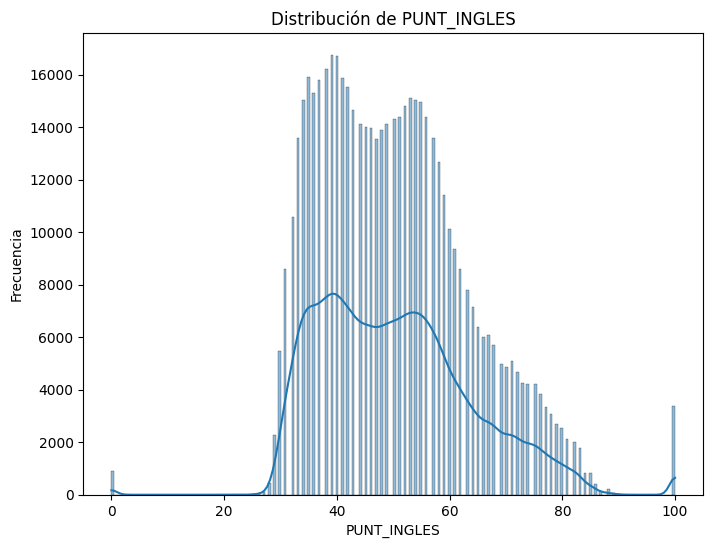

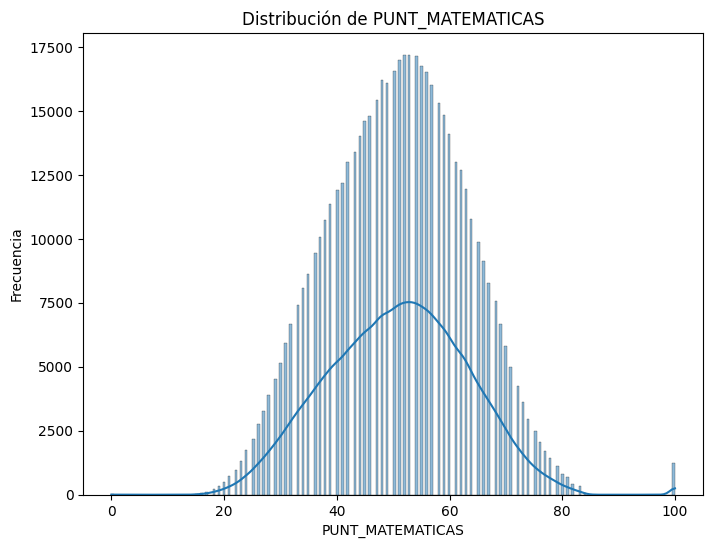

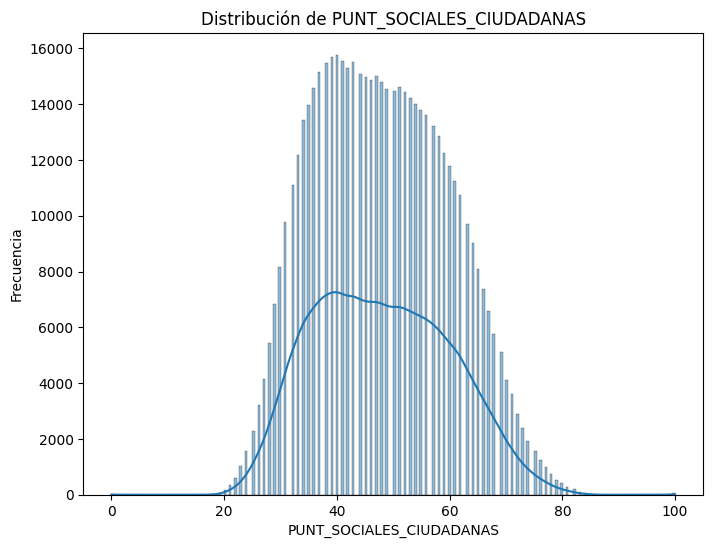

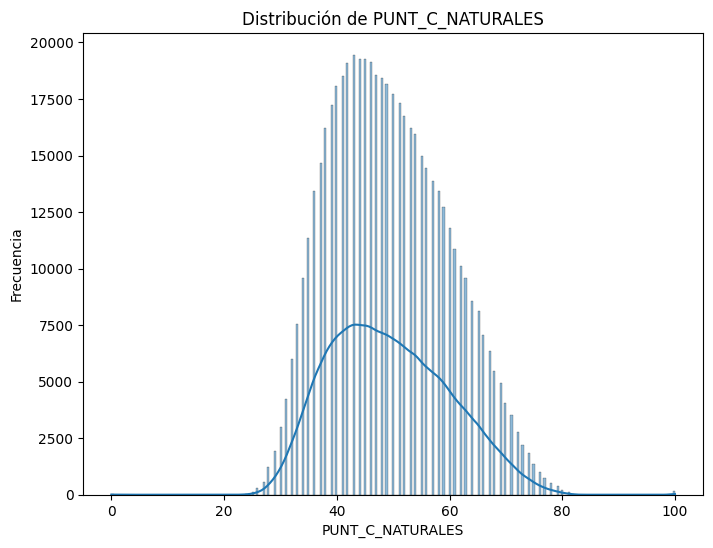

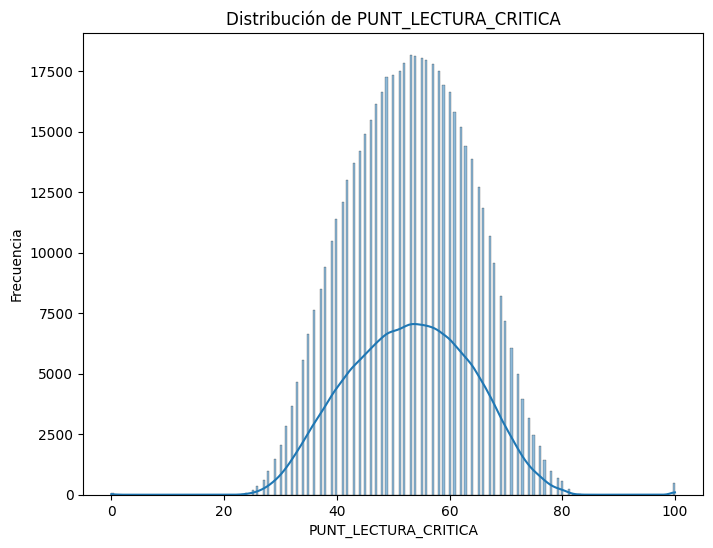

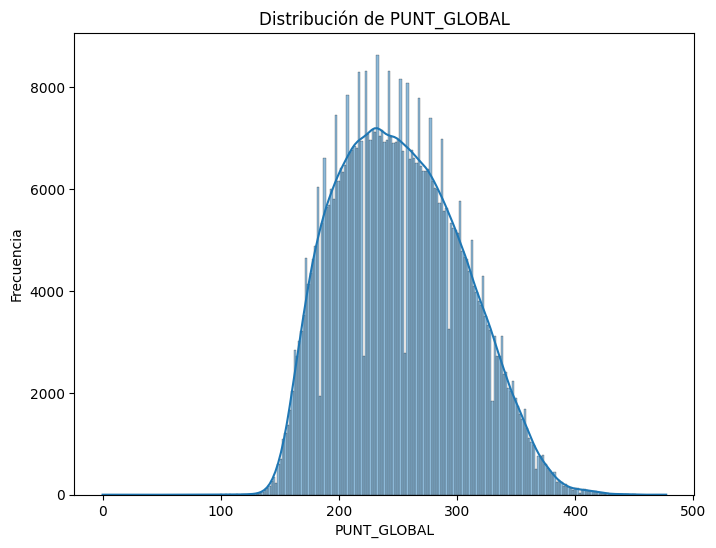

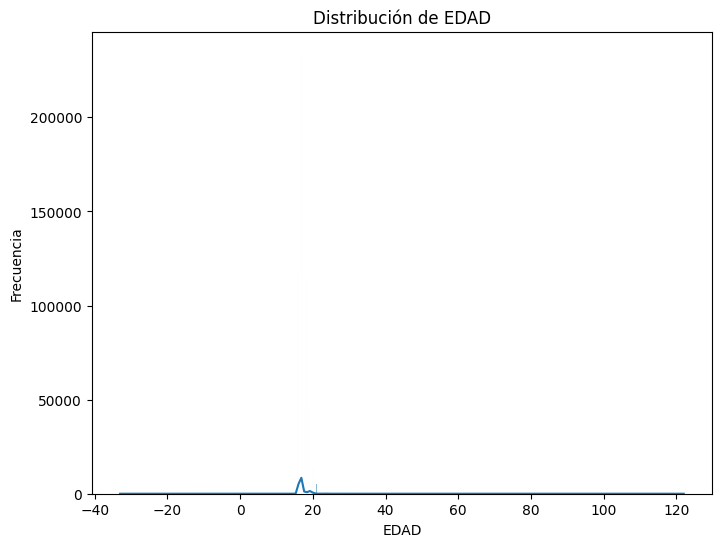

In [ ]:
numerical_cols = df00.select_dtypes(include=np.number).columns

for col in numerical_cols:
    plt.figure(figsize=(8, 6))
    sns.histplot(df00[col], kde=True)
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.show()

- Distribución de puntajes (Inglés, Matemáticas, Sociales, Naturales, Lectura Crítica y Global):

  La mayoría de las distribuciones de puntajes presentan una forma aproximadamente acampanada, lo que sugiere una distribución normal de los resultados, con la mayor parte de los estudiantes concentrados alrededor del promedio. En algunas asignaturas se observa una ligera asimetría (sesgo), lo que indica la presencia de colas hacia valores más altos o más bajos.

- Distribución de la edad:

  El histograma de edades muestra un pico pronunciado alrededor de los 17-18 años, que corresponde a la edad esperada de los estudiantes que presentan el examen Saber 11. También se identifican picos menores o colas que representan estudiantes más jóvenes o mayores, posiblemente aquellos que adelantan o repiten cursos, o que presentan el examen en etapas distintas de su escolaridad. Los valores atípicos (edades muy bajas o muy altas) observados en las estadísticas descriptivas también se evidencian en el gráfico.

###Boxplot para variables numericas

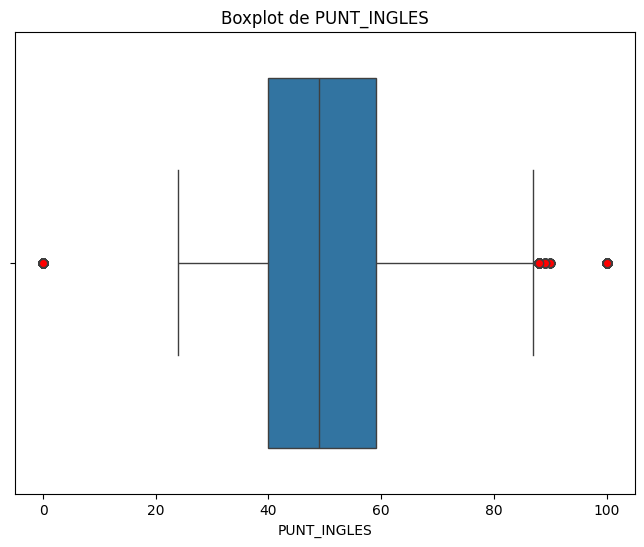

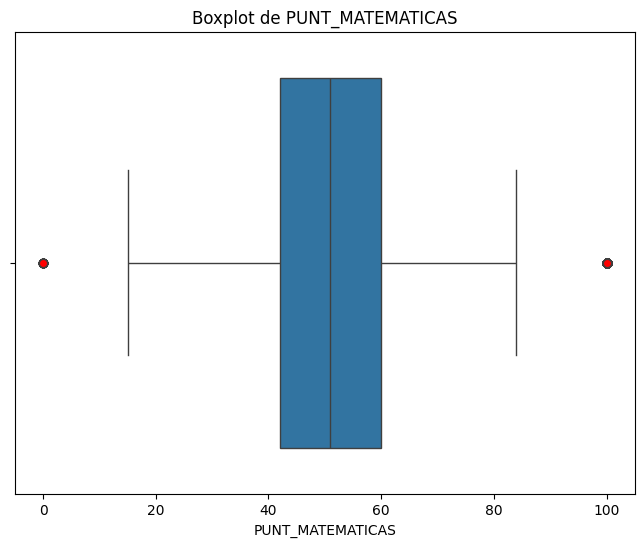

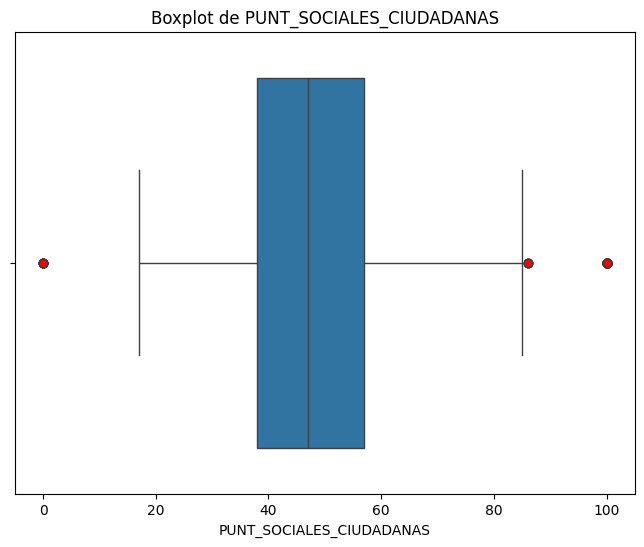

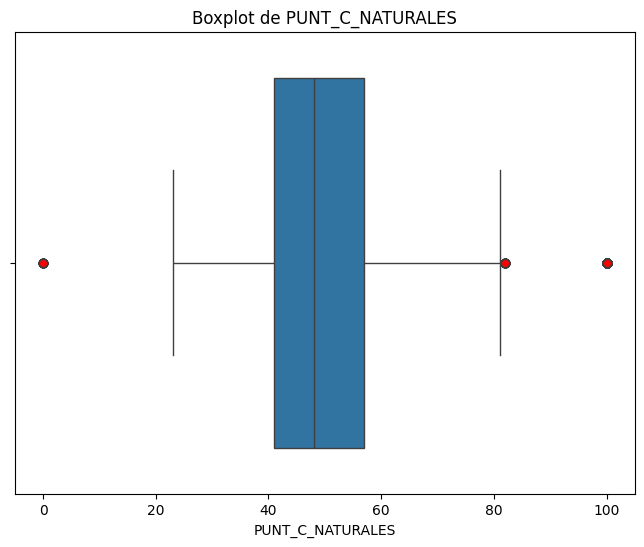

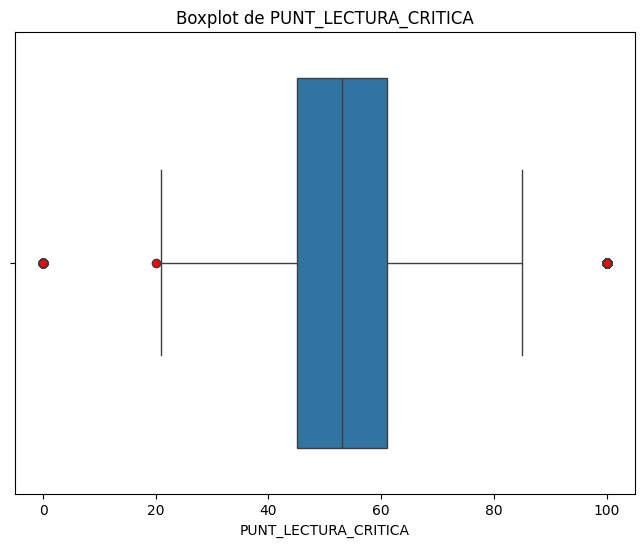

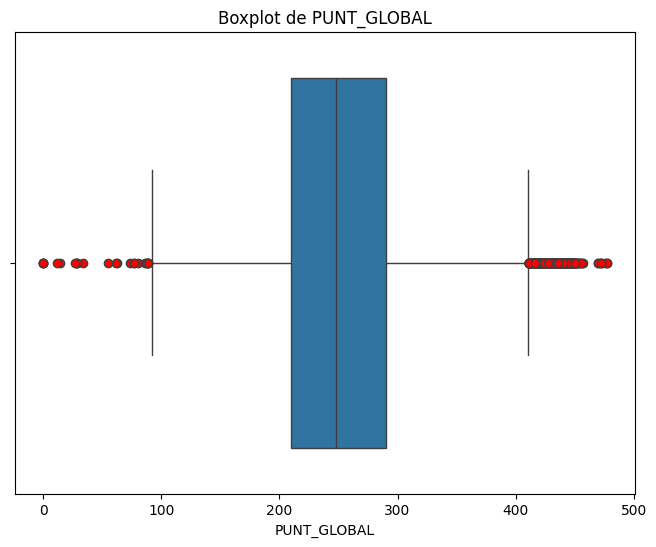

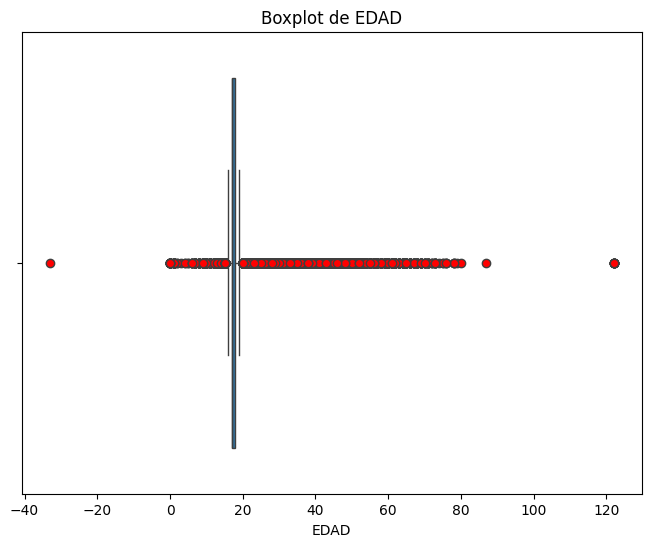

Lista ordenada de valores atípicos (basada en IQR) para cada variable numérica:

PUNT_INGLES:
[0, 88, 89, 90, 100]

PUNT_MATEMATICAS:
[0, 100]

PUNT_SOCIALES_CIUDADANAS:
[0, 86, 100]

PUNT_C_NATURALES:
[0, 82, 100]

PUNT_LECTURA_CRITICA:
[0, 20, 100]

PUNT_GLOBAL:
[0, 12, 14, 27, 28, 29, 34, 55, 62, 63, 74, 77, 80, 86, 87, 88, 89, 411, 412, 413, 414, 415, 416, 417, 418, 419, 420, 421, 422, 423, 424, 425, 426, 427, 428, 429, 430, 431, 432, 433, 434, 435, 436, 437, 438, 439, 440, 441, 442, 443, 444, 445, 446, 447, 448, 449, 450, 451, 452, 453, 454, 455, 456, 457, 470, 472, 476, 477]

EDAD:
[-33, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 78, 79, 80, 87, 122]


In [ ]:
# Seleccionar columnas numéricas
numerical_cols = df00.select_dtypes(include=np.number).columns

# Diccionario para almacenar los valores atípicos ordenados
outliers_dict = {}

# Iterar sobre cada columna numérica
for col in numerical_cols:
    # Calcular cuartiles y Rango Intercuartílico (IQR)
    Q1 = df00[col].quantile(0.25)
    Q3 = df00[col].quantile(0.75)
    IQR = Q3 - Q1

    # Identificar valores atípicos (outliers) usando el método del IQR
    outliers = df00[(df00[col] < (Q1 - 1.5 * IQR)) | (df00[col] > (Q3 + 1.5 * IQR))][col]

    # Si se encontraron valores atípicos, almacenarlos
    if not outliers.empty:
        # Obtener valores atípicos únicos y ordenados, y guardarlos en el diccionario
        outliers_dict[col] = np.sort(outliers.unique()).tolist()

    # Generar boxplot para la columna actual
    plt.figure(figsize=(8, 6))
    # Marcar los valores atípicos en rojo
    sns.boxplot(x=df00[col], flierprops=dict(markerfacecolor='red', marker='o'))
    plt.title(f'Boxplot de {col}') # Título del boxplot
    plt.xlabel(col) # Etiqueta del eje x
    plt.show() # Mostrar el boxplot


# Mostrar la lista ordenada de valores atípicos para cada columna
if outliers_dict:
    print("Lista ordenada de valores atípicos (basada en IQR) para cada variable numérica:")
    for col, outlier_list in outliers_dict.items():
        print(f"\n{col}:")
        print(outlier_list)
else:
    print("No se encontraron valores atípicos basados en IQR para ninguna variable numérica.")

En la mayoria de los registros se observa que si bien hay atipicos, son valores posibles y tienen sentido, a excepcion de la edad, donde hay registro imposibles, tales como una edad de -33 como una edad de 122.
###Tratamiento outliers edad
Primero se revisa cuantos registros presentan esta anomalia

In [ ]:
extreme_age_records = df00[(df00['EDAD'] == -33) | (df00['EDAD'] == 122)]

extreme_age_count = len(extreme_age_records)

total_records = len(df00)
extreme_age_percentage = (extreme_age_count / total_records) * 100

print(f"Cantidad de registros con EDAD -33 o 122: {extreme_age_count}")
print(f"Porcentae con EDAD -33 o 22: {extreme_age_percentage:.2f}%")

# Display the filtered records
print("\nRegistros con EDAD -33 o 122:")
display(extreme_age_records)

Cantidad de registros con EDAD -33 o 122: 10
Porcentae con EDAD -33 o 22: 0.00%

Registros con EDAD -33 o 122:


,PERIODO,COLE_AREA_UBICACION,COLE_BILINGUE,COLE_CARACTER,COLE_JORNADA,COLE_NATURALEZA,ESTU_COD_RESIDE_DEPTO,ESTU_COD_RESIDE_MCPIO,ESTU_GENERO,FAMI_EDUCACIONMADRE,FAMI_EDUCACIONPADRE,FAMI_ESTRATOVIVIENDA,FAMI_PERSONASHOGAR,FAMI_TIENECOMPUTADOR,FAMI_TIENEINTERNET,FAMI_TIENELAVADORA,DESEMP_INGLES,PUNT_INGLES,PUNT_MATEMATICAS,PUNT_SOCIALES_CIUDADANAS,PUNT_C_NATURALES,PUNT_LECTURA_CRITICA,PUNT_GLOBAL,EDAD
195161,20224,URBANO,False,ACADÉMICO,MAÑANA,NO OFICIAL,11,11001,F,Secundaria (Bachillerato) completa,Secundaria (Bachillerato) completa,Estrato 3,3 a 4,True,True,True,A1,49,49,47,56,53,255,122
205713,20224,RURAL,False,TÉCNICO,UNICA,OFICIAL,47,47980,M,Primaria completa,Secundaria (Bachillerato) completa,Estrato 1,1 a 2,False,False,True,A-,31,38,30,44,43,191,122
230064,20224,URBANO,False,ACADÉMICO,NOCHE,NO OFICIAL,8,8001,M,Primaria incompleta,Primaria incompleta,Estrato 1,3 a 4,True,True,True,A-,29,34,38,32,47,185,122
232251,20224,URBANO,False,ACADÉMICO,COMPLETA,NO OFICIAL,11,11001,F,Educación profesional completa,Educación profesional completa,Estrato 4,5 a 6,True,True,True,A2,65,61,48,59,58,286,-33
249292,20224,RURAL,False,ACADÉMICO,NOCHE,OFICIAL,52,52835,F,Educación profesional completa,Primaria completa,Estrato 3,5 a 6,False,True,True,A-,32,27,34,28,24,143,122
346355,20224,URBANO,False,TÉCNICO/ACADÉMICO,MAÑANA,OFICIAL,66,66170,F,Ninguno,Técnica o tecnológica completa,Estrato 3,5 a 6,True,True,True,A-,38,46,36,47,49,220,122
354273,20224,URBANO,False,NO ESPECIFICADO,NOCHE,NO OFICIAL,8,8758,M,No sabe,No sabe,Estrato 2,3 a 4,True,True,True,A-,39,39,34,45,44,202,122
388063,20224,URBANO,False,NO ESPECIFICADO,MAÑANA,NO OFICIAL,8,8758,M,Primaria completa,Primaria incompleta,Estrato 2,5 a 6,True,False,False,A-,32,40,45,34,43,199,122
506852,20224,URBANO,False,ACADÉMICO,MAÑANA,NO OFICIAL,8,8001,F,Educación profesional completa,Educación profesional completa,Estrato 2,5 a 6,True,True,True,A-,36,29,37,39,33,173,122
547680,20224,URBANO,False,ACADÉMICO,NOCHE,NO OFICIAL,47,47189,F,Secundaria (Bachillerato) incompleta,Técnica o tecnológica completa,Estrato 1,1 a 2,False,False,True,A1,48,46,49,47,46,235,122


Es dificil deducir estos valores, adicionalmente no son un porcentaje significativo en el dataframe, por lo que se opta a eliminar estos registros.

In [ ]:
df00 = df00[(df00['EDAD'] != -33) & (df00['EDAD'] != 122)]

display(df00.shape)

(550750, 24)

###Matriz de correlación entre variables numericas

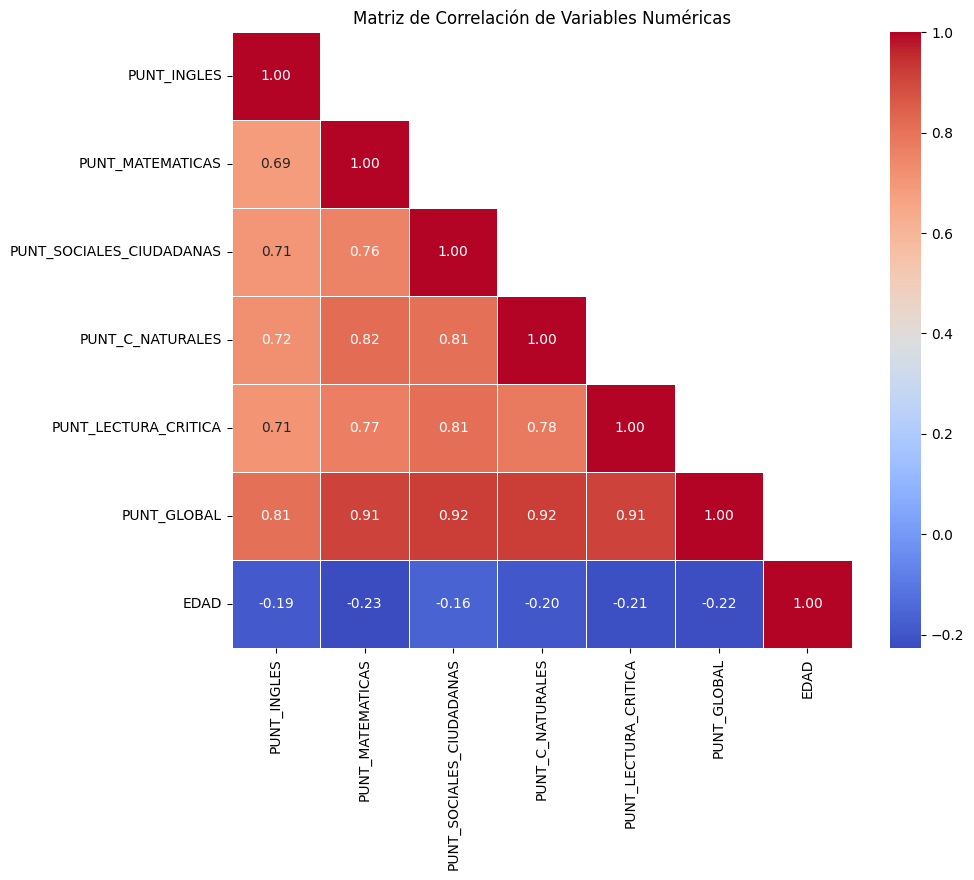

In [ ]:
# Seleccionar solo columnas numéricas
numerical_df = df00.select_dtypes(include=np.number)

# Calcular la matriz de correlación
correlation_matrix = numerical_df.corr()

# Crear una máscara para la parte superior del triángulo, excluyendo la diagonal
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool), k=1) # k=1 excludes the diagonal


# Visualizar la matriz de correlación usando un heatmap con la máscara
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

- Todos los puntajes por materia tienen una correlacion positiva fuerte con el puntaje global.
- Hay una correlacion positiva fuerte (0.82) entre el puntaje de ciencias naturales y puntaje de matematicas
- Hay una correlación positiva fuerte (0.81) entre el puntaje de ciencias naturales y el puntaje de competencias sociales ciudadanas
- Hay una correlación positiva fuerte (0.78) entre el puntaje de ciencias naturales y lectura critica.
- Hay una correlación negativa debil entre la edad y todos los puntajes (tanto individuales como el global)

###Significancia de las correlaciones

In [ ]:
from scipy.stats import pearsonr

# Se hace la selección de solo valores númericos
numerical_df = df00.select_dtypes(include=np.number)

# Se calcula la correlación
correlation_matrix = numerical_df.corr(method='pearson')
p_values_matrix = numerical_df.corr(method=lambda x, y: pearsonr(x, y)[1])

# Muestra la correlación
print("Matriz de Correlación de Variables Numéricas:")
display(correlation_matrix.round(2))

# Muestra los p-valores de la matriz
print("\nMatriz de P-valores (Significancia de la Correlación):")
display(p_values_matrix.round(3))

# Interpreta los p-valores
print("\nInterpretación de la Significancia:")
print("- Un p-valor bajo (típicamente < 0.05) indica que la correlación es estadísticamente significativa y es poco probable que se deba al azar.")
print("- Un p-valor alto (>= 0.05) indica que la correlación no es estadísticamente significativa y podría deberse al azar.")

Matriz de Correlación de Variables Numéricas:


,PUNT_INGLES,PUNT_MATEMATICAS,PUNT_SOCIALES_CIUDADANAS,PUNT_C_NATURALES,PUNT_LECTURA_CRITICA,PUNT_GLOBAL,EDAD
PUNT_INGLES,1.00,0.69,0.71,0.72,0.71,0.81,-0.19
PUNT_MATEMATICAS,0.69,1.00,0.76,0.82,0.77,0.91,-0.23
PUNT_SOCIALES_CIUDADANAS,0.71,0.76,1.00,0.81,0.81,0.92,-0.16
PUNT_C_NATURALES,0.72,0.82,0.81,1.00,0.78,0.92,-0.20
PUNT_LECTURA_CRITICA,0.71,0.77,0.81,0.78,1.00,0.91,-0.21
PUNT_GLOBAL,0.81,0.91,0.92,0.92,0.91,1.00,-0.22
EDAD,-0.19,-0.23,-0.16,-0.20,-0.21,-0.22,1.00



Matriz de P-valores (Significancia de la Correlación):


,PUNT_INGLES,PUNT_MATEMATICAS,PUNT_SOCIALES_CIUDADANAS,PUNT_C_NATURALES,PUNT_LECTURA_CRITICA,PUNT_GLOBAL,EDAD
PUNT_INGLES,1.0,0.0,0.0,0.0,0.0,0.0,0.0
PUNT_MATEMATICAS,0.0,1.0,0.0,0.0,0.0,0.0,0.0
PUNT_SOCIALES_CIUDADANAS,0.0,0.0,1.0,0.0,0.0,0.0,0.0
PUNT_C_NATURALES,0.0,0.0,0.0,1.0,0.0,0.0,0.0
PUNT_LECTURA_CRITICA,0.0,0.0,0.0,0.0,1.0,0.0,0.0
PUNT_GLOBAL,0.0,0.0,0.0,0.0,0.0,1.0,0.0
EDAD,0.0,0.0,0.0,0.0,0.0,0.0,1.0



Interpretación de la Significancia:
- Un p-valor bajo (típicamente < 0.05) indica que la correlación es estadísticamente significativa y es poco probable que se deba al azar.
- Un p-valor alto (>= 0.05) indica que la correlación no es estadísticamente significativa y podría deberse al azar.


##Analisis para variables categoricas
###Estadisticos descriptivos para variables categoricas



In [ ]:
df00.describe(include='category')

,PERIODO,COLE_AREA_UBICACION,COLE_CARACTER,COLE_JORNADA,COLE_NATURALEZA,ESTU_COD_RESIDE_DEPTO,ESTU_COD_RESIDE_MCPIO,ESTU_GENERO,FAMI_EDUCACIONMADRE,FAMI_EDUCACIONPADRE,FAMI_ESTRATOVIVIENDA,FAMI_PERSONASHOGAR,DESEMP_INGLES
count,550750,550750,550750,550750,550750,550750,550750,550750,550750,550750,550750,550750,550750
unique,2,2,5,6,2,34,1117,2,12,12,7,5,5
top,20224,URBANO,ACADÉMICO,MAÑANA,OFICIAL,11,11001,F,Secundaria (Bachillerato) completa,Secundaria (Bachillerato) completa,Estrato 2,3 a 4,A-
freq,530805,458679,283216,212426,410862,81734,81734,298194,146473,128820,199215,295285,255383


- PERIODO: Se identifican dos periodos distintos en el conjunto de datos. El más frecuente es el 20224, con 530.815 registros.

- COLE_AREA_UBICACION: La mayoría de estudiantes proviene de colegios ubicados en zona urbana (458.687).

- COLE_CARACTER: Hay 5 tipos de carácter de colegio. El predominante es “Académico” con 283.222 registros.

- COLE_JORNADA: Se identifican 6 tipos de jornada; la más común es “Mañana” con 212.430 registros.

- COLE_NATURALEZA: Solo hay dos tipos: Oficial y No oficial. Predomina “Oficial” con 410.865 estudiantes.

- ESTU_COD_RESIDE_DEPTO y ESTU_COD_RESIDE_MCPIO: Hay 34 departamentos y 1.117 municipios de residencia; el municipio más frecuente es 11001 (Bogotá).

- ESTU_GENERO: Solo hay dos categorías. Predomina el género femenino con 298.200 registros.

- FAMI_EDUCACIONMADRE / PADRE: Hay 12 categorías distintas para el nivel educativo de padres y madres. La más frecuente es “Secundaria (Bachillerato) completa” (146.474 madres y 128.822 padres).

- FAMI_ESTRATOVIVIENDA: Siete estratos distintos; el más frecuente es el estrato 2 (199.218).

- FAMI_PERSONASHOGAR: Cinco categorías de tamaño de hogar; la más común es “3 a 4 personas” (295.288).

- DESEMP_INGLES: Cinco categorías de desempeño en inglés; la más frecuente es A- (255.390).



###Histogramas para variables categoricas

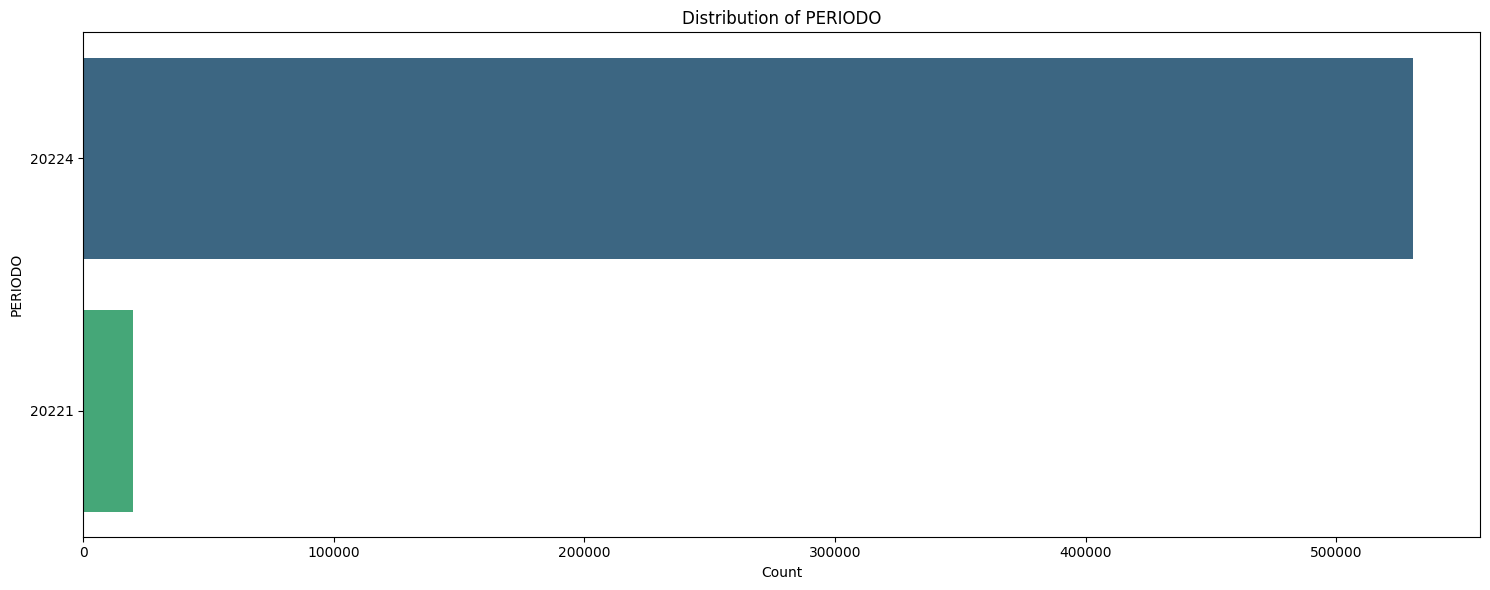

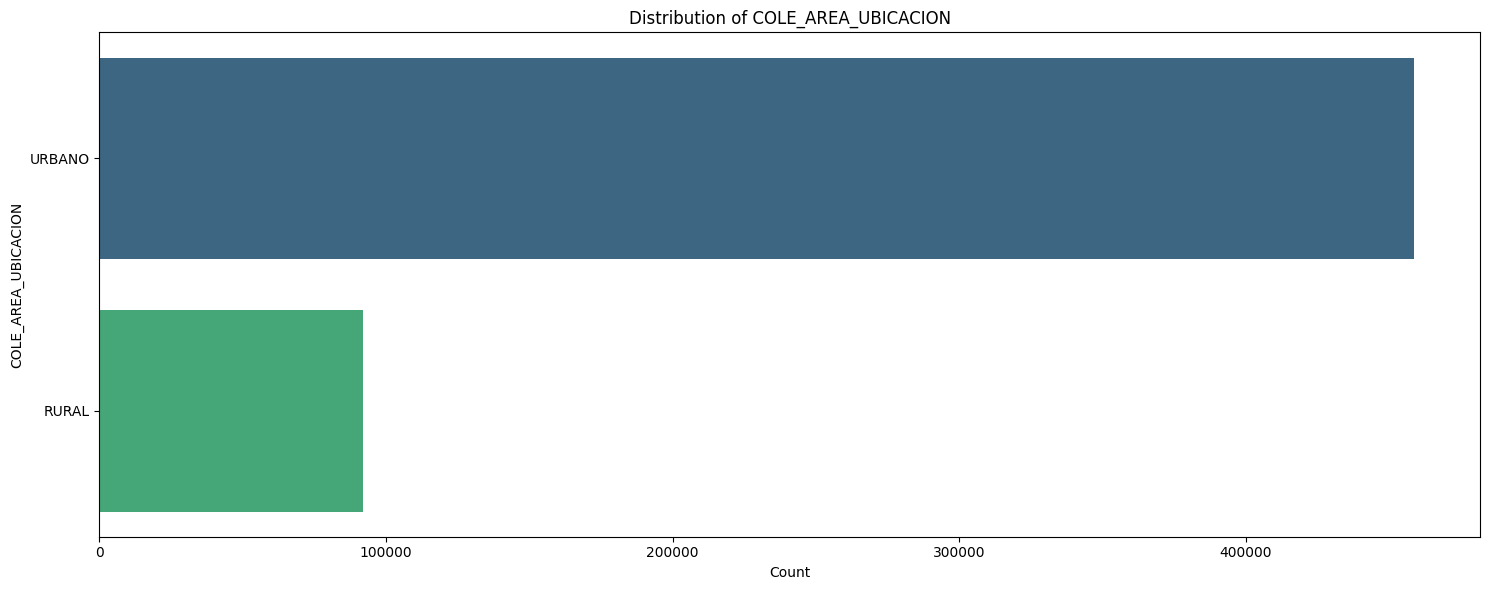

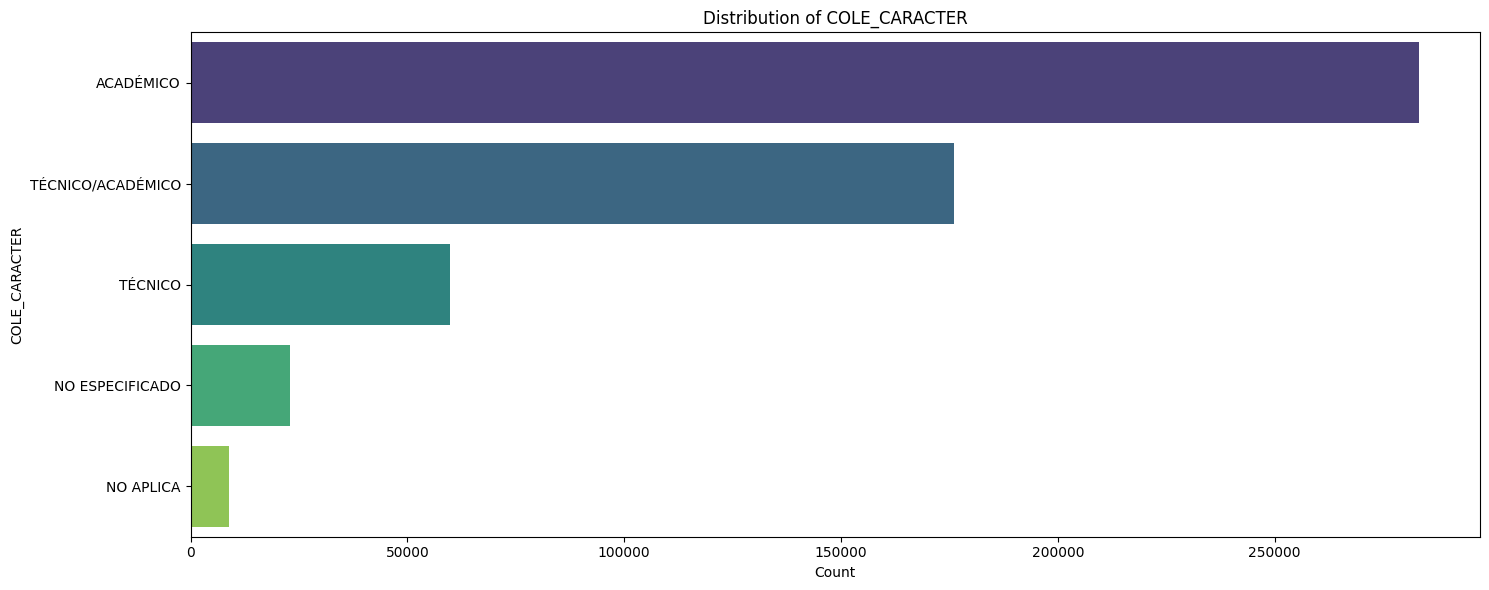

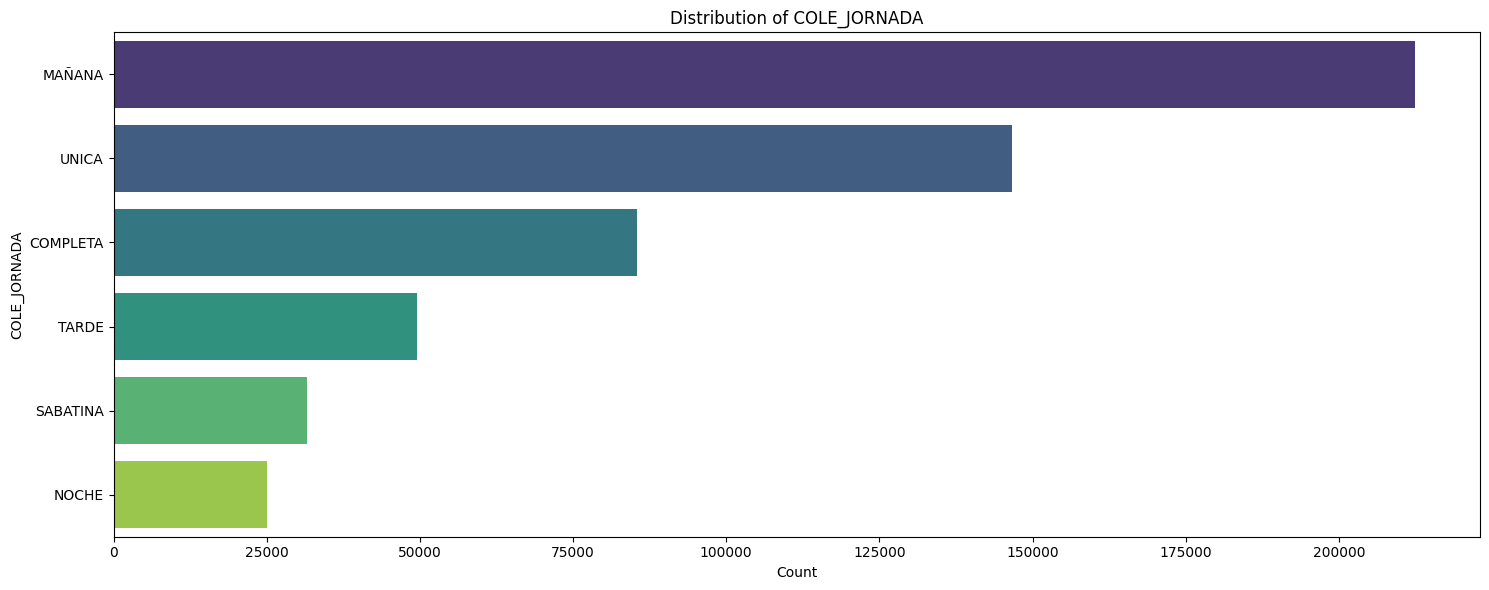

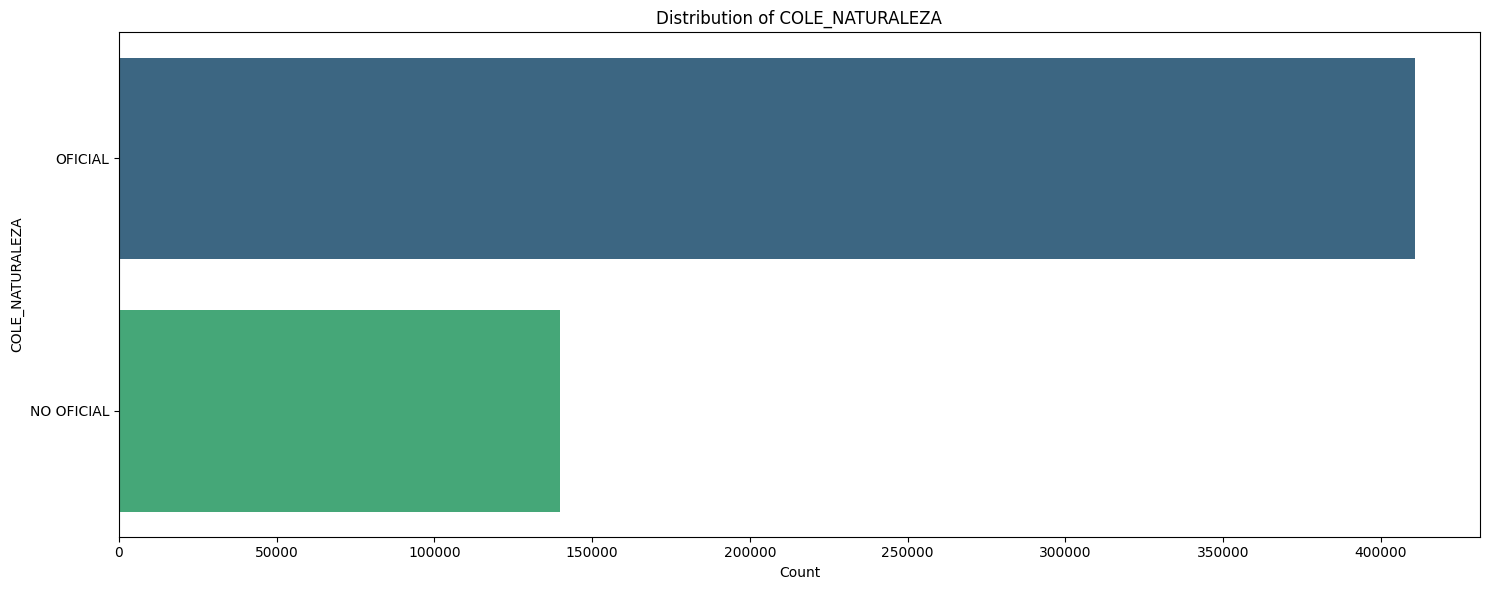

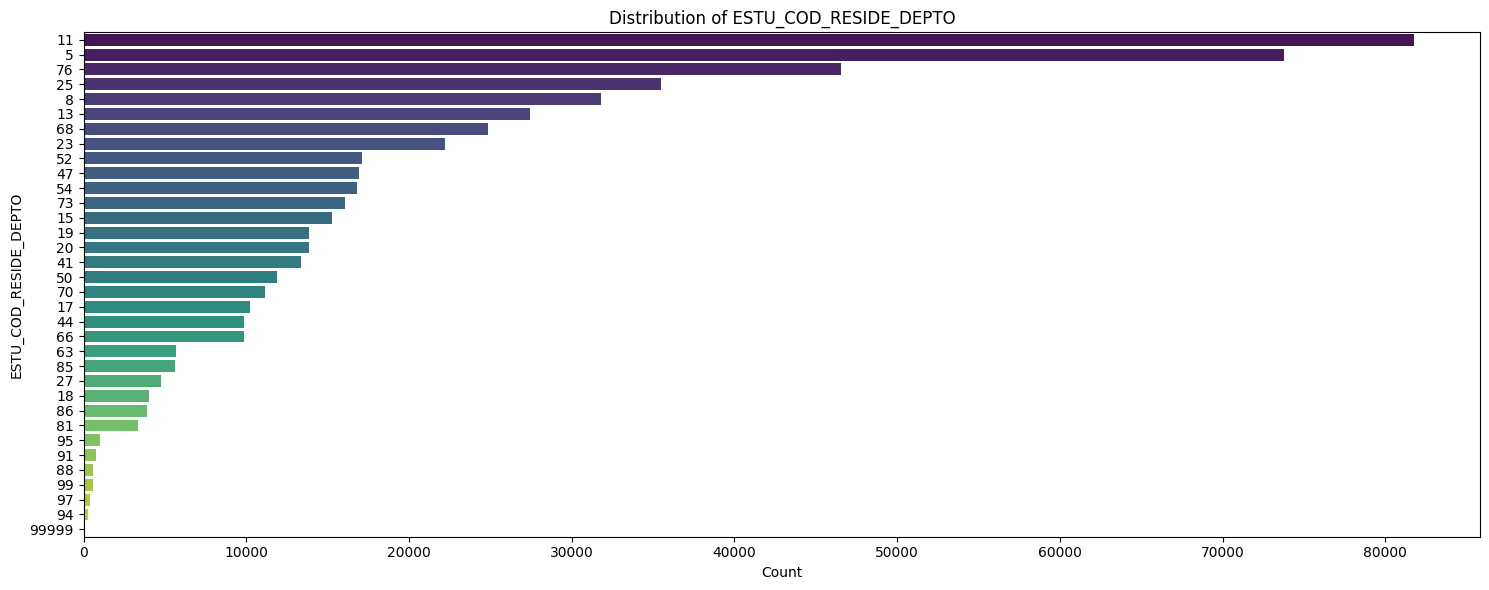

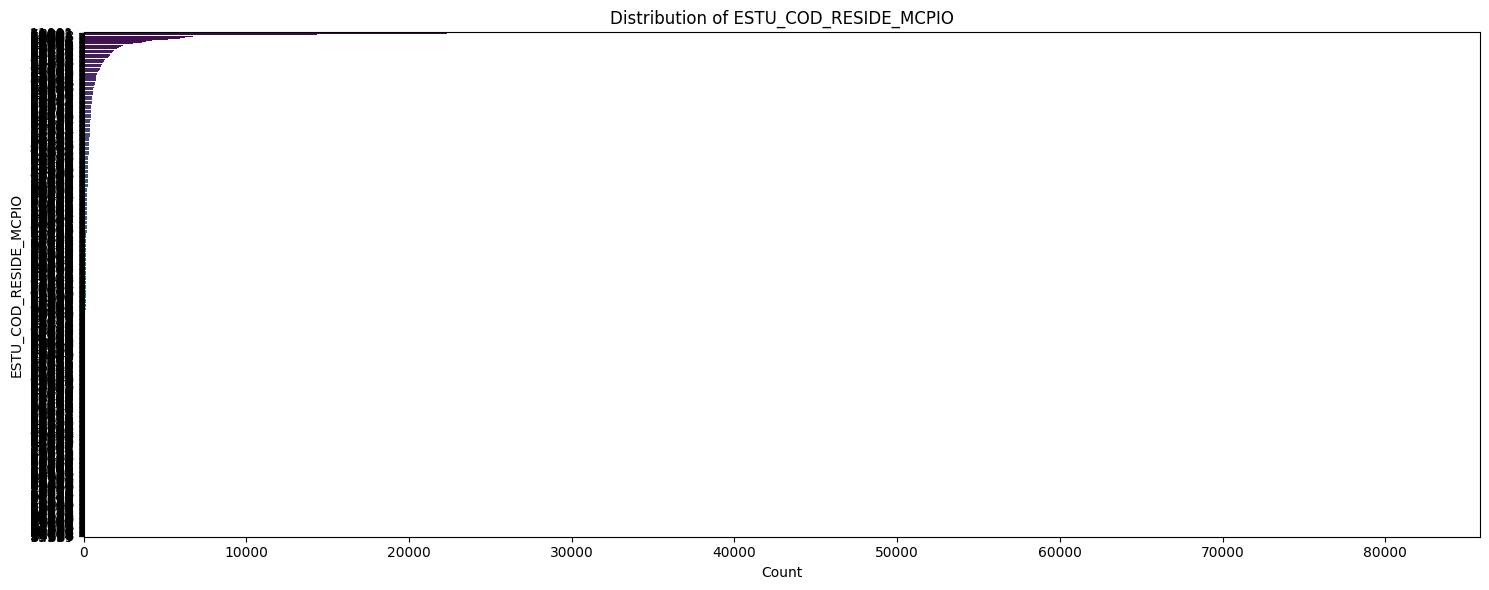

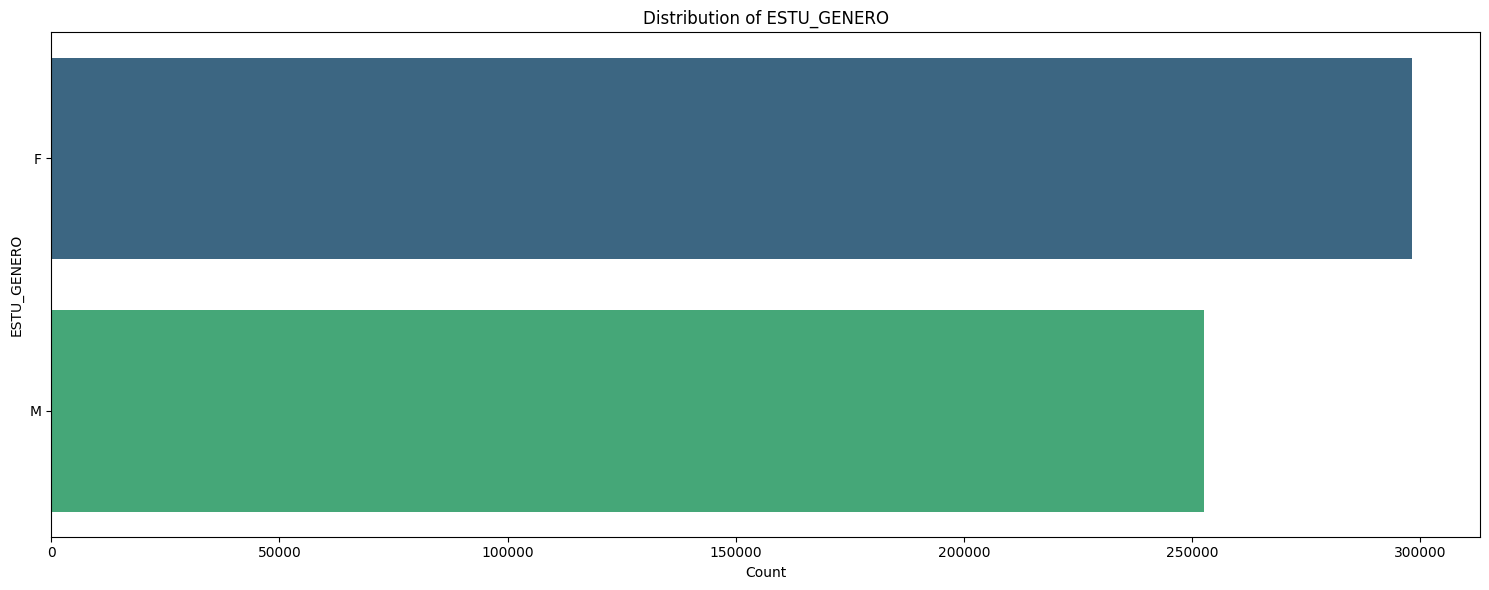

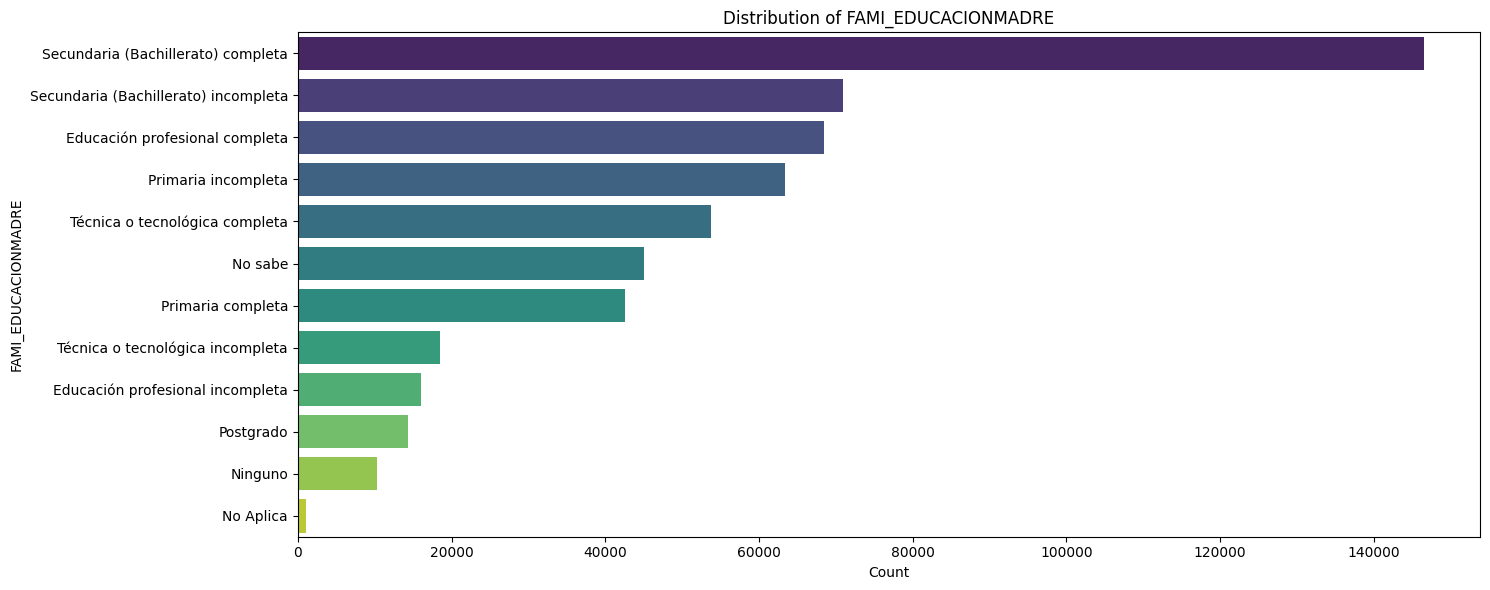

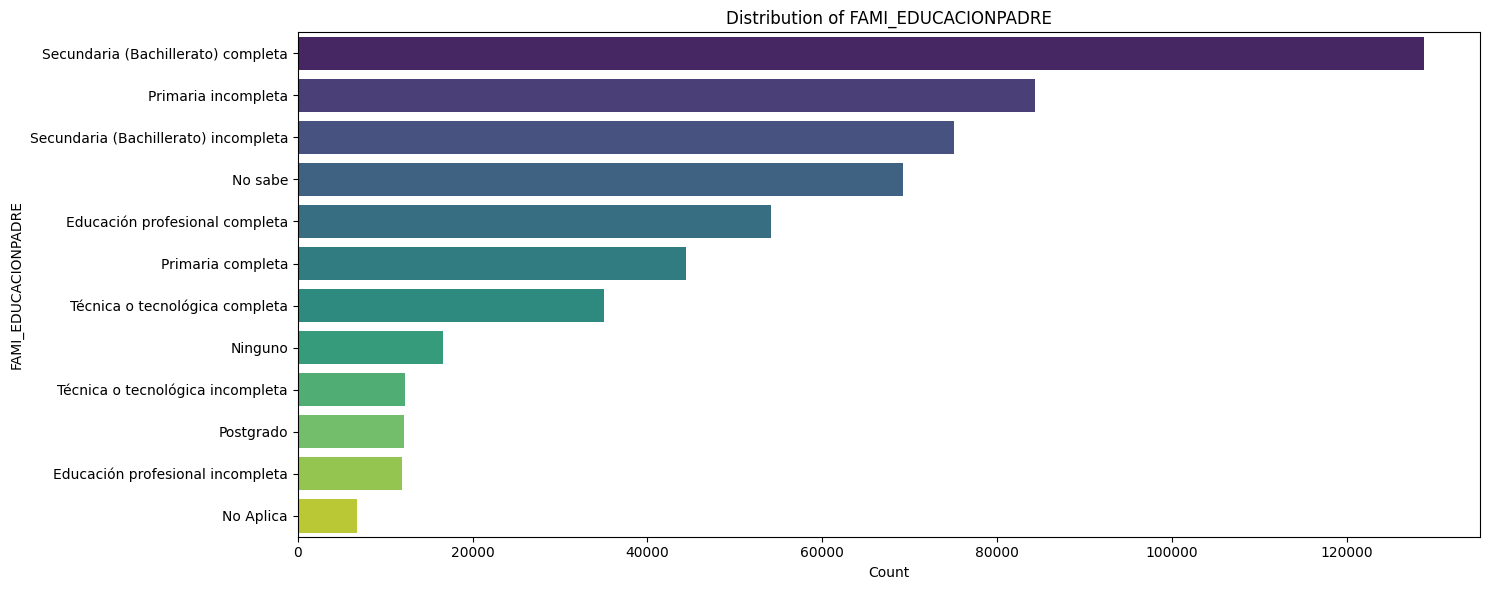

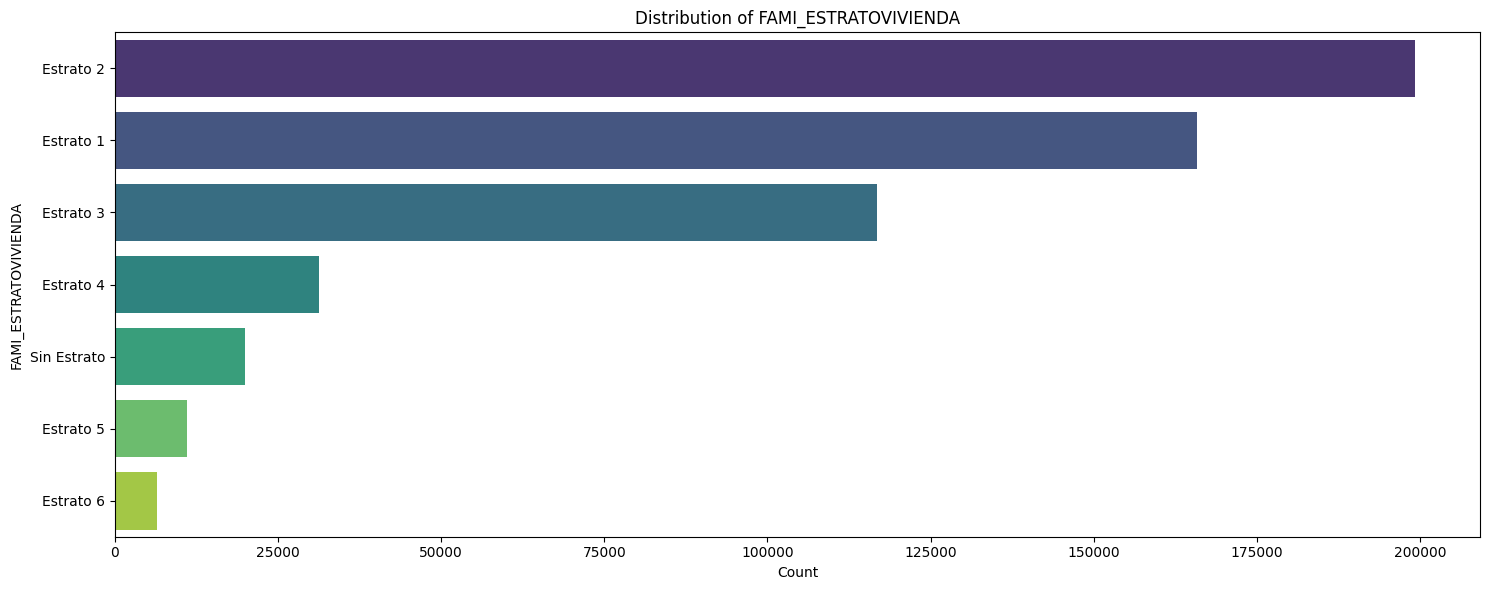

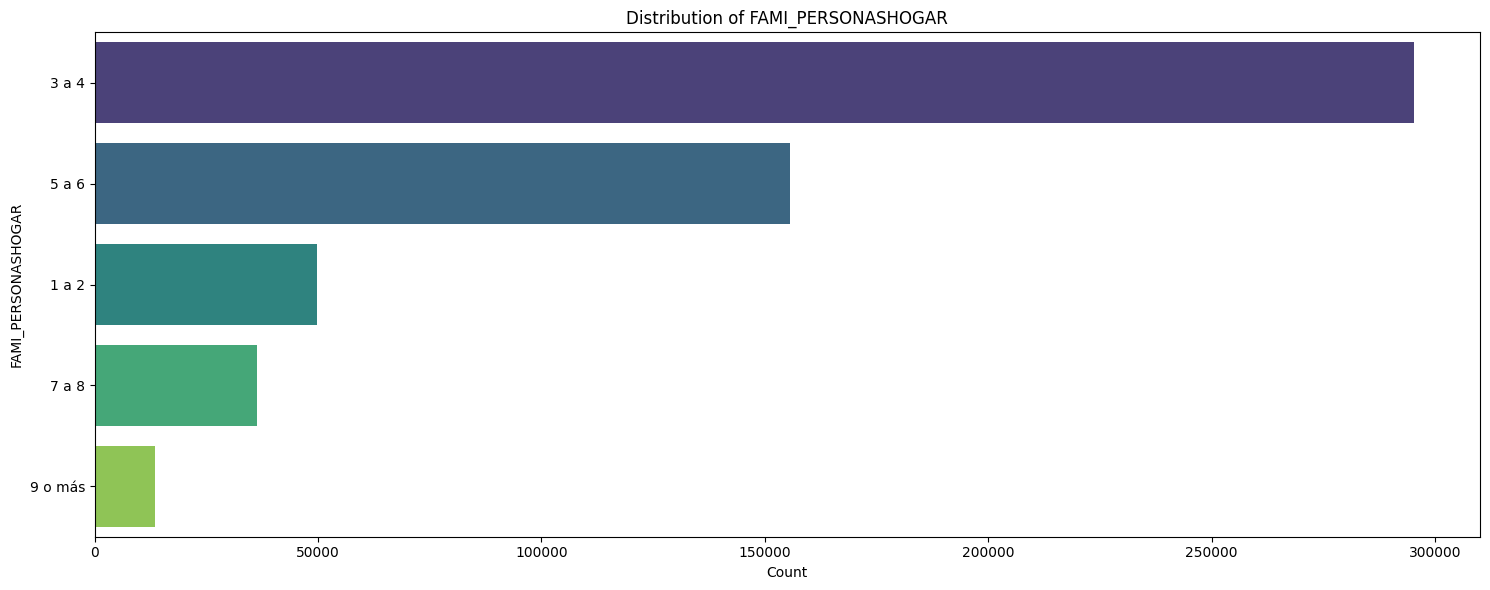

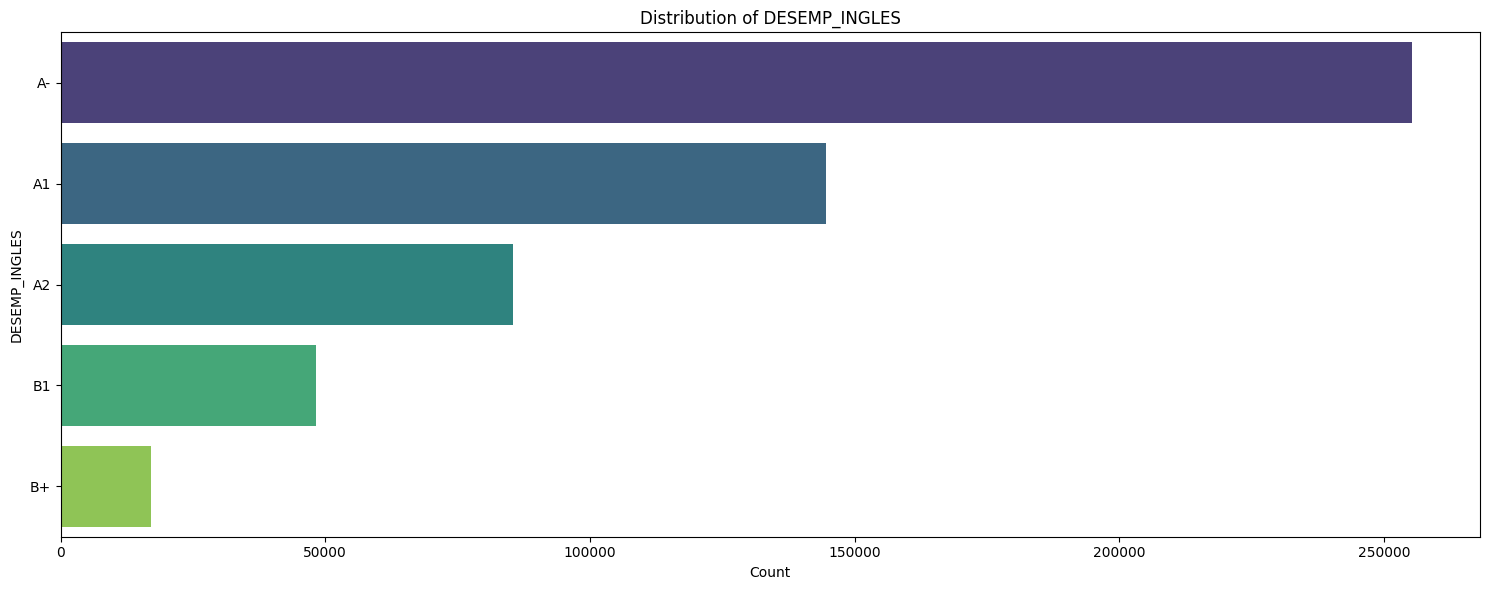

In [ ]:
categorical_cols = df00.select_dtypes(include='category').columns

for col in categorical_cols:
    plt.figure(figsize=(15, 6))
    ax = sns.countplot(data=df00, y=col, order=df00[col].value_counts().index, palette='viridis')
    plt.title(f'Distribution of {col}')
    plt.xlabel('Count')
    plt.ylabel(col)

    plt.tight_layout()
    plt.show()

- PERIODO: La mayoría de los estudiantes presentó el examen en el periodo 20224.

- COLE_AREA_UBICACION: La mayor parte de los colegios se encuentra en zonas urbanas.

- COLE_CARACTER: La mayoría de los colegios a los que asisten los estudiantes son de carácter académico.

- COLE_JORNADA: La jornada predominante es la mañana, mientras que la menor proporción de estudiantes asiste a jornada nocturna.

- COLE_NATURALEZA: La mayoría de los estudiantes está matriculada en colegios oficiales.

- ESTU_COD_RESIDE_DEPTO: La mayor concentración de estudiantes se encuentra en el departamento 11, correspondiente a Bogotá D.C.

- ESTU_COD_RESIDE_MCPIO: En este gráfico la información no se visualiza con claridad, pero anteriormente se pudo ver que el municipio mas común es 11001 (Bogotá).

- ESTU_GENERO: La mayoría de los estudiantes son de género femenino.

- FAMI_EDUCACIONMADRE: La mayoría de las madres de los estudiantes alcanzó como máximo la educación secundaria (bachillerato) completa.

- FAMI_EDUCACIONPADRE: La mayoría de los padres de los estudiantes alcanzó como máximo la educación secundaria (bachillerato) completa.

- FAMI_ESTRATOVIVIENDA: La mayoría de los estudiantes pertenece a estratos 1 y 2, mientras que solo una minoría se ubica en estratos 5 y 6.

- FAMI_PERSONASHOGAR: La mayoría de los estudiantes vive con un rango de 3 a 4 personas adicionales, mientras que una minoría vive con 9 personas o más.

- DESEMP_INGLES: La mayoría de los estudiantes tiene un desempeño en inglés de nivel A-


###Proporción de los datos para cada categoria

In [ ]:
categorical_cols = df00.select_dtypes(include='category').columns

for col in categorical_cols:
    print(f"\n--- Proporción de Categorías para '{col}' ---")

    # Calculate relative frequency
    relative_frequencies = df00[col].value_counts(normalize=True).rename("Proportion")

    # Convert to DataFrame and format as percentage
    relative_frequencies_df = relative_frequencies.to_frame()
    relative_frequencies_df['Proportion'] = relative_frequencies_df['Proportion'].map('{:.2%}'.format)

    # Display the relative frequencies table for the current column
    display(relative_frequencies_df)

    print("-" * (len(f"--- Proporción de Categorías para '{col}' ---")))


--- Proporción de Categorías para 'PERIODO' ---


,Proportion
PERIODO,
20224,96.38%
20221,3.62%


-----------------------------------------------

--- Proporción de Categorías para 'COLE_AREA_UBICACION' ---


,Proportion
COLE_AREA_UBICACION,
URBANO,83.28%
RURAL,16.72%


-----------------------------------------------------------

--- Proporción de Categorías para 'COLE_CARACTER' ---


...

------------------------------------------------------------

--- Proporción de Categorías para 'FAMI_PERSONASHOGAR' ---


,Proportion
FAMI_PERSONASHOGAR,
3 a 4,53.62%
5 a 6,28.27%
1 a 2,9.04%
7 a 8,6.61%
9 o más,2.47%


----------------------------------------------------------

--- Proporción de Categorías para 'DESEMP_INGLES' ---


,Proportion
DESEMP_INGLES,
A-,46.37%
A1,26.24%
A2,15.53%
B1,8.76%
B+,3.09%


-----------------------------------------------------


- PERIODO

  96.38% de los registros son del periodo 20224 y solo 3.62% de 20221.

  Esto significa que la base está concentrada casi totalmente en un solo periodo → puede sesgar análisis.


- COLE_AREA_UBICACION

  83.28% urbano vs. 16.72% rural.

  Hay un sesgo urbano fuerte; resultados o modelos estarán más representados por estudiantes urbanos.

- COLE_CARACTER

  Principalmente académico (51%) y técnico/ académico (32%).

  “No especificado” (4.15%) y “No aplica” (1.60%) son categorías raras → pueden ser tratadas como “Otros”.

- COLE_JORNADA

  Distribución bastante variada.

  La jornada “SABATINA” y “NOCHE” suman solo ~10%: son grupos minoritarios.

- COLE_NATURALEZA

  Mayoría oficial (75%) vs. no oficial (25%).

  Representativo del sistema educativo colombiano, la base esta sesgada a colegios oficiales.

- ESTU_COD_RESIDE_DEPTO y ESTU_COD_RESIDE_MCPIO

  Aparece un código 99999 con 0.00%.

- ESTU_GENERO

  54% F vs. 46% M.

  Distribución balanceada, sin problemas.

- FAMI_EDUCACIONMADRE y FAMI_EDUCACIONPADRE

  La mayoría tiene secundaria completa (madre 26%, padre 23%).

  Muchas categorías minoritarias (<3%), y valores “No sabe” y “No Aplica” significativos que podrían agruparse o marcarse como Otros.

- FAMI_ESTRATOVIVIENDA

  66% en estratos 1–2 (bajos), 21% estrato 3, resto estratos altos.

  La base está claramente sesgada a estratos bajos, típico en muestras educativas.

- FAMI_PERSONASHOGAR

  Hogares de 3 a 4 personas predominan (53%).

  “9 o más” son pocos (2.47%).

- DESEMP_INGLES

  Mayoría en niveles básicos: A- (46%) y A1 (26%).

  Muy pocos en B+ (3%) → alto desbalance de desempeño.



###Unificacion de columnas para Cole_caracter
“No especificado”  y “No aplica” son categorías raras que pueden ser tratadas como “Otros”.

In [ ]:
df00['COLE_CARACTER'] = df00['COLE_CARACTER'].replace(['NO ESPECIFICADO', 'NO APLICA'], 'OTROS')

df00['COLE_CARACTER'] = df00['COLE_CARACTER'].astype('category')

print(f"\n--- Proporción de Categorías para 'COLE_CARACTER' después de la unificación ---")

relative_frequencies = df00['COLE_CARACTER'].value_counts(normalize=True).rename("Proportion")

relative_frequencies_df = relative_frequencies.to_frame()
relative_frequencies_df['Proportion'] = relative_frequencies_df['Proportion'].map('{:.2%}'.format)

display(relative_frequencies_df)

print("-" * (len(f"--- Proporción de Categorías para 'COLE_CARACTER' después de la unificación ---")))


--- Proporción de Categorías para 'COLE_CARACTER' después de la unificación ---


,Proportion
COLE_CARACTER,
ACADÉMICO,51.42%
TÉCNICO/ACADÉMICO,31.96%
TÉCNICO,10.87%
OTROS,5.74%


-------------------------------------------------------------------------------


###Revisión del codigo 99999 en departameno y municipio


In [ ]:
records_depto_99999 = df00[df00['ESTU_COD_RESIDE_DEPTO'] == 99999]
count_depto_99999 = records_depto_99999.shape[0]
print(f"Cantidad de registros con ESTU_COD_RESIDE_DEPTO = 99999: {count_depto_99999}")
if count_depto_99999 > 0:
    print("\nRegistros con ESTU_COD_RESIDE_DEPTO = 99999:")
    display(records_depto_99999)

records_mcpio_99999 = df00[df00['ESTU_COD_RESIDE_MCPIO'] == 99999]
count_mcpio_99999 = records_mcpio_99999.shape[0]
print(f"\nCantidad de registros con ESTU_COD_RESIDE_MCPIO = 99999: {count_mcpio_99999}")
if count_mcpio_99999 > 0:
    print("\nRegistros con ESTU_COD_RESIDE_MCPIO = 99999:")
    display(records_mcpio_99999)

# Check if the records are the same
if count_depto_99999 > 0 and count_mcpio_99999 > 0:
    if records_depto_99999.equals(records_mcpio_99999):
        print("\nLos registros con 99999 en departamento y municipio son los mismos.")
    else:
        print("\nLos registros con 99999 en departamento y municipio no son los mismos.")

Cantidad de registros con ESTU_COD_RESIDE_DEPTO = 99999: 1

Registros con ESTU_COD_RESIDE_DEPTO = 99999:


,PERIODO,COLE_AREA_UBICACION,COLE_BILINGUE,COLE_CARACTER,COLE_JORNADA,COLE_NATURALEZA,ESTU_COD_RESIDE_DEPTO,ESTU_COD_RESIDE_MCPIO,ESTU_GENERO,FAMI_EDUCACIONMADRE,FAMI_EDUCACIONPADRE,FAMI_ESTRATOVIVIENDA,FAMI_PERSONASHOGAR,FAMI_TIENECOMPUTADOR,FAMI_TIENEINTERNET,FAMI_TIENELAVADORA,DESEMP_INGLES,PUNT_INGLES,PUNT_MATEMATICAS,PUNT_SOCIALES_CIUDADANAS,PUNT_C_NATURALES,PUNT_LECTURA_CRITICA,PUNT_GLOBAL,EDAD
551356,20224,URBANO,False,TÉCNICO/ACADÉMICO,UNICA,NO OFICIAL,99999,99999,M,Primaria incompleta,Primaria incompleta,Estrato 1,9 o más,False,False,False,A-,37,30,32,36,33,165,17



Cantidad de registros con ESTU_COD_RESIDE_MCPIO = 99999: 1

Registros con ESTU_COD_RESIDE_MCPIO = 99999:


,PERIODO,COLE_AREA_UBICACION,COLE_BILINGUE,COLE_CARACTER,COLE_JORNADA,COLE_NATURALEZA,ESTU_COD_RESIDE_DEPTO,ESTU_COD_RESIDE_MCPIO,ESTU_GENERO,FAMI_EDUCACIONMADRE,FAMI_EDUCACIONPADRE,FAMI_ESTRATOVIVIENDA,FAMI_PERSONASHOGAR,FAMI_TIENECOMPUTADOR,FAMI_TIENEINTERNET,FAMI_TIENELAVADORA,DESEMP_INGLES,PUNT_INGLES,PUNT_MATEMATICAS,PUNT_SOCIALES_CIUDADANAS,PUNT_C_NATURALES,PUNT_LECTURA_CRITICA,PUNT_GLOBAL,EDAD
551356,20224,URBANO,False,TÉCNICO/ACADÉMICO,UNICA,NO OFICIAL,99999,99999,M,Primaria incompleta,Primaria incompleta,Estrato 1,9 o más,False,False,False,A-,37,30,32,36,33,165,17



Los registros con 99999 en departamento y municipio son los mismos.


Al observar que es un solo dato el que contiene este dato anomalo y es muy dificil deducir el valor real, lo mejor es eliminarlo

In [ ]:
df00 = df00[df00['ESTU_COD_RESIDE_DEPTO'] != 99999]

###Unificación de columnas en educación madre y educación padre
La scategorias “No sabe” y “No Aplica” son minoritarias, por lo que podrían agruparse o marcarse como Otros

In [ ]:
df00['FAMI_EDUCACIONMADRE'] = df00['FAMI_EDUCACIONMADRE'].replace(['No sabe', 'No Aplica'], 'Otros')

df00['FAMI_EDUCACIONMADRE'] = df00['FAMI_EDUCACIONMADRE'].astype('category')

df00['FAMI_EDUCACIONPADRE'] = df00['FAMI_EDUCACIONPADRE'].replace(['No sabe', 'No Aplica'], 'Otros')

df00['FAMI_EDUCACIONPADRE'] = df00['FAMI_EDUCACIONPADRE'].astype('category')

print("Categories in 'FAMI_EDUCACIONMADRE' after replacement:")

print(f"\n--- Proporción de Categorías para 'FAMI_EDUCACIONMADRE' después de la unificación ---")

relative_frequencies_madre = df00['FAMI_EDUCACIONMADRE'].value_counts(normalize=True).rename("Proportion")

relative_frequencies_madre_df = relative_frequencies_madre.to_frame()
relative_frequencies_madre_df['Proportion'] = relative_frequencies_madre_df['Proportion'].map('{:.2%}'.format)

display(relative_frequencies_madre_df)

print("-" * (len(f"--- Proporción de Categorías para 'FAMI_EDUCACIONMADRE' después de la unificación ---")))

print(f"\n--- Proporción de Categorías para 'FAMI_EDUCACIONPADRE' después de la unificación ---")

relative_frequencies_padre = df00['FAMI_EDUCACIONPADRE'].value_counts(normalize=True).rename("Proportion")

relative_frequencies_padre_df = relative_frequencies_padre.to_frame()
relative_frequencies_padre_df['Proportion'] = relative_frequencies_padre_df['Proportion'].map('{:.2%}'.format)

display(relative_frequencies_padre_df)

print("-" * (len(f"--- Proporción de Categorías para 'FAMI_EDUCACIONPADRE' después de la unificación ---")))

Categories in 'FAMI_EDUCACIONMADRE' after replacement:

--- Proporción de Categorías para 'FAMI_EDUCACIONMADRE' después de la unificación ---


,Proportion
FAMI_EDUCACIONMADRE,
Secundaria (Bachillerato) completa,26.60%
Secundaria (Bachillerato) incompleta,12.87%
Educación profesional completa,12.43%
Primaria incompleta,11.51%
Técnica o tecnológica completa,9.76%
Otros,8.37%
Primaria completa,7.73%
Técnica o tecnológica incompleta,3.35%
Educación profesional incompleta,2.91%


-------------------------------------------------------------------------------------

--- Proporción de Categorías para 'FAMI_EDUCACIONPADRE' después de la unificación ---


,Proportion
FAMI_EDUCACIONPADRE,
Secundaria (Bachillerato) completa,23.39%
Primaria incompleta,15.32%
Otros,13.81%
Secundaria (Bachillerato) incompleta,13.62%
Educación profesional completa,9.84%
Primaria completa,8.06%
Técnica o tecnológica completa,6.35%
Ninguno,3.01%
Técnica o tecnológica incompleta,2.23%


-------------------------------------------------------------------------------------


###Calculo de entropia para cada variable

In [ ]:
from scipy.stats import entropy


print("Entropía por Variable Categórica:")

categorical_cols = df00.select_dtypes(include='category').columns

entropy_results = {}
for col in categorical_cols:
    value_counts = df00[col].value_counts(normalize=True)
    col_entropy = entropy(value_counts)
    entropy_results[col] = col_entropy

entropy_df = pd.DataFrame.from_dict(entropy_results, orient='index', columns=['Entropy'])
display(entropy_df.sort_values(by='Entropy', ascending=False))


Entropía por Variable Categórica:


,Entropy
ESTU_COD_RESIDE_MCPIO,5.231050
ESTU_COD_RESIDE_DEPTO,2.980422
FAMI_EDUCACIONMADRE,2.142917
FAMI_EDUCACIONPADRE,2.135560
COLE_JORNADA,1.530234
FAMI_ESTRATOVIVIENDA,1.472651
DESEMP_INGLES,1.317493
FAMI_PERSONASHOGAR,1.179553
COLE_CARACTER,1.111887
ESTU_GENERO,0.689710


- Variables con entropía más alta → más diversidad / impredecibilidad

  ESTU_COD_RESIDE_MCPIO (5.23)

  ESTU_COD_RESIDE_DEPTO (2.98)

  FAMI_EDUCACIONMADRE (2.14)

  FAMI_EDUCACIONPADRE (2.13)

  Estas variables tienen muchas categorías diferentes y bastante dispersión.

- Variables con entropía media

  COLE_JORNADA (1.53)

  FAMI_ESTRATOVIVIENDA (1.47)

  DESEMP_INGLES (1.31)

  FAMI_PERSONASHOGAR (1.17)

  COLE_CARACTER (1.11)

  Tienen menos categorías o están más concentradas. Aún así hay diversidad.

- Variables con entropía baja → más concentración / menos sorpresa

  ESTU_GENERO (0.68)

  COLE_NATURALEZA (0.56)

  COLE_AREA_UBICACION (0.45)

  PERIODO (0.15)

  Estas variables están dominadas por una categoría o tienen muy pocas categorías. Son poca informativas, ya que son mas sencillas de predecir

##Analisis para variables booleanas

###Estadisticos descriptivos para variables booleanas


In [ ]:
df00.describe(include='category')

,PERIODO,COLE_AREA_UBICACION,COLE_CARACTER,COLE_JORNADA,COLE_NATURALEZA,ESTU_COD_RESIDE_DEPTO,ESTU_COD_RESIDE_MCPIO,ESTU_GENERO,FAMI_EDUCACIONMADRE,FAMI_EDUCACIONPADRE,FAMI_ESTRATOVIVIENDA,FAMI_PERSONASHOGAR,DESEMP_INGLES
count,550749,550749,550749,550749,550749,550749,550749,550749,550749,550749,550749,550749,550749
unique,2,2,4,6,2,33,1116,2,11,11,7,5,5
top,20224,URBANO,ACADÉMICO,MAÑANA,OFICIAL,11,11001,F,Secundaria (Bachillerato) completa,Secundaria (Bachillerato) completa,Estrato 2,3 a 4,A-
freq,530804,458678,283216,212426,410862,81734,81734,298194,146473,128820,199215,295285,255382


- COLE_BILINGUE: La gran mayoría de colegios no son bilingües (541.472 registros).

- FAMI_TIENECOMPUTADOR: Aproximadamente 300.887 estudiantes reportan tener computador en su hogar (True).

- FAMI_TIENEINTERNET: 412.676 estudiantes tienen acceso a internet en su hogar.

- FAMI_TIENELAVADORA: 435.274 estudiantes tienen lavadora en su hogar.

###Proporcion de los datos para cada variable booleana

In [ ]:
bool_cols = df00.select_dtypes(include='bool').columns

print("Proporcion de True y False para Booleanos:")

for col in bool_cols:
    print(f"\n--- Proporción para '{col}' ---")
    proportion = df00[col].value_counts(normalize=True).rename("Proportion")
    proportion_df = proportion.to_frame()
    proportion_df['Proportion'] = proportion_df['Proportion'].map('{:.2%}'.format)
    display(proportion_df)
    print("-" * (len(f"--- Proporción para '{col}' ---")))

Proporcion de True y False para Booleanos:

--- Proporción para 'COLE_BILINGUE' ---


,Proportion
COLE_BILINGUE,
False,98.31%
True,1.69%


---------------------------------------

--- Proporción para 'FAMI_TIENECOMPUTADOR' ---


,Proportion
FAMI_TIENECOMPUTADOR,
True,54.63%
False,45.37%


----------------------------------------------

--- Proporción para 'FAMI_TIENEINTERNET' ---


,Proportion
FAMI_TIENEINTERNET,
True,74.93%
False,25.07%


--------------------------------------------

--- Proporción para 'FAMI_TIENELAVADORA' ---


,Proportion
FAMI_TIENELAVADORA,
True,79.03%
False,20.97%


--------------------------------------------


- COLE_BILINGÜE:
  Solo 1.69 % de los colegios son bilingües frente a 98.31 % que no lo son.

  Esto indica que el bilingüismo es un rasgo muy minoritario en la muestra, por lo que cualquier análisis con esta variable tendrá un fuerte desbalance.

- FAMI_TIENECOMPUTADOR:
  54.63 % de los estudiantes tienen computador en el hogar frente a 45.37 % que no.

  La muestra está casi equilibrada, pero se observa una ligera mayoría con acceso a computador.

- FAMI_TIENEINTERNET:
  74.93 % de los estudiantes tienen acceso a internet frente a 25.07 % que no.

  Hay una alta proporción de hogares con internet; la conectividad parece ser común, aunque aún un cuarto no tiene acceso.

- FAMI_TIENELAVADORA:
  79.03 % de los estudiantes tienen lavadora frente a 20.97 % que no.

  Es el bien con mayor presencia en los hogares de los estudiantes dentro de estas variable

##Preguntas respecto a factores individuales

###¿Hay diferencias en el puntaje global  entre hombres y mujeres?

Mean Global Score by Gender:


,PUNT_GLOBAL
ESTU_GENERO,
F,248.171523
M,255.586759


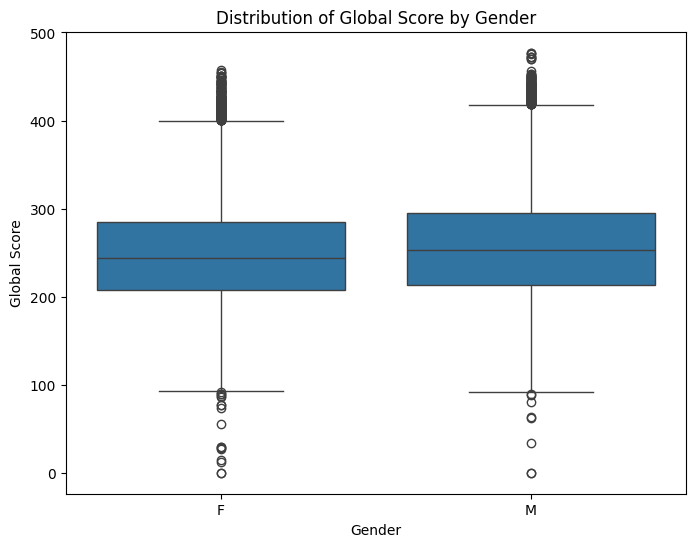

In [ ]:
mean_global_score_by_gender = df00.groupby('ESTU_GENERO')['PUNT_GLOBAL'].mean()

print("Mean Global Score by Gender:")
display(mean_global_score_by_gender)

plt.figure(figsize=(8, 6))
sns.boxplot(x='ESTU_GENERO', y='PUNT_GLOBAL', data=df00)
plt.title('Distribution of Global Score by Gender')
plt.xlabel('Gender')
plt.ylabel('Global Score')
plt.show()



- El puntaje medio es ligeramente superior en los hombres frente a las mujeres.

- El rango intercuartílico (50 % central de los datos) es muy similar en ambos grupos, lo que indica dispersiones comparables.

- Los bigotes del boxplot muestran alcances similares en ambos géneros.

- Los outliers aparecen en ambos casos, reflejando que hay estudiantes con resultados muy bajos y otros con resultados muy altos en ambos grupos

###¿El puntaje varia segun el nivel educativo de los padres?



Puntaje Global Promedio según Nivel Educativo de la Madre:


,PUNT_GLOBAL
FAMI_EDUCACIONMADRE,
Ninguno,211.427004
Primaria incompleta,228.95211
Primaria completa,233.506177
Secundaria (Bachillerato) incompleta,238.87397
Otros,239.938579
Secundaria (Bachillerato) completa,249.581732
Técnica o tecnológica incompleta,260.168417
Técnica o tecnológica completa,268.376476
Educación profesional incompleta,272.865478


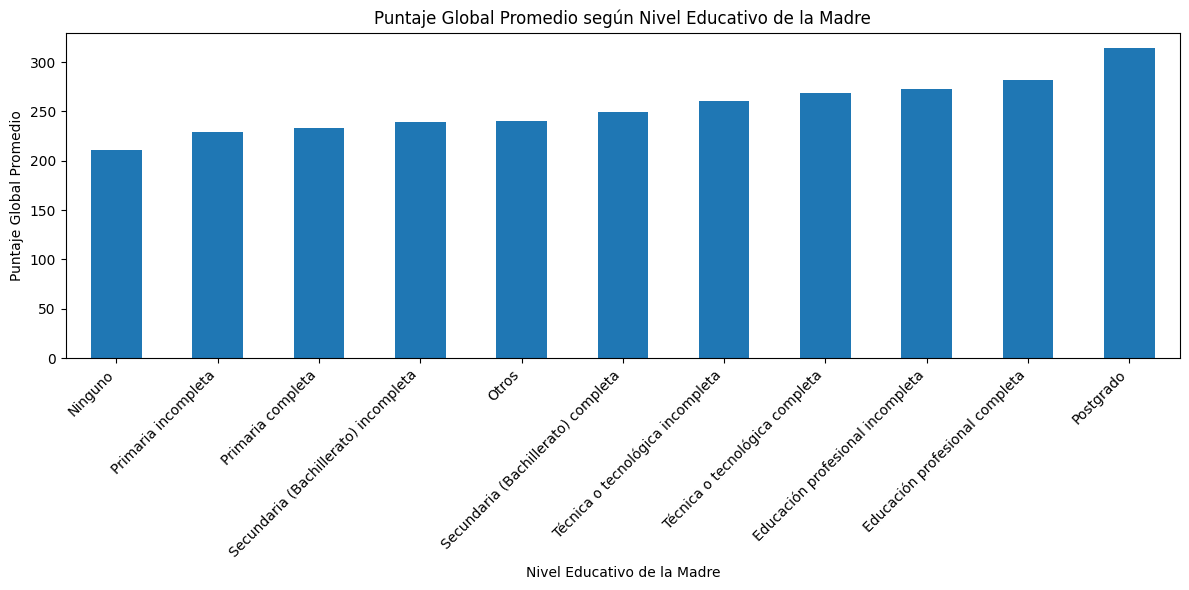


Puntaje Global Promedio según Nivel Educativo del Padre:


,PUNT_GLOBAL
FAMI_EDUCACIONPADRE,
Ninguno,214.780063
Primaria incompleta,233.880419
Primaria completa,238.115722
Secundaria (Bachillerato) incompleta,243.903902
Otros,248.29817
Secundaria (Bachillerato) completa,251.759502
Técnica o tecnológica incompleta,260.591176
Técnica o tecnológica completa,270.383665
Educación profesional incompleta,275.774979


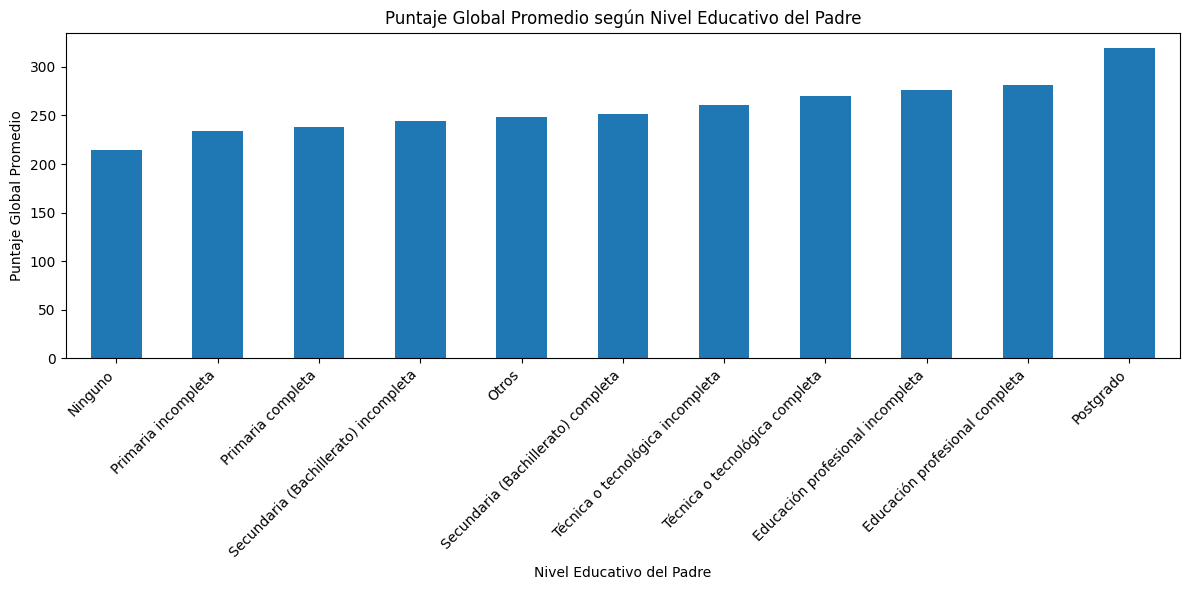

In [ ]:
mean_global_score_by_mother_education = df00.groupby('FAMI_EDUCACIONMADRE')['PUNT_GLOBAL'].mean().sort_values()

print("Puntaje Global Promedio según Nivel Educativo de la Madre:")
display(mean_global_score_by_mother_education)

plt.figure(figsize=(12, 6))
mean_global_score_by_mother_education.plot(kind='bar')
plt.title("Puntaje Global Promedio según Nivel Educativo de la Madre")
plt.xlabel("Nivel Educativo de la Madre")
plt.ylabel("Puntaje Global Promedio")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


mean_global_score_by_father_education = df00.groupby('FAMI_EDUCACIONPADRE')['PUNT_GLOBAL'].mean().sort_values()

print("\nPuntaje Global Promedio según Nivel Educativo del Padre:")
display(mean_global_score_by_father_education)

plt.figure(figsize=(12, 6))
mean_global_score_by_father_education.plot(kind='bar')
plt.title("Puntaje Global Promedio según Nivel Educativo del Padre")
plt.xlabel("Nivel Educativo del Padre")
plt.ylabel("Puntaje Global Promedio")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Tanto para el nivel educativo de la madre como para el del padre, se observa un patrón consistente: a medida que aumenta el nivel educativo de los padres, el puntaje global promedio de los estudiantes también aumenta, aunque de manera moderada.
Esto se refleja en los gráficos como una tendencia levemente creciente entre los niveles educativos más bajos y los más altos. Las diferencias no son extremas, pero sí marcan una relación positiva entre educación parental y desempeño académico.

###¿El puntaje aumenta a medida que aumenta el estrato del estudiante?

Puntaje Global Promedio según Estrato de Vivienda:


,PUNT_GLOBAL
FAMI_ESTRATOVIVIENDA,
Estrato 1,239.672616
Estrato 2,252.697914
Estrato 3,263.591403
Estrato 4,272.155485
Estrato 5,277.107034
Estrato 6,280.491712
Sin Estrato,213.012792


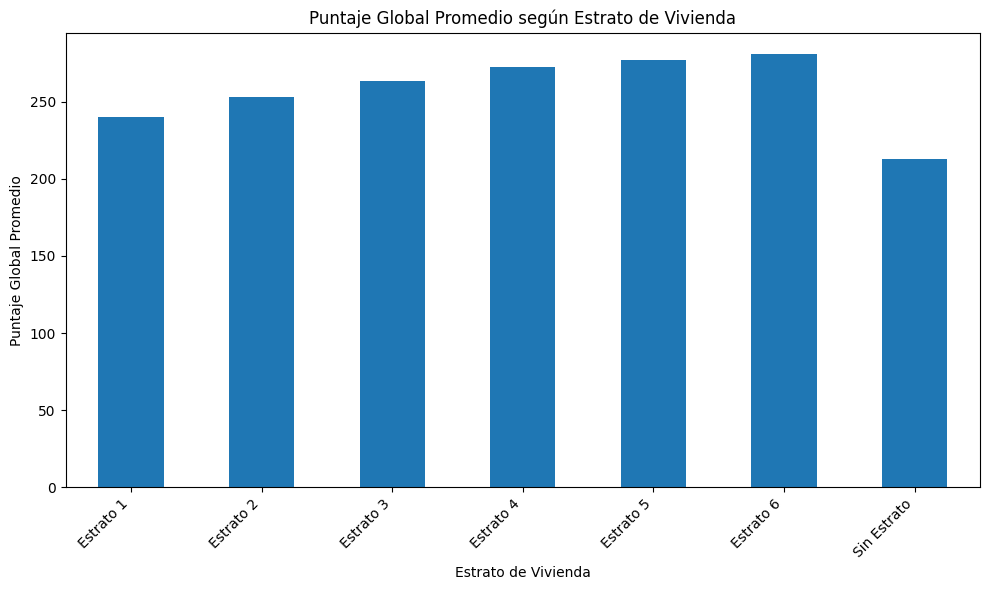

In [ ]:
stratum_order = ['Estrato 1', 'Estrato 2', 'Estrato 3', 'Estrato 4', 'Estrato 5', 'Estrato 6', 'Sin Estrato']

mean_global_score_by_stratum = df00.groupby('FAMI_ESTRATOVIVIENDA')['PUNT_GLOBAL'].mean()

mean_global_score_by_stratum = mean_global_score_by_stratum.reindex(stratum_order)


print("Puntaje Global Promedio según Estrato de Vivienda:")
display(mean_global_score_by_stratum)

plt.figure(figsize=(10, 6))
mean_global_score_by_stratum.plot(kind='bar')
plt.title("Puntaje Global Promedio según Estrato de Vivienda")
plt.xlabel("Estrato de Vivienda")
plt.ylabel("Puntaje Global Promedio")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Al analizar el puntaje global por estrato socioeconómico se observa que, en promedio, los estudiantes de estratos más altos obtienen puntajes ligeramente superiores a los de estratos más bajos. Sin embargo, la relación no es muy pronunciada: el aumento en el puntaje es leve a medida que aumenta el estrato.

##Preguntas respecto al acceso a recursos del hogar

###¿Hay diferencia en el puntaje cuando el estudiante cuenta con acceso a internet?

Mean Global Score by Internet Access:


,PUNT_GLOBAL
FAMI_TIENEINTERNET,
False,228.390614
True,259.328413


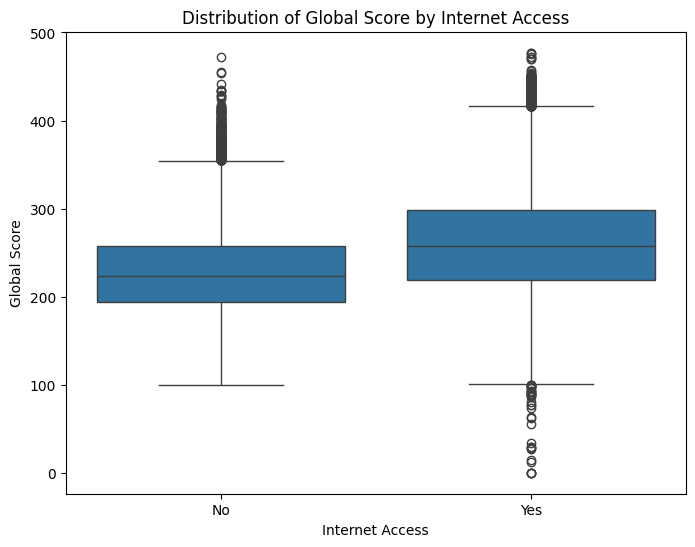

In [ ]:
mean_global_score_by_internet = df00.groupby('FAMI_TIENEINTERNET')['PUNT_GLOBAL'].mean()

print("Mean Global Score by Internet Access:")
display(mean_global_score_by_internet)

plt.figure(figsize=(8, 6))
sns.boxplot(x='FAMI_TIENEINTERNET', y='PUNT_GLOBAL', data=df00)
plt.title('Distribution of Global Score by Internet Access')
plt.xlabel('Internet Access')
plt.ylabel('Global Score')
plt.xticks([0, 1], ['No', 'Yes'])
plt.show()


- La media del puntaje global es superior para los estudiantes que cuentan con acceso a internet, lo que sugiere un efecto positivo del recurso en el desempeño general.
- El 50% central de los puntajes (del primer al tercer cuartil) se encuentra más alto cuando el estudiante tiene internet, esto indica que la mayoría de los estudiantes con acceso a internet obtienen resultados mejores que la mayoría de los que no lo tienen.
- El bigote superior es más alto en el grupo con internet, mostrando que los estudiantes de mayor rendimiento alcanzan puntajes aún superiores.
- En los estudiantes con internet, existen outliers por debajo del bigote inferior, mostrando que algunos estudiantes obtienen puntajes muy bajos a pesar de tener acceso. Los outliers superiores son similares en ambos grupos, indicando que los mejores resultados se logran tanto con como sin internet.

###¿Hay diferencia en el puntaje cuando el estudiante cuenta con acceso a computador?

Mean Global Score by Computer Access:


,PUNT_GLOBAL
FAMI_TIENECOMPUTADOR,
False,233.527304
True,266.557229


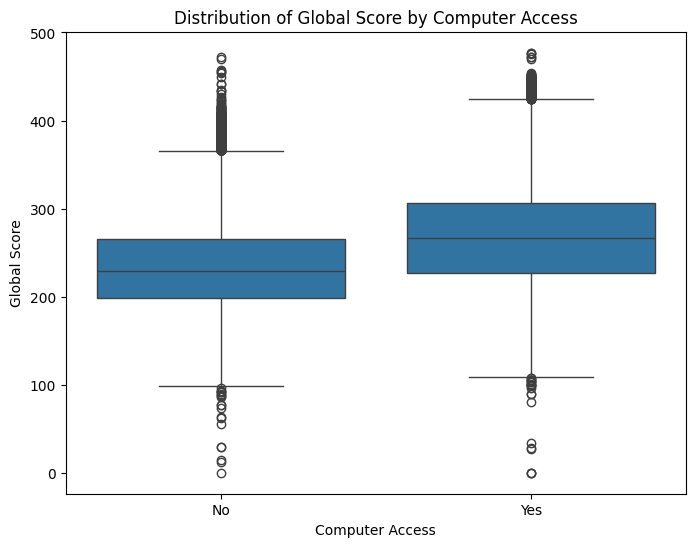

In [ ]:
mean_global_score_by_computer = df00.groupby('FAMI_TIENECOMPUTADOR')['PUNT_GLOBAL'].mean()

print("Mean Global Score by Computer Access:")
display(mean_global_score_by_computer)

plt.figure(figsize=(8, 6))
sns.boxplot(x='FAMI_TIENECOMPUTADOR', y='PUNT_GLOBAL', data=df00)
plt.title('Distribution of Global Score by Computer Access')
plt.xlabel('Computer Access')
plt.ylabel('Global Score')
plt.xticks([0, 1], ['No', 'Yes']) # Assuming False is 0 and True is 1
plt.show()

- La media del puntaje global de los estudiantes que no cuentan con computador es inferior a la de aquellos que sí lo poseen, indicando que el acceso a computador se asocia con un mejor desempeño promedio.
- El 50% central de los datos (del primer al tercer cuartil) está ubicado más arriba en los estudiantes con computador, lo que sugiere que la mayoría de estos estudiantes obtuvo mejores resultados en comparación con los que no lo tienen.
- El bigote inferior se encuentra en posiciones similares para ambos grupos, indicando que los puntajes más bajos no difieren mucho. El bigote superior de los estudiantes con computador se encuentra más alto, mostrando que los puntajes más altos son mayores en este grupo.
- La distribución de valores atípicos es similar entre los dos grupos, por lo que los extremos raros no afectan significativamente la comparación general.

###¿Hay diferencia en el puntaje cuando el estudiante cuenta con lavadora?

Mean Global Score by Washing Machine Access:


,PUNT_GLOBAL
FAMI_TIENELAVADORA,
False,234.975607
True,255.975211


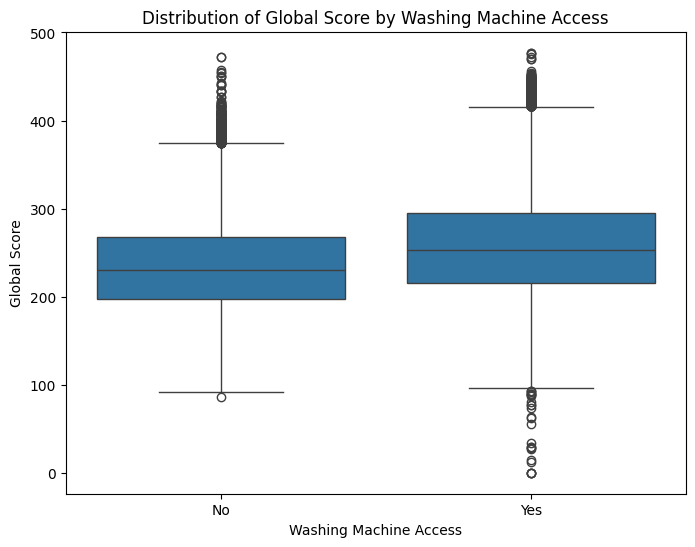

In [ ]:
mean_global_score_by_lavadora = df00.groupby('FAMI_TIENELAVADORA')['PUNT_GLOBAL'].mean()

print("Mean Global Score by Washing Machine Access:")
display(mean_global_score_by_lavadora)

plt.figure(figsize=(8, 6))
sns.boxplot(x='FAMI_TIENELAVADORA', y='PUNT_GLOBAL', data=df00)
plt.title('Distribution of Global Score by Washing Machine Access')
plt.xlabel('Washing Machine Access')
plt.ylabel('Global Score')
plt.xticks([0, 1], ['No', 'Yes']) # Assuming False is 0 and True is 1
plt.show()

- La media del puntaje global de los estudiantes con lavadora es ligeramente mayor que la de quienes no la tienen.
- El 50% central de los datos (del primer al tercer cuartil) está ubicado levemente más arriba en los estudiantes con lavadora, lo que sugiere que la mayoría de estos estudiantes obtuvo mejores resultados en comparación con los que no lo tienen.
- Los bigotes inferiores son similares en ambos grupos, mientras que el bigote superior es levemente más largo en el grupo con lavadora, sugiriendo algunos puntajes altos más extremos.
- Los outliers superiores son similares en ambos casos. Los outliers inferiores muestran que algunos estudiantes con lavadora tienen puntajes muy bajos, lo que indica que tener lavadora no garantiza necesariamente un buen desempeño.

###¿Hay diferencia en el puntaje cuando el estudiante cuanta con internet, computador y lavadora?

Mean Global Score by Access to Internet, Computer, and Washing Machine:


,PUNT_GLOBAL
HAS_ALL_RESOURCES,
False,235.279401
True,270.234089


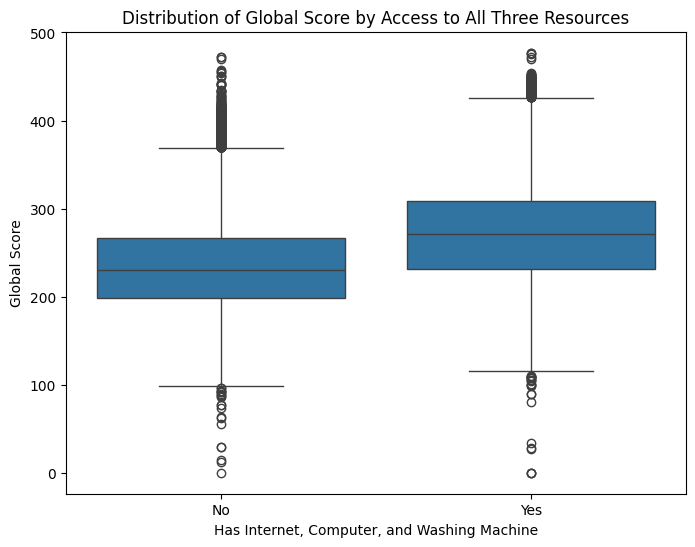

In [ ]:
df00['HAS_ALL_RESOURCES'] = df00['FAMI_TIENEINTERNET'] & df00['FAMI_TIENECOMPUTADOR'] & df00['FAMI_TIENELAVADORA']

mean_global_score_by_all_resources = df00.groupby('HAS_ALL_RESOURCES')['PUNT_GLOBAL'].mean()

print("Mean Global Score by Access to Internet, Computer, and Washing Machine:")
display(mean_global_score_by_all_resources)

plt.figure(figsize=(8, 6))
sns.boxplot(x='HAS_ALL_RESOURCES', y='PUNT_GLOBAL', data=df00)
plt.title('Distribution of Global Score by Access to All Three Resources')
plt.xlabel('Has Internet, Computer, and Washing Machine')
plt.ylabel('Global Score')
plt.xticks([0, 1], ['No', 'Yes'])
plt.show()

- Indica que, en promedio, los estudiantes que cuentan con internet, computador y lavadora obtienen mejores puntajes globales.
- El 50% central de los estudiantes con los tres recursos se encuentra en rangos de puntaje más altos que los que no los tienen, lo que refuerza la ventaja.
- Los bigotes inferiores son similares. El bigote superior es mas alto en el grupo con los tres recursos.
- Los outliers se distribuyen de forma similar en ambos casos.

###¿El acceso a internet reduce la brecha de puntajes entre estratos?

Puntaje Global Promedio por Estrato Socioeconómico y Acceso a Internet:


FAMI_TIENEINTERNET,False,True
FAMI_ESTRATOVIVIENDA,,
Estrato 1,232.057037,245.05139
Estrato 2,233.641371,257.355067
Estrato 3,223.541114,268.168066
Estrato 4,207.926358,280.268613
Estrato 5,205.541775,288.544335
Estrato 6,202.7869,296.174455
Sin Estrato,206.773523,222.800539


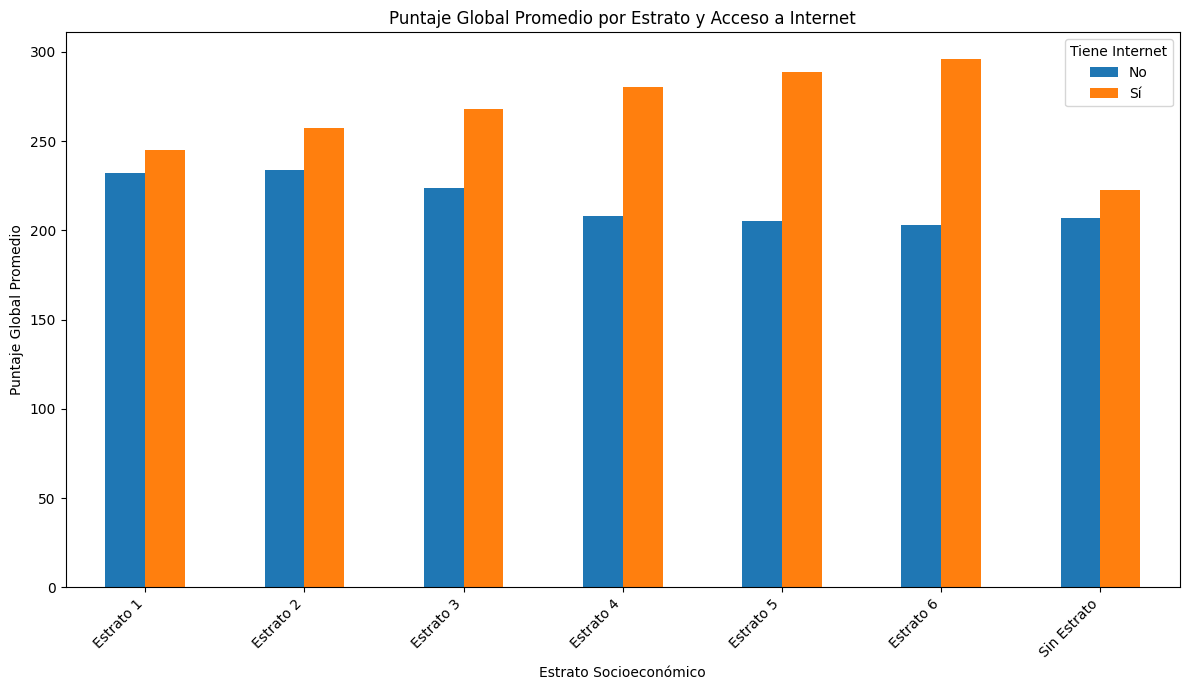

In [ ]:
mean_score_by_stratum_and_internet = df00.groupby(['FAMI_ESTRATOVIVIENDA', 'FAMI_TIENEINTERNET'])['PUNT_GLOBAL'].mean().unstack()

print("Puntaje Global Promedio por Estrato Socioeconómico y Acceso a Internet:")
display(mean_score_by_stratum_and_internet)

stratum_order = ['Estrato 1', 'Estrato 2', 'Estrato 3', 'Estrato 4', 'Estrato 5', 'Estrato 6', 'Sin Estrato']

mean_score_by_stratum_and_internet.reindex(stratum_order).plot(kind='bar', figsize=(12, 7))
plt.title('Puntaje Global Promedio por Estrato y Acceso a Internet')
plt.xlabel('Estrato Socioeconómico')
plt.ylabel('Puntaje Global Promedio')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Tiene Internet', labels=['No', 'Sí'])
plt.tight_layout()
plt.show()

El acceso a internet mejora el rendimiento académico dentro de cada estrato, pero no reduce la brecha de puntajes entre estratos. Más bien, el internet potencia la ventaja de los estratos más altos, aunque sigue siendo un factor positivo para todos.

###¿Que proporción de estudiantes tienen acceso a internet por estrato?

In [ ]:
stratum_order = ['Estrato 1', 'Estrato 2', 'Estrato 3', 'Estrato 4', 'Estrato 5', 'Estrato 6', 'Sin Estrato']

contingency_table_internet_stratum = pd.crosstab(df00['FAMI_ESTRATOVIVIENDA'], df00['FAMI_TIENEINTERNET'], normalize='index') * 100

contingency_table_internet_stratum = contingency_table_internet_stratum.reindex(stratum_order)


print("--- Proporción de Estudiantes con Acceso a Internet por Estrato (%) ---")
display(contingency_table_internet_stratum.round(2))

--- Proporción de Estudiantes con Acceso a Internet por Estrato (%) ---


FAMI_TIENEINTERNET,False,True
FAMI_ESTRATOVIVIENDA,,
Estrato 1,41.39,58.61
Estrato 2,19.64,80.36
Estrato 3,10.26,89.74
Estrato 4,11.21,88.79
Estrato 5,13.78,86.22
Estrato 6,16.79,83.21
Sin Estrato,61.07,38.93


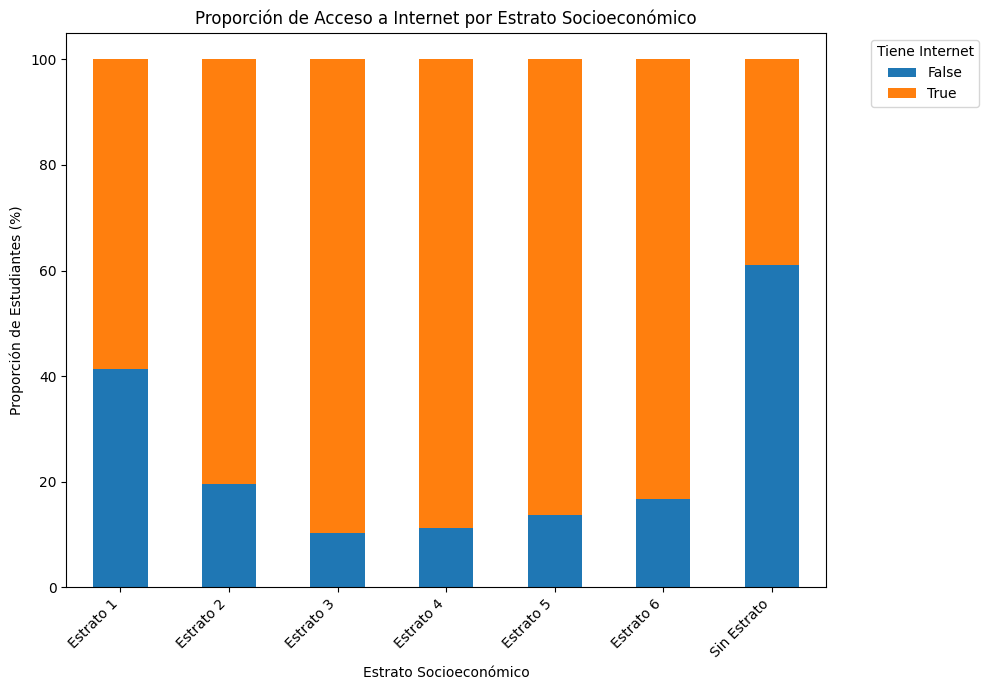

In [ ]:
contingency_table_internet_stratum.plot(kind='bar', stacked=True, figsize=(10, 7))
plt.title('Proporción de Acceso a Internet por Estrato Socioeconómico')
plt.xlabel('Estrato Socioeconómico')
plt.ylabel('Proporción de Estudiantes (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Tiene Internet', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

- En los estratos bajos (1 y 2), la proporción de estudiantes sin internet es alta, lo que refleja menor acceso a recursos tecnológicos.

- En estrato 3 la proporción baja, indicando más estudiantes con acceso.

- Luego, en los estratos más altos (4, 5, 6), hay un ligero aumento en la proporción sin internet.

##Preguntas respecto a las caracteristicas de la institución

###¿Hay diferencias en el puntaje según la jornada de la institución?

Mean Global Score by School Jornada:


,PUNT_GLOBAL
COLE_JORNADA,
NOCHE,211.52928
SABATINA,213.948956
TARDE,245.668529
MAÑANA,248.99381
UNICA,252.318426
COMPLETA,285.772038


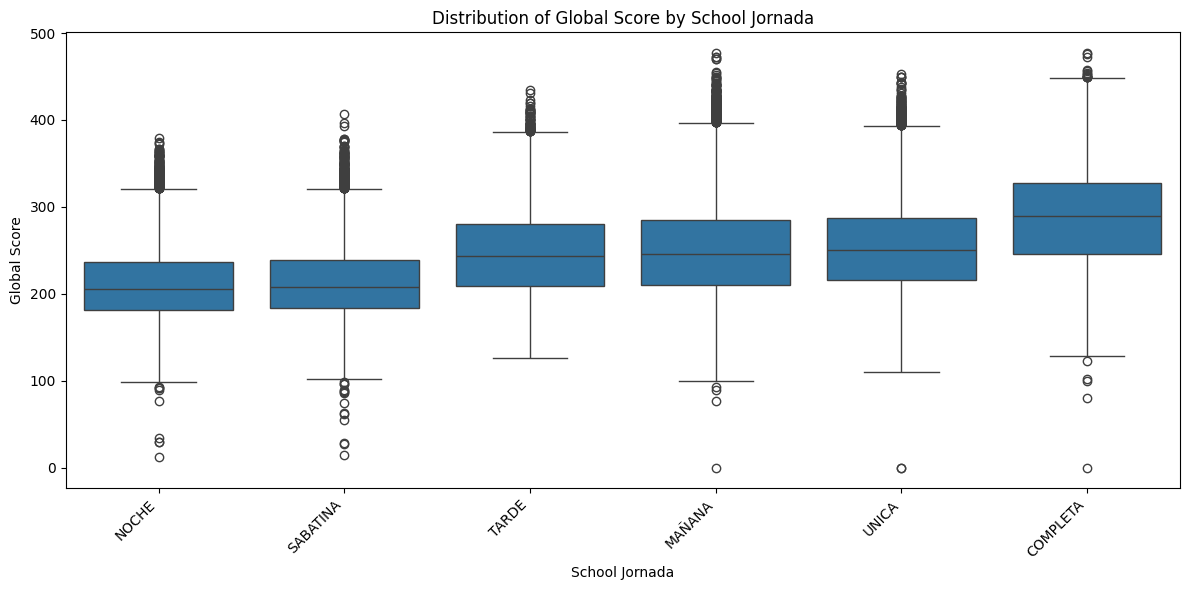

In [ ]:
mean_global_score_by_jornada = df00.groupby('COLE_JORNADA')['PUNT_GLOBAL'].mean().sort_values()

print("Mean Global Score by School Jornada:")
display(mean_global_score_by_jornada)

plt.figure(figsize=(12, 6))
sns.boxplot(x='COLE_JORNADA', y='PUNT_GLOBAL', data=df00, order=mean_global_score_by_jornada.index)
plt.title('Distribution of Global Score by School Jornada')
plt.xlabel('School Jornada')
plt.ylabel('Global Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

- La jornada COMPLETA presenta la mediana más alta, seguida de UNICA, MAÑANA y TARDE, mientras las jornadas SABATINA y NOCHE muestran las medianas más bajas. Esto sugiere que la duración y organización de la jornada están relacionadas con el rendimiento académico.

- La amplitud de la caja (IQR) es relativamente similar en la mayoría de jornadas. La jornada COMPLETA puede mostrar una distribución ligeramente más concentrada en el rango superior.

- Las jornadas COMPLETA y UNICA tienen bigotes que alcanzan puntajes más altos que SABATINA y NOCHE.

- Todos los tipos de jornada presentan valores atípicos, tanto altos como bajos. Pero los outliers superiores alcanzan valores mas grandes en jornada MAÑANA y COMPLETA.

###¿Hay diferencia en el puntaje cuando el colegio es oficial o no?

Mean Global Score by School Nature:


,PUNT_GLOBAL
COLE_NATURALEZA,
OFICIAL,243.747942
NO OFICIAL,274.551645


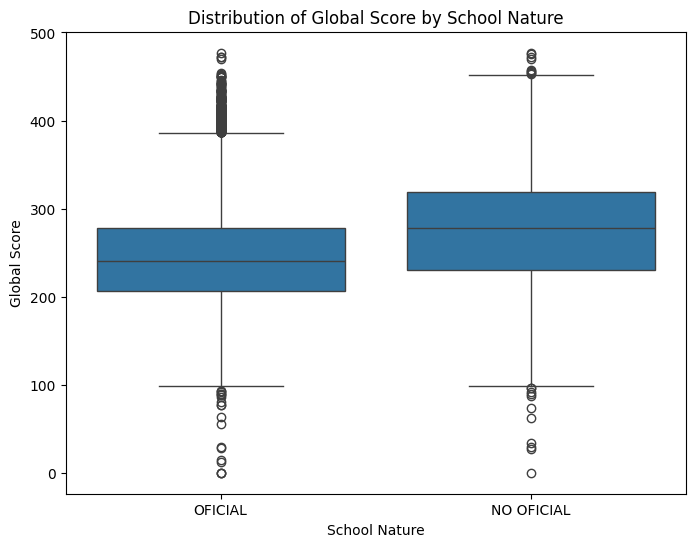

In [ ]:
mean_global_score_by_nature = df00.groupby('COLE_NATURALEZA')['PUNT_GLOBAL'].mean().sort_values()

print("Mean Global Score by School Nature:")
display(mean_global_score_by_nature)

plt.figure(figsize=(8, 6))
sns.boxplot(x='COLE_NATURALEZA', y='PUNT_GLOBAL', data=df00, order=mean_global_score_by_nature.index)
plt.title('Distribution of Global Score by School Nature')
plt.xlabel('School Nature')
plt.ylabel('Global Score')
plt.show()

- Los colegios no oficiales presentan una media de puntaje global más alta que los colegios oficiales.
- La mitad central de los puntajes de los colegios no oficiales se concentra en un rango superior al de los colegios oficiales, indicando que sus estudiantes tienden a puntuar más alto en general.
- Los límites inferiores (mínimos) son similares en ambos tipos de colegio. Los límites superiores (máximos) son más altos en los colegios no oficiales, mostrando que los puntajes más altos se encuentran en este grupo.
- La distribución de valores atípicos es similar entre colegios oficiales y no oficiales, indicando que la presencia de puntajes extremos no difiere significativamente entre los dos grupos.

###¿Hay diferencias en el puntaje global entre colegios rurales y urbanos?

Mean Global Score by School Area:


,PUNT_GLOBAL
COLE_AREA_UBICACION,
RURAL,231.261526
URBANO,255.648828


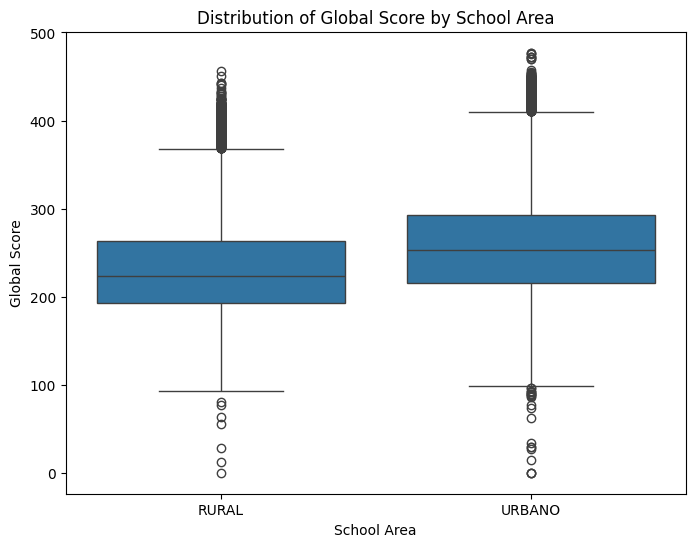

In [ ]:
mean_global_score_by_area = df00.groupby('COLE_AREA_UBICACION')['PUNT_GLOBAL'].mean().sort_values()

print("Mean Global Score by School Area:")
display(mean_global_score_by_area)

plt.figure(figsize=(8, 6))
sns.boxplot(x='COLE_AREA_UBICACION', y='PUNT_GLOBAL', data=df00, order=mean_global_score_by_area.index)
plt.title('Distribution of Global Score by School Area')
plt.xlabel('School Area')
plt.ylabel('Global Score')
plt.show()

- Los colegios urbanos presentan una media ligeramente superior a la de los colegios rurales, lo que indica que, en promedio, los estudiantes urbanos obtienen mejores resultados.
- El rango intercuartílico de los colegios urbanos se sitúa en un nivel más alto que el de los colegios rurales, confirmando que la mayoría de los puntajes urbanos tienden a ser mejores.
- Los bigotes inferiores son similares en ambos casos, mostrando que los puntajes más bajos no difieren mucho entre zonas. Sin embargo, el bigote superior de los colegios urbanos es más alto, indicando que los puntajes más altos en estos colegios son superiores a los de los rurales.
- La distribución de outliers es similar en ambos tipos de colegios, aunque los outliers superiores de los urbanos alcanzan valores más altos que los de los rurales.

###¿Hay mayor dispersión en puntaje global en zonas rurales frente a urbanas?

In [ ]:
# Calculate descriptive statistics for Global Score by School Area, including specific quantiles for IQR
global_score_stats_by_area = df00.groupby('COLE_AREA_UBICACION')['PUNT_GLOBAL'].agg(
    mean='mean',
    std='std',
    min='min',
    max='max',
    Q1=lambda x: x.quantile(0.25),
    Q3=lambda x: x.quantile(0.75)
)

print("Estadísticas Descriptivas para el Puntaje Global por Área de Ubicación del Colegio:")
display(global_score_stats_by_area)

# Calculate the Rango Intercuartílico (IQR) using the calculated Q1 and Q3
iqr_urban = global_score_stats_by_area.loc['URBANO', 'Q3'] - global_score_stats_by_area.loc['URBANO', 'Q1']
iqr_rural = global_score_stats_by_area.loc['RURAL', 'Q3'] - global_score_stats_by_area.loc['RURAL', 'Q1']


print(f"\nRango Intercuartílico (IQR) para el Puntaje Global en áreas Urbanas: {iqr_urban:.2f}")
print(f"Rango Intercuartílico (IQR) para el Puntaje Global en áreas Rurales: {iqr_rural:.2f}")

# Interpretación basada en la desviación estándar y el IQR
print("\nInterpretación de la Dispersión:")
if global_score_stats_by_area.loc['RURAL', 'std'] > global_score_stats_by_area.loc['URBANO', 'std']:
    print("- La desviación estándar es mayor en las áreas Rurales, lo que sugiere una mayor variabilidad en los puntajes globales en comparación con las áreas Urbanas.")
else:
    print("- La desviación estándar es mayor en las áreas Urbanas, lo que sugiere una mayor variabilidad en los puntajes globales en comparación con las áreas Rurales.")

if iqr_rural > iqr_urban:
     print("- El Rango Intercuartílico (IQR) es mayor en las áreas Rurales, lo que indica una mayor dispersión en el 50% central de los puntajes en comparación con las áreas Urbanas.")
else:
     print("- El Rango Intercuartílico (IQR) es mayor en las áreas Urbanas, lo que indica una mayor dispersión en el 50% central de los puntajes en comparación con las áreas Rurales.")

Estadísticas Descriptivas para el Puntaje Global por Área de Ubicación del Colegio:


,mean,std,min,max,Q1,Q3
COLE_AREA_UBICACION,,,,,,
RURAL,231.261526,49.625369,0,456,193,263
URBANO,255.648828,52.245079,0,477,215,293



Rango Intercuartílico (IQR) para el Puntaje Global en áreas Urbanas: 78.00
Rango Intercuartílico (IQR) para el Puntaje Global en áreas Rurales: 70.00

Interpretación de la Dispersión:
- La desviación estándar es mayor en las áreas Urbanas, lo que sugiere una mayor variabilidad en los puntajes globales en comparación con las áreas Rurales.
- El Rango Intercuartílico (IQR) es mayor en las áreas Urbanas, lo que indica una mayor dispersión en el 50% central de los puntajes en comparación con las áreas Rurales.


##Preguntas respecto a la geografia y el tiempo

###¿Cuales son los municipios con los puntajes globales mas bajos?

In [ ]:
mean_global_score_by_municipio = df00.groupby('ESTU_COD_RESIDE_MCPIO')['PUNT_GLOBAL'].mean()

lowest_score_municipios = mean_global_score_by_municipio.sort_values(ascending=True)

print("Municipios con los puntajes globales promedio más bajos:")
display(lowest_score_municipios.head(10))

Municipios con los puntajes globales promedio más bajos:


,PUNT_GLOBAL
ESTU_COD_RESIDE_MCPIO,
27372,168.545455
27099,170.316667
27250,173.0
27025,177.752381
27425,181.333333
19418,181.688679
27580,181.923077
27413,183.411765
19809,183.711765


Los municipios con puntaje global medio mas bajo son:
- 27372: Juradó (Chocó)

- 27099: Bojayá (Chocó)

- 27250: El Litoral del San Juan (Chocó)

- 27025: Atrato (Chocó)

- 27425: Medio Atrato (Chocó)

- 19418: López (Cauca)

- 27580: Río Iró (Chocó)

- 27413: Lloró (Chocó)

- 19809: Timbiquí (Cauca)

- 91460: Mirití-Paraná (Amazonas)

###¿Cual periodo acedemico obtuvo mejores resultados?

In [ ]:
mean_global_score_by_period = df00.groupby('PERIODO')['PUNT_GLOBAL'].mean().sort_values(ascending=False)

print("Puntaje Global Promedio por Periodo Académico:")
display(mean_global_score_by_period)

best_period = mean_global_score_by_period.index[0]
best_score = mean_global_score_by_period.iloc[0]

print(f"\nEl periodo académico con el puntaje global promedio más alto es {best_period} con un puntaje promedio de {best_score:.2f}.")

Puntaje Global Promedio por Periodo Académico:


,PUNT_GLOBAL
PERIODO,
20221,284.919479
20224,250.318863



El periodo académico con el puntaje global promedio más alto es 20221 con un puntaje promedio de 284.92.


# Definición de Problemas



A partir de los datos observados se realizan las siguientes anotaciones iniciales para la propuesta del proyecto:

* Identificar a estudiantes con bajo rendimiento que además enfrentan desventajas socioeconómicas, para priorizar apoyos o intervenciones educativas.



* Detección de brechas educativas en zonas vulnerables con ayuda de identificación de grupos.

## Brechas Educativas en Zonas Vulnerables

En Colombia enfrentamos desigualdad en la calidad y acceso a la educación, especialmente en zonas rurales. Por lo que millones de estudiantes en todo el territorio ven afectado su rendimiento. Viéndose reflejado en la prueba del ICFES, con peores resultados en las zonas periféricas que en las grandes ciudades.

Esto se debe a una falta de identificación de grupos de estudiantes con características similares en cuanto a las falencias académicas; generando así, brechas educativas que se manifiestan en el país.

Con ayuda de una herramienta que permita diseñar intervenciones educativas, se puede generar una ayuda focalizada a estos grupos vulnerables acorde a sus necesidades. Con la intención de lograr un mejor desempeño y avance en sus actividades académicas.


### Objetivo

Detectar y caracterizar grupos (clusters) de estudiantes y sedes escolares que muestren brechas educativas, teniendo en cuenta factores socioeconómicos y geográficos con énfasis en identificar zonas vulnerables para priorizar políticas e intervenciones.

#### Preguntas a resolver

* ¿Existen agrupamientos que combinan el bajo rendimiento con las condiciones socioeconómicas y geográficas?

* ¿Qué variables explican mejor las brechas?

* ¿En qué municipios/departamentos están concentrados los clusters más vulnerables?

### Justificación

La identificación de clusters naturales en la población estudiantil permitirá:

* Optimizar la asignación de recursos educativos
* Diseñar políticas públicas basadas en evidencia
* Desarrollar estrategias pedagógicas diferenciadas
* Focalizar intervenciones en los grupos más vulnerables



### Variables de Estudio

#### Variables Socioeconómicas

* FAMI_ESTRATOVIVIENDA (Estrato socioeconómico 1-6)
* FAMI_EDUCACIONMADRE (Nivel educativo madre)
* FAMI_EDUCACIONPADRE (Nivel educativo padre)
* FAMI_TIENECOMPUTADOR (Acceso a computador)
* FAMI_TIENEINTERNET (Acceso a internet)
* FAMI_TIENELAVADORA (Acceso a lavadora)
* FAMI_PERSONASHOGAR (Número de personas en hogar)

#### Variables Geográficas e Institucionales

* COLE_AREA_UBICACION (Urbano/Rural)
* COLE_BILINGUE (Colegio bilingüe)
* COLE_CARACTER (Carácter académico/técnico)
* COLE_JORNADA (Jornada escolar)
* COLE_NATURALEZA (Oficial/No oficial)
* ESTU_COD_RESIDE_MCPIO (Código municipio)

#### Variables Demográficas

* ESTU_GENERO (Género)
* EDAD (Edad del estudiante)

#### Variables Dependientes

Estas variables son las designadas para realizar el análisis tras el agrupamiento de los grupos identificados.

* PUNT_INGLES (Puntaje inglés)
* PUNT_MATEMATICAS (Puntaje matemáticas)
* PUNT_SOCIALES_CIUDADANAS (Puntaje sociales)
* PUNT_C_NATURALES (Puntaje ciencias naturales)
* PUNT_LECTURA_CRITICA (Puntaje lectura crítica)
* PUNT_GLOBAL (Puntaje global)
* DESEMP_INGLES (Desempeño en inglés)

##Clasificación de Desempeño y Vulnerabilidad

En Colombia, la desigualdad socioeconómica y geográfica impacta el rendimiento académico. Estudiantes que viven en zonas rurales o de bajos estratos enfrentan barreras que afectan su desempeño en pruebas estandarizadas como el ICFES. Detectar grupos de estudiantes con bajo rendimiento y condiciones socioeconómicas vulnerables permite diseñar estrategias focalizadas que reduzcan estas brechas.
Esto se debe a que no existe un método sistemático que identifique a los estudiantes que presentan bajo desempeño académico junto con condiciones socioeconómicas desfavorables. Esto dificulta:

- Identificar a los estudiantes más vulnerables que requieren apoyo educativo.

- Diseñar intervenciones focalizadas según características socioeconómicas y geográficas.

- Priorizar recursos y políticas públicas basadas en evidencia

###Objetivo
Clasificar a los estudiantes según su desempeño académico (sobre o bajo la media del puntaje global) y su nivel de vulnerabilidad socioeconómica, considerando factores como estrato, educación de los padres, acceso a recursos del hogar y ubicación geográfica, con el fin de focalizar estrategias de apoyo educativo.

Preguntas a resolver:
- ¿Qué estudiantes presentan bajo desempeño académico y condiciones socioeconómicas desfavorables?

- ¿Qué variables explican mejor la combinación de bajo desempeño y vulnerabilidad?

- ¿Existen patrones geográficos o institucionales que concentren a los estudiantes más vulnerables?

###Variables de estudio


####Variables Socioeconómicas:

- FAMI_ESTRATOVIVIENDA → Estrato socioeconómico del estudiante (1-6).

- FAMI_EDUCACIONMADRE → Nivel educativo de la madre.

- FAMI_EDUCACIONPADRE → Nivel educativo del padre.

- FAMI_TIENECOMPUTADOR → Acceso a computador (Sí/No).

- FAMI_TIENEINTERNET → Acceso a internet (Sí/No).

- FAMI_TIENELAVADORA → Acceso a lavadora (Sí/No).

- FAMI_PERSONASHOGAR → Número de personas en el hogar.



####Variables Geográficas e Institucionales:

- COLE_AREA_UBICACION → Urbano / Rural.

- COLE_BILINGUE → Colegio bilingüe (Sí/No).

- COLE_CARACTER → Carácter del colegio (académico, técnico, etc.).

- COLE_JORNADA → Jornada escolar.

- COLE_NATURALEZA → Oficial / No oficial.

- ESTU_COD_RESIDE_MCPIO → Código del municipio de residencia.



####Variables Demográficas:

- ESTU_GENERO → Masculino / Femenino.

- EDAD → Edad del estudiante.


####Variable Dependiente (objetivo de clasificación):

- CLASIFICACION_PUNT_GLOBAL → 0: Bajo rendimiento + vulnerabilidad, 1: Rendimiento alto o condiciones no vulnerables.

# Definición de Modelado

In [ ]:
#Librerias Iniciales

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import NearestNeighbors
from sklearn.base import BaseEstimator, TransformerMixin
import joblib
import scipy
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.utils import shuffle
from sklearn.cluster import MiniBatchKMeans
import time
from concurrent.futures import ProcessPoolExecutor, as_completed
import time
import warnings
warnings.filterwarnings('ignore')
from itertools import product

##Clasificación de Desempeño y Vulnerabilidad

###Predicción de resultados

Si bien el análisis de clústeres permitió identificar perfiles diferenciados de estudiantes según sus condiciones socioeconómicas y académicas, persiste la necesidad de contar con una herramienta que prediga de manera anticipada el desempeño de un estudiante a partir de sus características observables. En el contexto educativo, la capacidad de anticipar si un alumno tendrá un rendimiento bajo, medio o alto resulta fundamental para orientar intervenciones focalizadas, asignación de recursos y diseño de estrategias pedagógicas que reduzcan las brechas de inequidad. Sin un modelo predictivo, las instituciones educativas dependen únicamente de evaluaciones a posteriori, lo que limita la oportunidad de actuar preventivamente sobre los factores de riesgo.

### Cargar y preparar los datos

Cargar los datos directamente desde df00 y seleccionar las variables predictoras (socioeconómicas y de contexto) y la variable objetivo (desempeño académico, por ejemplo, PUNT_GLOBAL o DESEMP_INGLES).

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import Binarizer


df_prediccion = df00.copy()

# Define the target variable for classification (e.g., PUNT_GLOBAL > median)
median_punt_global = df_prediccion['PUNT_GLOBAL'].median()
df_prediccion['CLASIFICACION_PUNT_GLOBAL'] = (df_prediccion['PUNT_GLOBAL'] > median_punt_global).astype(int)



predictor_vars = [col for col in df_prediccion.columns if col not in ['PUNT_INGLES', 'PUNT_MATEMATICAS', 'PUNT_SOCIALES_CIUDADANAS', 'PUNT_C_NATURALES', 'PUNT_LECTURA_CRITICA', 'PUNT_GLOBAL', 'DESEMP_INGLES', 'CLUSTER', 'HAS_ALL_RESOURCES', 'CLASIFICACION_PUNT_GLOBAL']]

X = df_prediccion[predictor_vars]
y = df_prediccion['CLASIFICACION_PUNT_GLOBAL']

# Identify numerical and categorical features for preprocessing
numerical_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include='object').columns.tolist()
categorical_features.extend(X.select_dtypes(include='category').columns.tolist())

print("Caracteristicas numericas:", numerical_features)
print("Categoricas:", categorical_features)

Caracteristicas numericas: ['EDAD']
Categoricas: ['PERIODO', 'COLE_AREA_UBICACION', 'COLE_CARACTER', 'COLE_JORNADA', 'COLE_NATURALEZA', 'ESTU_COD_RESIDE_DEPTO', 'ESTU_COD_RESIDE_MCPIO', 'ESTU_GENERO', 'FAMI_EDUCACIONMADRE', 'FAMI_EDUCACIONPADRE', 'FAMI_ESTRATOVIVIENDA', 'FAMI_PERSONASHOGAR']


### Seleccionar y preparar algoritmos

Ahora se hace la eleccion de cada modelo para poder predecir los resultados que se tienen


#### Modelo lineal: Regresión logistica

Se eligió la Regresión Logística como punto de partida por varias razones, especialmente para una tarea de clasificación binaria



1.  **Interpretabilidad:** Es un modelo lineal que permite entender cómo cada variable predictora influye en la probabilidad de la clase positiva a través de sus coeficientes. Esto ayuda a identificar qué factores están linealmente asociados con un mayor o menor puntaje global.
2.  **Eficiencia Computacional:** Rápido de entrenar
3.  **Punto de Comparación Base:** Sirve como una línea base simple para comparar el rendimiento de modelos más complejos

Permite entender de forma sencilla cómo variables como el estrato socioeconómico, la educación de los padres, o el tipo de colegio se relacionan linealmente con la probabilidad de obtener un puntaje global alto.

In [ ]:
  from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import numpy as np

numerical_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include='object').columns.tolist()
categorical_features.extend(X.select_dtypes(include='category').columns.tolist())


numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])


preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

X_processed = preprocessor.fit_transform(X)

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42, stratify=y) # Use stratify for classification

# Inicializar y entrenar el modelo de Regresión Logística
logistic_reg_model = LogisticRegression(random_state=42, solver='liblinear') # Use solver suitable for large datasets
logistic_reg_model.fit(X_train, y_train)

LogisticRegression(random_state=42, solver='liblinear')

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# Realizar predicciones en el conjunto de prueba
y_pred_lr = logistic_reg_model.predict(X_test)

# Ensure y_test and y_pred_lr have no NaNs for evaluation (although fillna was done earlier)
not_nan_indices = y_test.dropna().index

# Filter both y_test and y_pred_lr using these indices
y_test_filtered = y_test.loc[not_nan_indices]
y_pred_lr_filtered = y_pred_lr[y_test.index.get_indexer(not_nan_indices)]

# Evaluar el modelo
accuracy_lr = accuracy_score(y_test_filtered, y_pred_lr_filtered)
f1_lr = f1_score(y_test_filtered, y_pred_lr_filtered)
cm_lr = confusion_matrix(y_test_filtered, y_pred_lr_filtered)


print(f"Regresión Logística - Accuracy: {accuracy_lr:.2f}")
print(f"Regresión Logística - F1 Score: {f1_lr:.2f}")
print("Regresión Logística - Confusion Matrix:")
display(cm_lr)

Regresión Logística - Accuracy: 0.71
Regresión Logística - F1 Score: 0.71
Regresión Logística - Confusion Matrix:


array([[38087, 17280],
       [15022, 39761]])

Basado en las métricas de Accuracy (`0.71`) y F1 Score (`0.71`), el modelo de Regresión Logística demuestra una capacidad razonable para clasificar correctamente a los estudiantes según su puntaje global . La matriz de confusión muestra la distribución de las predicciones correctas e incorrectas, indicando un balance en la predicción de ambas clases.

#### *Árbol de Decisión*

Dado como se comportan algunas variables (como categorías de educación, tipos de colegio, etc.) y la posibilidad de que la relación entre estas y el puntaje global no sea una línea recta simple, un Árbol de Decisión es útil. Este modelo puede, por ejemplo, identificar reglas como: "si el estudiante es de estrato 1 Y la madre no terminó primaria, su puntaje global tiende a ser bajo", o "si es de colegio urbano Y tiene computador, su puntaje es más alto". Nos ayuda a descubrir estas combinaciones específicas de características que influyen en el rendimiento, que una regresión lineal sola no vería.

In [ ]:
from sklearn.tree import DecisionTreeRegressor

# Inicializar y entrenar el modelo de Árbol de Decisión para Regresión
# Se puede ajustar el parámetro max_depth para controlar la complejidad del árbol y evitar overfitting
decision_tree_model = DecisionTreeRegressor(random_state=42, max_depth=10) # Limitar la profundidad para eficiencia y generalización
decision_tree_model.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=10, random_state=42)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import numpy as np
import pandas as pd



decision_tree_model = DecisionTreeClassifier(random_state=42, max_depth=10) # Limitar la profundidad para eficiencia y generalización
decision_tree_model.fit(X_train, y_train)



y_pred_dt = decision_tree_model.predict(X_test)


not_nan_indices = y_test.dropna().index


y_test_filtered = y_test.loc[not_nan_indices]
y_pred_dt_filtered = y_pred_dt[y_test.index.get_indexer(not_nan_indices)]




# Evaluar el modelo
accuracy_dt = accuracy_score(y_test_filtered, y_pred_dt_filtered)
f1_dt = f1_score(y_test_filtered, y_pred_dt_filtered)
cm_dt = confusion_matrix(y_test_filtered, y_pred_dt_filtered)


print(f"Árbol de Decisión para Clasificación - Accuracy: {accuracy_dt:.2f}")
print(f"Árbol de Decisión para Clasificación - F1 Score: {f1_dt:.2f}")
print("Árbol de Decisión para Clasificación - Confusion Matrix:")
display(cm_dt)

Árbol de Decisión para Clasificación - Accuracy: 0.67
Árbol de Decisión para Clasificación - F1 Score: 0.69
Árbol de Decisión para Clasificación - Confusion Matrix:


array([[34605, 20762],
       [15180, 39603]])

El modelo de Árbol de Decisión fue capaz de capturar algunas relaciones no lineales y patrones basados en reglas en los datos. Las métricas muestran si hubo una mejora en el rendimiento predictivo en comparación con la Regresión Lineal, lo que sugeriría que las relaciones no lineales son relevantes en este dataset. El R2 indica qué tan bien el modelo se ajusta a los datos a través de sus divisiones basadas en características.

### *Modelo de ensamble: Gradient Boosting Regressor*

Se utilizó este modelo avanzado debido a la complejidad de predecir el desempeño académico, que depende de múltiples factores interactivos. El Gradient Boosting, al construir secuencialmente árboles de decisión y corregir errores, es capaz de modelar estas interacciones complejas en el dataset. Esto permite una predicción más precisa del PUNT_GLOBAL al considerar cómo la combinación de diferentes variables de contexto y socioeconómicas afecta el resultado.


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import numpy as np
import pandas as pd



subset_size = 100000
if X_train.shape[0] > subset_size:
    import numpy as np
    subset_indices = np.random.choice(X_train.shape[0], subset_size, replace=False)
    X_train_subset = X_train[subset_indices]
    y_train_subset = y_train.iloc[subset_indices]
    print(f"Entrenando Gradient Boosting Classifier en un subconjunto de {subset_size} muestras...")
    gbr_model = GradientBoostingClassifier(random_state=42, n_estimators=100, learning_rate=0.1, max_depth=3) # Parámetros iniciales
    gbr_model.fit(X_train_subset, y_train_subset)
else:
    print("Entrenando Gradient Boosting Classifier en el conjunto de entrenamiento completo...")
    gbr_model = GradientBoostingClassifier(random_state=42, n_estimators=100, learning_rate=0.1, max_depth=3) # Parámetros iniciales
    gbr_model.fit(X_train, y_train)


y_pred_gbr = gbr_model.predict(X_test)


not_nan_indices = y_test.dropna().index


y_test_filtered = y_test.loc[not_nan_indices]
y_pred_gbr_filtered = y_pred_gbr[y_test.index.get_indexer(not_nan_indices)]



# Evaluar el modelo
accuracy_gbr = accuracy_score(y_test_filtered, y_pred_gbr_filtered)
f1_gbr = f1_score(y_test_filtered, y_pred_gbr_filtered)
cm_gbr = confusion_matrix(y_test_filtered, y_pred_gbr_filtered)

print(f"Gradient Boosting Classifier - Accuracy: {accuracy_gbr:.2f}")
print(f"Gradient Boosting Classifier - F1 Score: {f1_gbr:.2f}")
print("Gradient Boosting Classifier - Confusion Matrix:")
display(cm_gbr)

Entrenando Gradient Boosting Classifier en un subconjunto de 100000 muestras...
Gradient Boosting Classifier - Accuracy: 0.70
Gradient Boosting Classifier - F1 Score: 0.70
Gradient Boosting Classifier - Confusion Matrix:


array([[37940, 17427],
       [15851, 38932]])

### Comparación y Selección del Mejor Modelo

Ahora se comparan las métricas de evaluación de los tres modelos entrenados para determinar cuál tuvo el mejor desempeño en la predicción del puntaje global.

In [ ]:
import pandas as pd

comparison_df = pd.DataFrame({
    'Modelo': ['Regresión Logística', 'Árbol de Decisión', 'Gradient Boosting'],
    'Accuracy': [accuracy_lr, accuracy_dt, accuracy_gbr],
    'F1 Score': [f1_lr, f1_dt, f1_gbr]
})

print("Comparación de Métricas de los Modelos:")
display(comparison_df.sort_values(by='F1 Score', ascending=False))

# Seleccionar el mejor modelo basado en F1 Score
best_model_name = comparison_df.loc[comparison_df['F1 Score'].idxmax(), 'Modelo']
print(f"\nEl mejor modelo basado en F1 Score es: {best_model_name}")

Comparación de Métricas de los Modelos:


,Modelo,Accuracy,F1 Score
0,Regresión Logística,0.706745,0.711135
2,Gradient Boosting,0.696024,0.699367
1,Árbol de Decisión,0.673700,0.687863



El mejor modelo basado en F1 Score es: Regresión Logística


### Pruebas con variables

Basándonos en el modelo seleccionado, se analiza la importancia de las variables predictoras y se extraen conclusiones sobre los factores que más influyen en el desempeño académico.


Top 5 (features transformadas / dummies):


,Feature,Importance,Parent
797,ESTU_COD_RESIDE_MCPIO_52390,2.853960,ESTU_COD_RESIDE_MCPIO
782,ESTU_COD_RESIDE_MCPIO_52250,2.374646,ESTU_COD_RESIDE_MCPIO
771,ESTU_COD_RESIDE_MCPIO_52079,2.312688,ESTU_COD_RESIDE_MCPIO
802,ESTU_COD_RESIDE_MCPIO_52427,2.279563,ESTU_COD_RESIDE_MCPIO
236,ESTU_COD_RESIDE_MCPIO_13688,2.203461,ESTU_COD_RESIDE_MCPIO



Top 5 (VARIABLES ORIGINALES agrupadas):


,Parent,Importance
0,ESTU_COD_RESIDE_MCPIO,485.559893
1,ESTU_COD_RESIDE_DEPTO,13.807155
2,FAMI_EDUCACIONMADRE,4.106934
3,COLE_JORNADA,3.429778
4,FAMI_EDUCACIONPADRE,3.301017


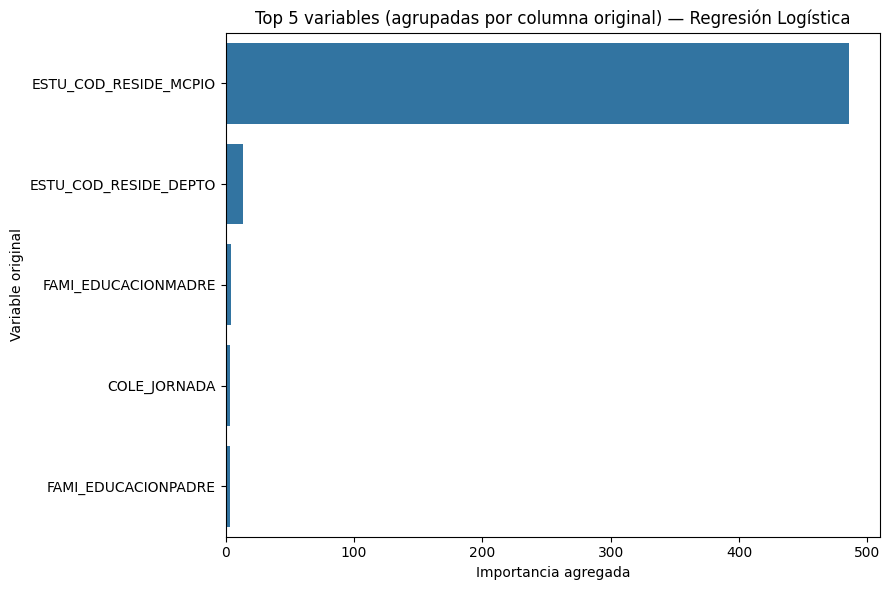

In [ ]:
# === Importancias / Coeficientes del MEJOR MODELO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


if best_model_name in ['Gradient Boosting', 'GradientBoosting', 'GB']:
    model_to_explain = gbr_model
    mode = "trees"
elif best_model_name in ['Árbol de Decisión', 'Decision Tree', 'DT']:
    model_to_explain = decision_tree_model
    mode = "trees"
else:

    model_to_explain = logistic_reg_model
    mode = "linear"


ohe = None
try:
    ohe = preprocessor.named_transformers_['cat']['onehot']
except Exception:
    try:
        ohe = preprocessor.named_transformers_['cat']['ohe']
    except Exception:
        ohe = None

if ohe is not None:
    ohe_names = list(ohe.get_feature_names_out(categorical_features))
else:
    n_ohe = X_processed.shape[1] - len(numerical_features)
    ohe_names = [f"OHE_{i}" for i in range(n_ohe)]

processed_feature_names = list(numerical_features) + ohe_names


if mode == "trees":
    importances = np.asarray(model_to_explain.feature_importances_)
elif mode == "linear":
    coefs = np.asarray(model_to_explain.coef_)

    if coefs.ndim == 2:
        importances = np.mean(np.abs(coefs), axis=0)
    else:
        importances = np.abs(coefs)
else:
    raise ValueError("Modo no reconocido.")


n = min(len(processed_feature_names), len(importances))
feat_df = pd.DataFrame({
    "Feature": processed_feature_names[:n],
    "Importance": importances[:n]
})


def parent_of(feature_name):
    for c in categorical_features:
        prefix = f"{c}_"
        if feature_name.startswith(prefix):
            return c
    return feature_name

feat_df["Parent"] = feat_df["Feature"].apply(parent_of)

top_n = 5
top15_dummies = feat_df.sort_values("Importance", ascending=False).head(top_n)
top15_parents = (feat_df.groupby("Parent")["Importance"]
                         .sum()
                         .sort_values(ascending=False)
                         .head(top_n)
                         .reset_index())

print(f"\nTop {top_n} (features transformadas / dummies):")
display(top15_dummies)

print(f"\nTop {top_n} (VARIABLES ORIGINALES agrupadas):")
display(top15_parents)




plt.figure(figsize=(9, 6))
sns.barplot(x="Importance", y="Parent", data=top15_parents)
plt.title(f"Top {top_n} variables  — {best_model_name}")


plt.xlabel("Importancia agregada")
plt.ylabel("Variable original")
plt.tight_layout()
plt.show()

### Conclusiones del Problema de Clasificación de Desempeño y Vulnerabilidad



**Mejor Modelo:** Basado en la comparación de métricas de clasificación (Accuracy y F1 Score), el modelo de **Regresión Logística** demostró ser el más efectivo para predecir si un estudiante obtendrá un puntaje global por encima o por debajo de la mediana.

*   **Métricas del Mejor Modelo (Regresión Logística):**
    *   Accuracy: 0.71
    *   F1 Score: 0.71
    *   Confusion Matrix:  Indica la cantidad de verdaderos positivos, verdaderos negativos, falsos positivos y falsos negativos.

El Accuracy y F1 Score de 0.71 sugieren que el modelo tiene una capacidad razonable para distinguir entre estudiantes con desempeño por encima y por debajo de la mediana, aunque no es una clasificación perfecta.

*   **Factores Clave:** Según el análisis de coeficientes del modelo de Regresión Logística , las variables con mayor impacto en la *probabilidad* de que un estudiante obtenga un puntaje global por encima de la mediana incluyen:

    *   **Códigos de Municipio (ESTU_COD_RESIDE_MCPIO):** Varios códigos de municipio muestran coeficientes altos . Esto reitera la fuerte influencia del contexto geográfico y socioeconómico a nivel municipal en el desempeño académico. Un coeficiente positivo para un municipio específico indica que residir en ese municipio aumenta la probabilidad de obtener un puntaje por encima de la mediana, mientras que un coeficiente negativo la disminuye.

    *   **Factores Socioeconómicos :** Aunque los coeficientes específicos pueden variar, variables como el estrato, educación de los padres y acceso a recursos del hogar (computador, internet) típicamente tienen coeficientes positivos, indicando que condiciones socioeconómicas más favorables aumentan la probabilidad de obtener un puntaje por encima de la mediana.

Estos hallazgos son cruciales para diseñar intervenciones educativas. La fuerte influencia de los códigos de municipio sugiere que las políticas educativas y los recursos deben ser focalizados geográficamente, prestando especial atención a los municipios asociados con coeficientes negativos significativos. La edad como factor relevante indica la necesidad de programas de apoyo específicos para estudiantes mayores o aquellos que han experimentado interrupciones en su trayectoria educativa. La influencia de factores socioeconómicos resalta la necesidad de programas de equidad educativa y acceso a recursos.

*   **Limitaciones y Futuras Mejoras:** Una limitación del modelo es que un Accuracy y F1 Score de 0.71, si bien son razonables, indican que hay espacio para mejorar. El modelo aún comete errores en aproximadamente el 29% de los casos. Esto sugiere que:
    *   Hay otros factores no incluidos en este dataset que influyen en el desempeño académico.
    *   Las relaciones entre las variables y el desempeño pueden no ser estrictamente lineales, aunque la Regresión Logística resultó ser el mejor *entre los modelos probados* para esta tarea de clasificación binaria.

Para futuras mejoras, se podría explorar:
*   La inclusión de variables adicionales si estuvieran disponibles

*   La exploración de modelos no lineales más complejos específicamente adaptados para clasificación, aunque la comparación actual no mostró una mejora significativa con Árboles de Decisión o Gradient Boosting con los parámetros usados.

*   Un análisis más detallado de los municipios específicos con coeficientes extremos para entender qué características los hacen diferentes.

## Brechas Educativas en Zonas Vulnerables

En este caso, como se buscará un agrupamiento de los estudiantes con más falencias. Primero será aplicado PCA, para posteriormente realizar un K-Means y DBSCAN con la intención de identificar la estructura del dataset y reducir la dimensionalidad para los dos algoritmos de clustering.

### Preprocesamiento para Primer Problema

Se decide volver a revisar el dataset limpio para tener claridad sobre como se puede pre-procesar para el caso de agrupamiento

In [ ]:
df = pd.read_csv("datos_limpios.csv")

#Mostrar info general del Dataset Limpio
print("=== Información general del dataset ===")
print(df.info())
print("\nNúmero de filas y columnas:", df.shape)

#Revisión de valores únicos por columna
print("\n===Revisión de valores únicos por columna===")
for col in df.columns:
    valores_unicos = df[col].unique()
    n_unicos = df[col].nunique(dropna=True)
    print(f"\nColumna: {col}")
    print(f" - Tipo de dato: {df[col].dtype}")
    print(f" - Valores únicos (total={n_unicos}):")
    #Mostrar solo los primeros 20 valores distintos
    print(valores_unicos[:20])
    if n_unicos > 20:
        print(" ... (hay más valores)")

A partir del dataset limpio se generan diferentes funciones para prepararlo para PCA y agrupamiento c:

In [ ]:
#Con el dataset limpiose crea una copia para trabajar
df = pd.read_csv("datos_limpios.csv")
df_agrupamiento = df.copy()

#Se realiza un pre-procesamiento más ligero para estos 3 modelos con 3 funciones auxiliares
#Educación → ordinal
def map_education_level(x):
    if pd.isna(x):
        return 0
    x = str(x).strip().lower()
    mapping = {
        "ninguno": 0,
        "primaria": 1,
        "secundaria": 2,
        "media": 3,
        "técnica": 4,
        "tecnica": 4,
        "tecnológica": 5,
        "tecnologica": 5,
        "universitaria": 6,
        "posgrado": 7,
        "especialización": 7,
        "maestría": 8,
        "maestria": 8,
        "doctorado": 9
    }
    return mapping.get(x, 0)

#Binario sí/no
def bin_to_int(x):
    if pd.isna(x):
        return 0
    s = str(x).strip().lower()
    if s in ["si", "sí", "s", "yes", "y", "1", "true", "t"]:
        return 1
    return 0

#Limpiar los miembros de familia
def clean_household_members(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if "a" in s:
        try:
            low, high = map(int, s.replace(" ", "").split("a"))
            return (low + high) / 2
        except:
            return np.nan
    try:
        return int(s)
    except:
        return np.nan

###VARIABLES
#Educación madre/padre
for col in ["FAMI_EDUCACIONMADRE", "FAMI_EDUCACIONPADRE"]:
    if col in df_agrupamiento.columns:
        df_agrupamiento[col + "_ORD"] = df_agrupamiento[col].apply(map_education_level)

#Recursos hogar
for col in ["FAMI_TIENECOMPUTADOR", "FAMI_TIENEINTERNET"]:
    if col in df_agrupamiento.columns:
        df_agrupamiento[col + "_B"] = df_agrupamiento[col].apply(bin_to_int)

#Colegio bilingüe
if "COLE_BILINGUE" in df_agrupamiento.columns:
    df_agrupamiento["COLE_BILINGUE_B"] = df_agrupamiento["COLE_BILINGUE"].apply(bin_to_int)

#Género (OneHot)
if "ESTU_GENERO" in df_agrupamiento.columns:
    df_agrupamiento["GENERO_CAT"] = df_agrupamiento["ESTU_GENERO"].fillna("UNK").astype(str)

#Estrato
if "FAMI_ESTRATOVIVIENDA" in df_agrupamiento.columns:
    df_agrupamiento["FAMI_ESTRATOVIVIENDA"] = pd.to_numeric(
        df_agrupamiento["FAMI_ESTRATOVIVIENDA"], errors="coerce"
    ).fillna(0).astype(int)

#Municipio → frecuencia
if "ESTU_COD_RESIDE_MCPIO" in df_agrupamiento.columns:
    freq = df_agrupamiento["ESTU_COD_RESIDE_MCPIO"].value_counts(normalize=False)
    df_agrupamiento["MCPIO_FREQ"] = df_agrupamiento["ESTU_COD_RESIDE_MCPIO"].map(freq).fillna(0).astype(int)

#Puntaje de recursos hogar
df_agrupamiento["SCORE_RECURSOS_HOGAR"] = (
    df_agrupamiento.get("FAMI_TIENECOMPUTADOR_B", 0)
    + df_agrupamiento.get("FAMI_TIENEINTERNET_B", 0)
)

#Miembros de familia por hogar
if "FAMI_PERSONASHOGAR" in df_agrupamiento.columns:
    df_agrupamiento["FAMI_PERSONASHOGAR"] = df_agrupamiento["FAMI_PERSONASHOGAR"].apply(clean_household_members)



### Proceso de Modelado para Primer Problema

#### 1. PCA para Primer Problema



Se realiza el pre-procesamiento para todas las features elegidas

In [ ]:
###FEATURES
numeric_features = [
    "FAMI_ESTRATOVIVIENDA", "FAMI_PERSONASHOGAR", "EDAD",
    "MCPIO_FREQ", "SCORE_RECURSOS_HOGAR",
    "FAMI_EDUCACIONMADRE_ORD", "FAMI_EDUCACIONPADRE_ORD"
]

categorical_features = [
    "COLE_AREA_UBICACION", "COLE_CARACTER",
    "COLE_JORNADA", "COLE_NATURALEZA", "GENERO_CAT"
]

###PRE-PROCESAMIENTO
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

#Aplicar el preprocesador
X_Final = preprocessor.fit_transform(df_agrupamiento)
print("Tipo de X_transformed:", type(X_Final))
print("Shape transformado:", X_Final.shape)

Se realiza el PCA con su análisis de varianza

In [ ]:
#PCA completo para análisis de varianza
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_Final)

#Calcular varianza explicada
explained_variance_ratio = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

#Encontrar componentes para 85%, 90%, 95% de varianza
n_components_85 = np.argmax(cumulative_variance >= 0.85) + 1
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print(f"Componentes para 85% varianza: {n_components_85}")
print(f"Componentes para 90% varianza: {n_components_90}")
print(f"Componentes para 95% varianza: {n_components_95}")

#Gráfico de varianza explicada
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, alpha=0.7)
plt.xlabel('Componentes Principales')
plt.ylabel('Varianza Explicada')
plt.title('Varianza por Componente')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'ro-', linewidth=2)
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Varianza Acumulada Explicada')
plt.title('Varianza Acumulada')
plt.axhline(y=0.85, color='green', linestyle='--', label='85% varianza')
plt.axhline(y=0.90, color='blue', linestyle='--', label='90% varianza')
plt.axhline(y=0.95, color='red', linestyle='--', label='95% varianza')
plt.axvline(x=n_components_85, color='green', linestyle=':', alpha=0.7)
plt.axvline(x=n_components_90, color='blue', linestyle=':', alpha=0.7)
plt.axvline(x=n_components_95, color='red', linestyle=':', alpha=0.7)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

A partir de estas gráficas obtenidas se puede llegar a la conclusión que el componente 1 explica la mayoría de la varianza y después va reduciéndose rápidamente a partir del 4to o 3ro, pero se puede obtener mejor información.

Por lo que a partir de 10 componentes podemos obtener una buena representación de los datos con ayuda de la varianza acumulada.

#### 1.1 Optimización para PCA

In [ ]:
#Aplicar PCA con 95% de varianza (ajustable)
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_Final)

print(f"Shape after PCA (95% variance): {X_pca.shape}")
print(f"Varianza explicada total: {pca.explained_variance_ratio_.sum():.4f}")

#Visualizar primeros 2 componentes
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6, s=10)
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('Proyección en los dos primeros Componentes Principales')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
#Obtener la importancia de los componentes
loadings = pca.components_
feature_names = (numeric_features +
                preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out().tolist())

#Crear DataFrame de loadings
df_importancia = pd.DataFrame(loadings.T,
                          columns=[f'PC{i+1}' for i in range(loadings.shape[0])],
                          index=feature_names)

#Mostrar variables más importantes para los primeros 5 componentes
print("Variables más importantes por componente:")
for i in range(5):
    print(f"\nPC{i+1}:")
    pc_loadings = df_importancia[f'PC{i+1}'].abs().sort_values(ascending=False)
    print(pc_loadings.head(10))


#### 1.2 Resultados para PCA

Finalmente, del PCA podemos concluir que:

* Se logró una reducción  a 12 componentes principales, que retienen ≈96.5% de la varianza. Creando un espacio ideal para KMeans y DBSCAN porque reduce ruido y mejora la eficiencia, teniendo en cuenta la magnitud de los datos.

* Se obtiene una fuerte relación en la importancia de los recursos del hogar, el estrato socioeconómico y demografía en los componentes finales.



### 2.1 K-Means para Primer Problema

Ya con el PCA realizado, se decide evaluar con el método del codo y con el índice de Davies-Bouldin a K-Means para encontrar el modelo efectivo para agrupar a las personas con deficiencias académicas según los resultados del ICFES.

Ya reducimos el volumen de datos con PCA, sin embargo, aún se sigue manteniendo una alta complejidad. Por lo que se propone tomar un tamaño de muestra menor para realizar el K-Means.

In [ ]:
#Configuración para grandes datasets
np.random.seed(42)
sample_size = 100000
n_init = 5
max_iter = 100

In [ ]:
def stratified_sample(X_pca, sample_size=100000, random_state=42):
    """Muestreo estratificado para análisis de clustering"""
    #Mezclar datos
    X_shuffled = shuffle(X_pca, random_state=random_state)
    #Tomar muestra
    if len(X_shuffled) > sample_size:
        return X_shuffled[:sample_size]
    return X_shuffled

#Crear muestra representativa
X_sample = stratified_sample(X_pca, sample_size=sample_size)
print(f"Tamaño de muestra para análisis: {X_sample.shape}")

#### 2.2 Optimización para K-Means

In [ ]:
def optimized_elbow_method(X, k_range=range(2, 11), batch_size=1000):
    """Método del codo optimizado para grandes datasets"""

    inertias = []
    times = []

    for k in k_range:
        start_time = time.time()

        #Se optimiza con mini-batches
        kmeans = MiniBatchKMeans(
            n_clusters=k,
            batch_size=batch_size,
            random_state=42,
            n_init=3,
            max_iter=50
        )
        kmeans.fit(X)

        inertias.append(kmeans.inertia_)
        times.append(time.time() - start_time)

        print(f"k={k} - Inercia: {kmeans.inertia_:.2f} - Tiempo: {times[-1]:.2f}s")

    return inertias, times, k_range

#Ejecutar método del codo optimizado
print("Ejecutando método del codo optimizado...")
inertias, times, k_range = optimized_elbow_method(X_sample, k_range=range(2, 11))

#Encontrar punto de codo
def find_elbow_point_optimized(inertias, k_range):
    """Encontrar codo usando método de la segunda derivada"""
    differences = np.diff(inertias)
    second_diff = np.diff(differences)
    elbow_point = k_range[np.argmin(second_diff) + 2]
    return elbow_point

optimal_k_elbow = find_elbow_point_optimized(inertias, list(k_range))
print(f"Punto de codo sugerido: k = {optimal_k_elbow}")

Se obtiene que el punto de codo es 7, sin embargo vamos a revisar con el método de la silueta y el índice de Davies.

In [ ]:
def evaluate_clustering_metrics(X, k_values, sample_size=50000):
    """Evaluar métricas de clustering con muestreo"""

    silhouette_scores = []
    db_scores = []

    # Muestra más pequeña para evaluación de métricas (computacionalmente costosas)
    X_metrics = stratified_sample(X, sample_size=min(sample_size, len(X)))

    for k in k_values:
        print(f"Evaluando k={k}...")

        # Entrenar con MiniBatch para velocidad
        kmeans = MiniBatchKMeans(
            n_clusters=k,
            batch_size=2000,
            random_state=42,
            n_init=3,
            max_iter=50
        )
        kmeans.fit(X_metrics)
        labels = kmeans.labels_

        # Calcular métricas
        if len(set(labels)) > 1:
            silhouette_scores.append(silhouette_score(X_metrics, labels))
            db_scores.append(davies_bouldin_score(X_metrics, labels))
        else:
            silhouette_scores.append(np.nan)
            db_scores.append(np.nan)

    return silhouette_scores, db_scores

# Evaluar métricas
print("Evaluando métricas de clustering...")
silhouette_scores, db_scores = evaluate_clustering_metrics(
    X_pca, k_values=range(2, 11), sample_size=50000 # Changed k_range to k_values
)

In [ ]:
#Rango de k usados
k_values = list(range(2, 11))

#Graficar Silhouette
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(k_values, silhouette_scores, marker='o')
plt.title("Coeficiente de Silhouette")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Silhouette score")
plt.grid(True)

#Graficar Davies-Bouldin
plt.subplot(1,2,2)
plt.plot(k_values, db_scores, marker='o', color="red")
plt.title("Índice de Davies-Bouldin")
plt.xlabel("Número de clusters (k)")
plt.ylabel("DB Index")
plt.grid(True)

plt.figure(figsize=(7,5))
plt.plot(k_range, inertias, marker='o')
plt.title("Método del Codo (Elbow)")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")
plt.grid(True)
plt.show()


Según el el coeficiente de la silueta el más óptimo seria el k=3, mientras que según el de Davies-Boilding el óptimo seria el 5 y el método del codo nos indica que el mejor es el 7.

Esta variabilidad indica que hay clusters que se solapan bastante entre si.

A partir de estos resultados se define utilizar un k=5 como valor intermedio entre todas las métricas definidas, ya que en el elbow se obtiene un primer mínimo, en el sillouette se llega a un valor un tanto más cercano a 1 que al resto, y en el índice de Davies-Boiling se obtiene el valor más cercano a 0.

#### 2.3 Modelo Final - KMeans

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
final_kmeans = MiniBatchKMeans(
    n_clusters=5,
    batch_size=10000,
    random_state=42,
    n_init=10,
    max_iter=300,
    tol=1e-5,
    verbose=2,
    compute_labels=True,
    reassignment_ratio=0.01,
    max_no_improvement=20
)

#Entrenamiento con monitoreo de progreso
print("Iniciando entrenamiento...")
final_kmeans.fit(X_pca)

#Predicción
labels = final_kmeans.labels_

#Añadir labels al dataframe original
df_agrupamiento['CLUSTER'] = labels

#Calcular métricas de manera eficiente pero precisa
def calculate_metrics_optimized(X, labels, sample_size=200000):
    """Calcular métricas con muestreo inteligente"""
    unique_labels = np.unique(labels)
    sampled_indices = []

    for label in unique_labels:
        label_indices = np.where(labels == label)[0]
        #Muestra proporcional al tamaño del cluster
        sample_size_cluster = min(50000, max(10000, int(len(label_indices) * 0.2)))

        if len(label_indices) > sample_size_cluster:
            sampled_indices.extend(
                np.random.choice(label_indices, sample_size_cluster, replace=False)
            )
        else:
            sampled_indices.extend(label_indices)

    X_sample = X[sampled_indices]
    labels_sample = labels[sampled_indices]

    silhouette = silhouette_score(X_sample, labels_sample)
    db_index = davies_bouldin_score(X_sample, labels_sample)

    return silhouette, db_index, len(sampled_indices)

#Calcular métricas
silhouette, db_index, sample_size_used = calculate_metrics_optimized(X_pca, labels)
print(f"Tamaño de muestra utilizado: {sample_size_used}")
print(f"Silhouette Score: {silhouette}")
print(f"Índice de Davies-Bouldin: {db_index}")

In [ ]:
#Guardar MiniBatchKMeans
joblib.dump(final_kmeans, "/content/drive/MyDrive/final_kmeans.pkl")
print("✅ Modelo guardado en Drive")

In [ ]:
#Variables para análisis
variables_analisis = [
    'PUNT_INGLES', 'PUNT_MATEMATICAS', 'PUNT_SOCIALES_CIUDADANAS',
    'PUNT_C_NATURALES', 'PUNT_LECTURA_CRITICA', 'PUNT_GLOBAL',
    'FAMI_ESTRATOVIVIENDA', 'FAMI_EDUCACIONMADRE_ORD', 'FAMI_EDUCACIONPADRE_ORD',
    'SCORE_RECURSOS_HOGAR', 'EDAD', 'MCPIO_FREQ'
]

#Calcular estadísticas por cluster
cluster_stats = df_agrupamiento.groupby('CLUSTER')[variables_analisis].agg(['mean', 'std', 'count'])
print("Estadísticas por cluster:")
print(cluster_stats.round(2))

Con estos resultados podemos definir las siguientes conclusiones:

1. Rendimiento Académico (Puntajes de Pruebas)
Los clusters muestran diferencias notorias en el desempeño. Podemos ordenarlos de mejor a peor rendimiento general:

 * Cluster 1 y Cluster 4: Alto Rendimiento. Estos dos grupos son los que obtienen los puntajes más altos en casi todas las materias.

* Cluster 3: Rendimiento Medio. Es el grupo más numeroso (count ~358k). Sus puntajes se ubican en un rango medio en todas las asignaturas (inglés: 49.30, matemáticas: 51.04, sociales: 47.96, naturales: 49.34). Representa probablemente al "estudiante promedio".

* Cluster 0 y Cluster 2: Bajo Rendimiento. Estos dos grupos presentan los puntajes más bajos. El Cluster 0 es el grupo con el rendimiento más bajo en SOCIALES/CIUDADANÍAS (43.03) y el segundo más bajo en las demás materias. Es el grupo más grande de los dos (~251k), lo que indica una población significativa con bajos resultados. Mientras que el Cluster 2 es el grupo más pequeño (~69k) y tiene el rendimiento más bajo en MATEMÁTICAS (45.38) y NATURALES (45.04). Sus puntajes son consistentemente bajos.

2. Entorno Sociofamiliar (Recursos y Educación del Padre)
Aquí encontramos una correlación muy clara con el rendimiento académico, lo cual es un hallazgo esperado pero importante para la identificación de grupos.

* Cluster 4: Tiene el índice más alto de RECURSOS_EN_HOGAR (1.78) y una educación del padre (EDUCACIONPADRE) bastante alta (1.69, solo superado por el 1). Esto explica claramente su alto rendimiento.

* Cluster 1: Tiene un nivel de recursos (1.69) y educación del padre muy alto, coincidiendo con su excelente desempeño académico.

* Cluster con Nivel Sociofamiliar Medio (y Rendimiento Medio):

* Cluster 3: Tiene buenos niveles de recursos (1.52) y educación del padre (1.52), lo que se correlaciona con su rendimiento medio.

* Cluster 0: Tiene los índices más bajos en ambas variables (Recursos: 0.09, Educación Padre: 0.09). Esta grave carencia de recursos y capital educativo en el hogar está directamente asociada con su bajo rendimiento.

* Cluster 2: Tiene un nivel ligeramente superior al Cluster 0 (Recursos: 0.43, Educación Padre: 0.43) pero aún muy por debajo del promedio, lo que se refleja en sus malos resultados académicos.

3. Edad (EDAO)
* El Cluster 2 es claramente un grupo atípico en términos de edad. Con una media de 23.43 años, son significativamente mayores que los otros clusters (cuyas edades oscilan entre 20.25 y 20.80 años).

**Esto sugiere fuertemente que el Cluster 2 podría estar compuesto por estudiantes que han repetido grados o que han regresado a estudiar después de un tiempo. Esta característica única (edad avanzada y bajo rendimiento) lo convierte en un grupo prioritario para intervenciones específicas.**


4. Perfil de cada Cluster
* Cluster 0 - "Vulnerables Socioeconómicamente": El grupo con mayores carencias de recursos y capital educativo en el hogar. Su rendimiento académico es el más bajo. Intervención prioritaria.

* Cluster 1 - "Excelencia Académica": Estudiantes con alto nivel sociofamiliar y el mejor desempeño académico en todas las áreas.

* Cluster 2 - "Rezago Escolar": Estudiantes mayores (posiblemente repitentes o que retomaron estudios). Su rendimiento es bajo a pesar de no tener el peor entorno sociofamiliar. Necesitan apoyo académico y psicosocial específico.

* Cluster 3 - "Mayoría Promedio": El grupo más numeroso. Rendimiento y contexto sociofamiliar medio.

* Cluster 4 - "Privilegiados y de Alto Desempeño": Similar al Cluster 1, con el máximo nivel de recursos en el hogar y un rendimiento académico muy alto.

In [ ]:
 #Gráficos de características por cluster
plt.figure(figsize=(20, 15))

#1. Puntajes académicos
plt.subplot(2, 2, 1)
puntajes_means = df_agrupamiento.groupby('CLUSTER')['PUNT_GLOBAL'].mean()
plt.bar(puntajes_means.index, puntajes_means.values, color='skyblue')
plt.xlabel('Cluster')
plt.ylabel('Puntaje Global Promedio')
plt.title('Puntaje Global por Cluster')
plt.grid(True, alpha=0.3)

#2. Nivel socioeconómico
plt.subplot(2, 2, 2)
estrato_means = df_agrupamiento.groupby('CLUSTER')['FAMI_ESTRATOVIVIENDA'].mean()
plt.bar(estrato_means.index, estrato_means.values, color='lightcoral')
plt.xlabel('Cluster')
plt.ylabel('Estrato Promedio')
plt.title('Nivel Socioeconómico por Cluster')
plt.grid(True, alpha=0.3)

#3. Recursos del hogar
plt.subplot(2, 2, 3)
recursos_means = df_agrupamiento.groupby('CLUSTER')['SCORE_RECURSOS_HOGAR'].mean()
plt.bar(recursos_means.index, recursos_means.values, color='lightgreen')
plt.xlabel('Cluster')
plt.ylabel('Score Recursos Hogar')
plt.title('Recursos del Hogar por Cluster')
plt.grid(True, alpha=0.3)

#4. Educación padres
plt.subplot(2, 2, 4)
educacion_means = df_agrupamiento.groupby('CLUSTER')[['FAMI_EDUCACIONMADRE_ORD', 'FAMI_EDUCACIONPADRE_ORD']].mean()
educacion_means.plot(kind='bar', ax=plt.gca())
plt.xlabel('Cluster')
plt.ylabel('Nivel Educativo (0-9 escala)')
plt.title('Educación de Padres por Cluster')
plt.legend(['Madre', 'Padre'])
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

A partir de estos gráficos podemos concluir que la desigualdad socioeconómica es un fuerte predictor del rendimiento académico. La línea de tendencia en los gráficos es casi perfecta: a mayor estrato y recursos, mayor puntaje global. Esto evidencia que las oportunidades educativas y los resultados no son equitativos.

Los clusters representan realidades sociales concretas. El modelo de clustering ha capturado segmentos de la población que comparten:

* Una condición socioeconómica similar (Estrato, Recursos).

* Un desempeño académico similar (Puntaje Global).

El caso del Cluster 2 se vuelve aún más interesante. Si cruzamos con el análisis anterior:

*  Tiene bajo rendimiento (Gráfico Azul).

* Tiene recursos limitados (Gráfico Verde), aunque no tan extremos como el Cluster 0.

* Pertenece a un estrato bajo (Gráfico Rojo).

Pero su característica única es la edad avanzada (23 años en promedio).


#### 2.4 Análisis de Resultados

In [ ]:
#Calcular brechas relativas
def identificar_clusters_vulnerables(df):
    """Identificar clusters con mayores brechas educativas"""

    #Calcular promedios globales
    promedios_globales = df[variables_analisis].mean()

    #Calcular desviaciones por cluster
    brechas = {}
    for cluster in range(5):
        cluster_data = df[df['CLUSTER'] == cluster]
        brechas[cluster] = (cluster_data[variables_analisis].mean() - promedios_globales) / promedios_globales * 100

    brechas_df = pd.DataFrame(brechas).T
    return brechas_df

#Identificar clusters vulnerables
brechas_df = identificar_clusters_vulnerables(df_agrupamiento)
print("Brechas porcentuales respecto al promedio global:")
print(brechas_df.round(1))

#Identificar clusters más vulnerables
brechas_puntajes = brechas_df[['PUNT_GLOBAL', 'PUNT_MATEMATICAS', 'PUNT_LECTURA_CRITICA']].mean(axis=1)
clusters_vulnerables = brechas_puntajes.sort_values().head(2).index.tolist()
print(f"\nClusters más vulnerables: {clusters_vulnerables}")

Fueron identificados los clústers más vulnerables y se resume de la siguiente manera:

1. Cluster 0: este cluster no solo tiene bajo rendimiento, sino la mayor desventaja socioeconómica.

* Académico: Tienen el peor desempeño. Su Puntaje Global es un -9.5% inferior al promedio. Son especialmente débiles en Inglés (-13.6%) y Sociales (-10.0%).

* Socioeconómio:  Recursos del Hogar (SCORE_RECURSOS_HOGAR): -92.7%. Esto muestra la realidad del país en las zonas más pobres. Tienen menos del 10% de los recursos promedio de un hogar. Es la brecha más grande de toda la tabla.Estrato de la Vivienda: -26.3%. Viven en estratos significativamente más bajos.

* Conclusión: Los estudiantes del Cluster 0 enfrentan una pobreza multidimensional extrema que se refleja directamente en sus resultados académicos. Requieren intervenciones que combinen apoyo académico urgente con programas de alimentación, conectividad y recursos educativos básicos.

2. Cluster 2: este cluster tiene un perfil mixto. No sufre una pobreza tan extrema como el 0, pero su brecha de edad es masiva.

* Académico: su desempeño es muy bajo, similar al Cluster 0 (Puntaje Global: -9.0%). Son los más débiles en Matemáticas (-10.5%).

* Socioeconómico: Su situación es mala pero no tan crítica como la del Cluster 0.Recursos del Hogar: -64.6%. Aunque es una brecha grande, es 30 puntos porcentuales mejor que la del Cluster 0. Estrato: -4.8%. Su estrato está cerca del promedio, a diferencia del Cluster 0.

* Factor Clave - EDAD: +13.5%. Esta es la brecha más importante. Son significativamente mayores que el estudiante promedio. Esto confirma la hipótesis de que son estudiantes que han repetido grado(s) o retomaron sus estudios después de un tiempo.

In [ ]:
#Análisis de distribución geográfica
def analisis_geografico_clusters(df, clusters_vulnerables):
    """Analizar distribución geográfica de clusters vulnerables"""

    #Agrupar por municipio y cluster
    geo_analysis = df.groupby(['ESTU_COD_RESIDE_MCPIO', 'CLUSTER']).size().unstack(fill_value=0)

    #Calcular porcentaje por municipio
    geo_percentage = geo_analysis.div(geo_analysis.sum(axis=1), axis=0) * 100

    #Identificar municipios con alta concentración de clusters vulnerables
    municipios_vulnerables = {}
    for cluster in clusters_vulnerables:
        cluster_col = f'Cluster_{cluster}'
        municipios_cluster = geo_percentage[cluster].sort_values(ascending=False).head(10)
        municipios_vulnerables[cluster] = municipios_cluster

    return municipios_vulnerables, geo_percentage

#Ejecutar análisis geográfico
municipios_vulnerables, geo_percentage = analisis_geografico_clusters(df_agrupamiento, clusters_vulnerables)

print("=== MUNICIPIOS CON MAYOR CONCENTRACIÓN DE CLUSTERS VULNERABLES ===")
for cluster, municipios in municipios_vulnerables.items():
    print(f"\nCluster {cluster} (Vulnerable):")
    for municipio, porcentaje in municipios.items():
        print(f"  Municipio {municipio}: {porcentaje:.1f}%")

Se obtienen los resultados por municipio donde:
1. Cluster 0
    * 97889: Yavaraté (Vaupés)
    * 15293: Gachantivá (Boyacá)
    * 52473: Mosquera (Nariño)
    * 91798: Tarapacá (Amazonas)
    * 94888: Morichal Nuevo (Guainía)
    * 15226: Cuítiva (Boyacá)
    * 27086: Belén de Bajirá (Chocó)
    * 15550: Pisba (Boyacá)
    * 15232: Chíquiza (Boyacá)

1. Cluster 2
    * 15660: San Eduardo (Boyacá)
    * 27745: Sipí (Chocó)
    * 5031: Amalfi (Antioquia)
    * 5142: Caracolí (Antioquia)
    * 15212: Coper (Boyacá)
    * 95015: Calamar (Guaviare)
    * 15518: Pajarito (Boyacá)
    * 76054: Bolívar (Valle del Cauca)
    * 91460: Miriti-Paraná (Amazonas)
    * 68245: El Guacamayo (Santander)

Con estos resultados tenemos que hay municipios muy periféricos como Yavaraté (Vaupés), Tarapacá (Amazonas), Morichal Nuevo (Guainía) y ubicados en zonas fronteizas. También otros con alta dispersión geográfica como los municipios de Boyacá (Gachantivá, Cuítiva, Pisba, Chíquiza) en zonas montañosas. Adicionalmente se identifica presencia en zonas de conflicto como Belén de Bajirá (Chocó). Simplemente se representa la vulnerabilidad y abandono estatal con alta población indígena y economía para vivir el día.

Por otro lado hay otros municipios no tan aislados como Cluster 0 pero con problemas específicos como zonas de post-conflicto como Bolívar (Valle), Pajarito (Boyacá), Calamar (Guaviare) con minería informal (Sipí-Chocó)y agricultura de subsistencia. Identificando así interrupción de trayectorias educativas por conflicto o migración forzada, junto con economías informales que obligan al trabajo temprano y accceso limitado a la educación media y superior.


In [ ]:
#Correlación entre variables socioeconómicas y rendimiento
def analizar_factores_brechas(df):
    """Analizar qué factores explican mejor las brechas"""

    #Calcular correlaciones por cluster
    correlaciones = {}
    for cluster in range(5):
        cluster_data = df[df['CLUSTER'] == cluster]
        corr_matrix = cluster_data[['PUNT_GLOBAL', 'FAMI_ESTRATOVIVIENDA',
                                  'SCORE_RECURSOS_HOGAR', 'FAMI_EDUCACIONMADRE_ORD',
                                  'FAMI_EDUCACIONPADRE_ORD']].corr()
        correlaciones[cluster] = corr_matrix['PUNT_GLOBAL'].drop('PUNT_GLOBAL')

    correlaciones_df = pd.DataFrame(correlaciones)
    return correlaciones_df

#Analizar factores explicativos
factores_brechas = analizar_factores_brechas(df_agrupamiento)
print("Correlación con Puntaje Global por Cluster:")
print(factores_brechas.round(3))

#Identificar variables más explicativas
variables_explicativas = factores_brechas.abs().mean(axis=1).sort_values(ascending=False)
print(f"\nVariables más explicativas de brechas: {variables_explicativas.index.tolist()[:3]}")

Análisis Detallado por Cluster

1. Clúster 0:
FAMI_ESTRATOVIVIENDA: -0.097
SCORE_RECURSOS_HOGAR: 0.006

    Las correlaciones son muy bajas y cercanas a cero, dentro de este grupo de extrema vulnerabilidad, el estrato o los recursos en el hogar no explican las diferencias en el puntaje.

    Por lo que estudiantes en este cluster parten de una base de malos recursos que las pequeñas variaciones en recursos entre ellos no marcan una diferencia significativa en su rendimiento. Otros factores no medidos aquí (como la calidad específica de su escuela, la motivación individual, el apoyo de un profesor en particular, o factores psicosociales) son mucho más importantes para determinar quién sobresale dentro de este entorno.

* Cluster 1
FAMI_ESTRATOVIENDA: 0.290
SCORE_RECURSOS_HOGAR: 0.259

    Se tienen correlaciones positivas y moderadas. Esto indica que dentro de este grupo de alto desempeño, aquellos con aún más recursos y un estrato socioeconómico ligeramente mayor tienden a obtener puntajes más altos.

    Una vez alcanzado un umbral alto de recursos y desempeño, las ventajas adicionales siguen contando, lo que indica que entre mejor estrato y condiciones, mejor rendimiento académico.

* Cluster 2
FAMI_ESTRATOVIENDA: -0.035
SCORE_RECURSOS_HOGAR: 0.129

    El estrato no tiene correlación, los recursos del hogar tienen una correlación positiva pero débil.

    Para los estudiantes mayores, el factor clave de su rezago es su edad, no su estrato. El que los recursos tengan una correlación débil sugiere que, para algunos, tener acceso a más recursos podría ayudar a su situación, pero no es el factor principal.

* Cluster 3
FAMI_ESTRATOVIENDA: 0.025
SCORE_RECURSOS_HOGAR: 0.143

    El estrato es irrelevante. Los recursos tienen una correlación positiva y baja.

    Este grupo ya demostró ser estable. los recursos explican solo una pequeña parte de la variación. Su desempeño parece depender más de factores individuales, escolares o sociales.

* Cluster 4
FAMI_ESTRATOVIENDA: -0.037
SCORE_RECURSOS_HOGAR: 0.279

    Correlación moderadamente alta y positiva con los recursos del hogar. El estrato nuevamente no correlaciona.

    Por lo que se sugiere que en los hogares más privilegiados, no es el estrato (que ya es alto para todos) lo que marca la diferencia, sino la calidad y cantidad específica de los recursos educativos en el hogar.



In [ ]:
#Crear perfiles detallados de cada cluster
def crear_perfiles_clusters(df, clusters_vulnerables):
    """Crear perfiles descriptivos de cada cluster"""

    perfiles = {}
    for cluster in range(5):
        cluster_data = df[df['CLUSTER'] == cluster]

        perfil = {
            'tamaño': len(cluster_data),
            'porcentaje': len(cluster_data) / len(df) * 100,
            'puntaje_global_promedio': cluster_data['PUNT_GLOBAL'].mean(),
            'estrato_promedio': cluster_data['FAMI_ESTRATOVIVIENDA'].mean(),
            'recursos_hogar_promedio': cluster_data['SCORE_RECURSOS_HOGAR'].mean(),
            'educacion_madre_promedio': cluster_data['FAMI_EDUCACIONMADRE_ORD'].mean(),
            'zona_urbana_porcentaje': (cluster_data['COLE_AREA_UBICACION'] == 'URBANO').mean() * 100,
            'es_vulnerable': cluster in clusters_vulnerables
        }

        perfiles[cluster] = perfil

    return pd.DataFrame(perfiles).T

#Crear perfiles
perfiles_clusters = crear_perfiles_clusters(df_agrupamiento, clusters_vulnerables)
print("=== PERFILES DE CLUSTERS ===")
print(perfiles_clusters.round(2))

A partir de esto podemos definir los perfiles de Clústers (aunque ya vimos atisbos de lo que podemos llegar.

* Cluster 0: Los Abandonados del Sistema (23.2% de la población)
Perfil: Es el grupo más grande después del 3. Tiene el peor puntaje global (226.9), el estrato más bajo (1.57) y casi ningún recurso en el hogar (0.09). La mayoría vive en zonas rurales (42% rural vs 58% urbano). Por lo que representa la pobreza educativa extrema. Son estudiantes que carecen de lo más básico para aprender. El hecho de que casi el 42% esté en zonas rurales sugiere un fuerte componente de aislamiento geográfico.

* Cluster 2: Los Rezagados Urbanos (6.3% de la población)
Perfil: Grupo pequeño pero crítico. Tiene un puntaje bajo (228.2) similar al Cluster 0, pero con mejor estrato (2.03) y más recursos (0.43). Encontrados principalmente en ambientes urbanos (86%). Confirma el análisis anterior. No es la pobreza extrema lo que los afecta, sino otros factores como la repitencia, deserción temporal o problemas de adaptación escolar. Su vulnerabilidad es más pedagógica que económica.

* Cluster 3: Los Clase Media-Baja (33.0% de la población) El grupo más grande. Rendimiento medio (251.6) con recursos limitados (1.52) y estrato bajo (1.59). Mayoritariamente urbano (89%). Se puede afirmar que son familias trabajadoras que, a pesar de tener pocos recursos, logran que sus hijos obtengan un rendimiento aceptable.

* Cluster 1: Clase Media Académica (14.5% de la población)
Perfil: Alto rendimiento (272.3) con buenos recursos (1.69) y estrato medio (2.57). Casi totalmente urbano (98%). Son familias de clase media que valoran la educación y cuyos hijos responden con buen desempeño. Podrían ser la "clase media profesional" en formación.

* Cluster 4: Los Privilegiados (23.0% de la población)
Perfil: Alto rendimiento (266.4), el estrato más alto (3.24) y máximos recursos (1.78). Mayoritariamente urbanos (89%). Son los que tienen todas las ventajas materiales y económicas posibles. Su rendimiento es alto.

In [ ]:
#Heatmap de brechas educativas
plt.figure(figsize=(12, 8))
sns.heatmap(brechas_df, annot=True, fmt='.1f', cmap='RdBu_r', center=0,
            cbar_kws={'label': 'Brecha (%) respecto al promedio'})
plt.title('Brechas Educativas y Socioeconómicas por Cluster')
plt.xlabel('Variables')
plt.ylabel('Cluster')
plt.show()

Acá se pueden observar brechas claras socioeconómicas en relación al rendimiento donde:

* Clusters 0 y 2 muestran bajo rendimiento ligado a bajos recursos.

* Clusters 1 y 4 muestran buen rendimiento y condiciones favorables.

* Cluster 3 logra desempeño promedio pese a bajos recursos, como caso de resiliencia educativa.

* Municipio_Freq es clave:

    Cluster 1 concentra estudiantes de grandes ciudades (+392%).

    Cluster 4 muestra estudiantes de municipios menos frecuentes, pero con buenos recursos → podrían ser zonas semiurbanas ricas.

* Brechas urbanas vs rurales:

    Urbanos (Cluster 1) tienen ventaja fuerte en rendimiento.

    Rurales/periféricos (Cluster 0 y 2) concentran las mayores desventajas.

In [ ]:
#Visualización 2D de clusters
plt.figure(figsize=(15, 6))

#Scatter plot con colores por cluster
plt.subplot(1, 2, 1)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis',
                     alpha=0.6, s=10, edgecolors='w', linewidth=0.5)
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('Distribución de Clusters en Espacio PCA')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)

#Boxplot de puntajes globales por cluster
plt.subplot(1, 2, 2)
df_agrupamiento.boxplot(column='PUNT_GLOBAL', by='CLUSTER', ax=plt.gca())
plt.title('Distribución de Puntajes Globales por Cluster')
plt.suptitle('')
plt.xlabel('Cluster')
plt.ylabel('Puntaje Global')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

A partir de estas gráficas se puede decir que los clusters están bien diferenciados porque grupo ocupa un área distincta en el espacio PCA, lo que indica que el algoritmo K-Means logró identificar grupos bien definidos y separables basados en las variables originales.

Y por otro lado el boxplot confirma visualmente la jerarquía de rendimiento que hemos discutido:

* Cluster 1 tiene la mediana más alta (línea dentro de la caja) y overall el mejor desempeño.

* Cluster 4 le sigue muy de cerca.

* Cluster 3 ocupa una posición claramente media.

* Clusters 0 y 2 tienen las medianas más bajas y se solapan mucho entre sí, confirmando que ambos son vulnerables en términos de rendimiento.

* Clusters 1 y 4: Tienen cajas algo compactas y bigotes no tan largos. Esto indica que la mayoría de sus estudiantes se concentran en los rangos altos de rendimiento, con menos valores atípicos bajos.

* Cluster 3: Tiene una caja más larga, mostrando una mayor dispersión en sus resultados. Hay estudiantes en este grupo que se acercan al rendimiento de los clusters altos, y otros que se acercan al de los clusters bajos, ocupando nuestro perfil anteriormente definido.

* Clusters 0 y 2: Tienen las cajas más bajas pero también bigotes muy largos hacia arriba. Significa que a pesar de las condiciones adversas, hay estudiantes en estos grupos vulnerables que logran puntajes excepcionalmente altos.

El algoritmo K-Means funcionó bien para segmentar la población, creando grupos coherentes y interpretables que capturan la interacción entre el contexto socioeconómico y el rendimiento académico. La variable de la edad añadió una capa adicional de insight para identificar un grupo de población particular (Cluster 2).

Como recomendaciones para cada cluster se sugiere:

* Clusters 1 y 4: políticas de mantenimiento y potencialmente programas de profundización o aceleración, ya que tienen los recursos y el desempeño más altos.

* Cluster 3: Programas de apoyo general y refuerzo estándar, ya que representan la mayoría con un desempeño y recursos medios.

* Cluster 0: Intervenciones urgentes y prioritarias que deben combinar apoyo académico intensivo con programas de bienestar social que mitiguen la falta de recursos en el hogar. Son los más vulnerables.

* Cluster 2: Intervenciones especializadas que vayan más allá del apoyo académico. Necesitan orientación socioemocional, programas de nivelación acelerada y perhapsmente estrategias flexibles de horario o metodología, dadas sus probablemente diferentes circunstancias de vida.

Este análisis es extremadamente valioso para diseñar políticas educativas, programas de apoyo y estrategias de intervención diferenciadas para cada perfil de estudiante.

### 3.1 DBSCAN para Primer Problema

Dados los resultados con K-Means, nos proponemos a probar ahora el modelo de DBSCAN para finalmente comparar los dos escenarios y definir cual nos dió mejores resultados.

#### 3.2 Optimización para DBSCAN

Ya encontramos los datos normalizados en X_pca con su respectiva reducción de la dimensionalidad, por lo que ahora para la optimización del modelo se propone encontrar el épsilon óptimo (radio de vecindad).

In [ ]:
#Función optimizada para encontrar épsilon óptimo
def find_optimal_eps_optimized(X, k=15, sample_size=50000, random_state=42):

    print(f"Calculando épsilon óptimo para {len(X):,} puntos...")
    print(f"Usando muestra de {sample_size} puntos para optimización")

    if len(X) > sample_size:
        np.random.seed(random_state)
        sample_indices = np.random.choice(len(X), sample_size, replace=False)
        X_sample = X[sample_indices]
    else:
        X_sample = X

    neighbors = NearestNeighbors(
        n_neighbors=min(k, len(X_sample)-1),
        algorithm='ball_tree',
        n_jobs=-1
    )

    print("Calculando distancias a vecinos más cercanos...")
    distances, _ = neighbors.fit(X_sample).kneighbors(X_sample)
    k_distances = np.sort(distances[:, -1])  # k-ésima distancia

    #Método estadístico robusto para encontrar el codo
    def find_elbow_statistical(distances):
        window_size = max(100, len(distances) // 100)
        smoothed = np.convolve(distances, np.ones(window_size)/window_size, mode='valid')
        gradients = np.gradient(smoothed)
        second_gradients = np.gradient(gradients)
        elbow_idx = np.argmax(np.abs(second_gradients)) + window_size // 2
        elbow_idx = min(elbow_idx, len(distances) - 1)
        return distances[elbow_idx]

    eps_opt = find_elbow_statistical(k_distances)
    print(f"Epsilon sugerido: {eps_opt:.4f}")
    return eps_opt, k_distances

#Encontrar el epsilon
eps_opt, k_distances = find_optimal_eps_optimized(X_pca, k=15)

#Visualización
plt.figure(figsize=(8,5))
plt.plot(k_distances, label="k-distancia ordenada")
plt.axhline(y=eps_opt, color='r', linestyle='--', label=f"Eps sugerido={eps_opt:.3f}")
plt.xlabel("Puntos ordenados")
plt.ylabel("Distancia al vecino más cercano (k=15)")
plt.title("Método del codo para DBSCAN (epsilon)")
plt.legend()
plt.show()


Con estos resultados de optimización se tiene un épsilon sugerido de 1.929 con ayuda del método del codo.

In [ ]:
def evaluate_dbscan_parameters(
    X, eps_values, min_samples_values, sample_size=50000, metric_sample=10000, random_state=None
):
    rng = np.random.default_rng(random_state)

    #Submuestreo para clustering (opcional)
    if len(X) > sample_size:
        idx = rng.choice(len(X), size=sample_size, replace=False)
        X_fit = X[idx]
    else:
        X_fit = X

    results = []

    for eps, min_samples in product(eps_values, min_samples_values):
        dbscan = DBSCAN(eps=eps, min_samples=min_samples, n_jobs=-1)
        labels = dbscan.fit_predict(X_fit)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = np.sum(labels == -1)

        if 1 < n_clusters < 10:
            try:
                if len(X_fit) > metric_sample:
                    idx_metric = rng.choice(len(X_fit), size=metric_sample, replace=False)
                    X_metric, labels_metric = X_fit[idx_metric], labels[idx_metric]
                else:
                    X_metric, labels_metric = X_fit, labels

                silhouette = silhouette_score(X_metric, labels_metric)
                db_index = davies_bouldin_score(X_metric, labels_metric)

                results.append({
                    "eps": eps,
                    "min_samples": min_samples,
                    "n_clusters": n_clusters,
                    "silhouette": silhouette,
                    "davies_bouldin": db_index,
                    "noise_points": n_noise,
                    "noise_percentage": (n_noise / len(labels)) * 100
                })
            except ValueError:
                continue

    return pd.DataFrame(results)

#### 3.3 Modelo Final

In [ ]:
eps_values = [eps_opt * 0.8, eps_opt * 0.9, eps_opt, eps_opt * 1.1, eps_opt * 1.2]
min_samples_values = [10, 15, 20, 25, 30]

dbscan_results = evaluate_dbscan_parameters(
    X_pca,
    eps_values,
    min_samples_values,
    sample_size=50000,
    metric_sample=20000,
    random_state=42
)

#Búsqueda de mejores parámetros
if not dbscan_results.empty:
    filtered_results = dbscan_results[
        (dbscan_results['noise_percentage'] < 40) &
        (dbscan_results['noise_percentage'] > 5)
    ]
    if len(filtered_results) > 0:
        best_dbscan = filtered_results.loc[filtered_results['silhouette'].idxmax()]
    else:
        best_dbscan = dbscan_results.loc[dbscan_results['silhouette'].idxmax()]
else:
    best_dbscan = {
        'eps': eps_opt,
        'min_samples': 20,
        'silhouette': -1,
        'davies_bouldin': float('inf')
    }

print("\nMEJORES PARÁMETROS ENCONTRADOS")
print(f" • eps: {best_dbscan['eps']:.4f}")
print(f" • min_samples: {best_dbscan['min_samples']}")
print(f" • Silhouette Score: {best_dbscan['silhouette']:.4f}")
print(f" • Davies-Bouldin: {best_dbscan['davies_bouldin']:.4f}")
print(f" • Clusters: {best_dbscan['n_clusters']}")
print(f" • Noise: {best_dbscan['noise_percentage']:.1f}%")


#Entrenamiento en un subconjunto
sample_size_final = 200000

if len(X_pca) > sample_size_final:
    rng = np.random.default_rng(42)
    idx_final = rng.choice(len(X_pca), size=sample_size_final, replace=False)
    X_final = X_pca[idx_final]
else:
    X_final = X_pca

print(f"\nEntrenando DBSCAN en {len(X_final):,} puntos (submuestreo final)...")

start_time = time.time()
dbscan_final = DBSCAN(
    eps=float(best_dbscan['eps']),
    min_samples=int(best_dbscan['min_samples']),
    algorithm='ball_tree',
    n_jobs=-1
)

labels_final = dbscan_final.fit_predict(X_final)
training_time = time.time() - start_time

n_clusters = len(set(labels_final)) - (1 if -1 in labels_final else 0)
n_noise = np.sum(labels_final == -1)
noise_percentage = (n_noise / len(labels_final)) * 100

print("\nRESULTADOS ENTRENAMIENTO FINAL")
print(f" • Clusters encontrados: {n_clusters}")
print(f" • Puntos de noise: {n_noise} ({noise_percentage:.1f}%)")
print(f" • Tiempo total: {training_time:.2f} segundos")


#Heatmap de Silhouette Score
pivot_sil = dbscan_results.pivot_table(
    values="silhouette",
    index="min_samples",
    columns="eps"
)
plt.figure(figsize=(8,6))
sns.heatmap(pivot_sil, annot=True, fmt=".2f", cmap="viridis")
plt.title("Silhouette Score según eps y min_samples")
plt.ylabel("min_samples")
plt.xlabel("eps")
plt.show()

#Heatmap de Noise %
pivot_noise = dbscan_results.pivot_table(
    values="noise_percentage",
    index="min_samples",
    columns="eps"
)
plt.figure(figsize=(8,6))
sns.heatmap(pivot_noise, annot=True, fmt=".1f", cmap="magma")
plt.title("Porcentaje de noise según eps y min_samples")
plt.ylabel("min_samples")
plt.xlabel("eps")
plt.show()

#Dispersión de clusters obtenidos
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=dbscan_results,
    x="eps", y="silhouette",
    hue="min_samples",
    size="n_clusters",
    sizes=(20,200), palette="tab10"
)
plt.title("Trade-off entre eps, min_samples y calidad de clustering")
plt.xlabel("eps")
plt.ylabel("Silhouette Score")
plt.legend(title="min_samples", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

1. Silhouette Score según eps y min_samples

Los valores de silhouette son bajos en general (≈0.24–0.26). Indicando mala separación en los clústeres, lo que nos da indicios de que esta técnica no es la indicada. Por lo que se puede decir  DBSCAN está encontrando clusters, pero con bordes difusos. min_samples entre 15 y 25 es más robusto que usar 10 o 30.

2. Porcentaje de noise según eps y min_samples

Se observa que el ruido (puntos no asignados) varía bastante:
* Con eps = 1.54, el ruido sube del 0.6% (min_samples=10) hasta más del 1% (min_samples=30).

* Con eps = 1.73, el ruido baja mucho: entre 0.2% y 0.5%.

Es decir, un eps más grande reduce el ruido, pero también puede unir clusters que deberían estar separados.

3. Trade-off entre eps, min_samples y calidad

El mejor silhouette (≈0.257) se da en eps = 1.54, min_samples = 15.

Los puntos grandes indican más clusters, pero con peor sillouethe.

Para eps = 1.73, todos los min_samples generan 2 clusters, pero con silhouette ligeramente inferior. Por lo que un eps=1.54 da mejor separación, pero más clusters pequeños y algo más de ruido y un eps=1.73 es más conservador, produce 2 clusters grandes, con menos ruido, pero menos separación.

In [ ]:
#Guardar DBSCAN
joblib.dump(dbscan_final, "/content/drive/MyDrive/final_dbscan.pkl")
print("✅ Modelo guardado en Drive")

In [ ]:
df_agrupamiento.to_csv("/content/drive/MyDrive/df_clusters_dbscan.csv", index=False)
print("✅ Resultados de clustering guardados en CSV")

#### 3.4 Análisis de Resultados - DBSCAN

In [ ]:
#Configuración de estilo
plt.style.use('default')
sns.set_palette("tab10")

#1. VISUALIZACIÓN ESPACIAL DE CLUSTERS DBSCAN EN PCA
plt.figure(figsize=(15, 12))

#Scatter plot de clusters DBSCAN
scatter = plt.scatter(X_final[:, 0], X_final[:, 1],
                     c=labels_final, cmap='viridis',
                     s=10, alpha=0.6, edgecolors='none')

#Destacar noise points (cluster -1)
noise_mask = labels_final == -1
if np.any(noise_mask):
    plt.scatter(X_final[noise_mask, 0], X_final[noise_mask, 1],
               c='red', s=15, alpha=0.8, label='Noise', edgecolors='black')

plt.colorbar(scatter, label='Cluster ID')
plt.title(f'DBSCAN Clustering - {n_clusters} Clusters + Noise ({noise_percentage:.1f}%)', fontsize=16)
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Como se puede observar, solo se formaron 2 clúster principales. Por lo que esto concuerda con lo que vimos en el trade-off: con eps más alto, DBSCAN agrupa en pocos clusters.

Se obtuvo un ruido muy bajo, por lo que se afirma que parámetros son conservadores y absorben casi todos los puntos en clusters.

También se observa que lo dos clusters se solapan mucho, lo que por la naturaleza de los datos le complica el trabajo al DBSCAN para realizar grupos. Explicando el silhouette bajo, ya que los clústers no quedaron bien separados.

Por otro lado, el ruido que aparece como puntos rojos se concentra en valores extremos de las componentes principales, lo que indica que DBSCAN está descartando casos muy atípicos.

In [ ]:
#DISTRIBUCIÓN DE CLUSTERS Y NOISE
plt.figure(figsize=(12, 5))

#Countplot de distribución de clusters
cluster_counts = pd.Series(labels_final).value_counts().sort_index()
plt.subplot(1, 2, 1)
bars = plt.bar(range(len(cluster_counts)), cluster_counts.values)
plt.xlabel('Cluster ID')
plt.ylabel('Número de puntos')
plt.title('Distribución de puntos por cluster')
plt.xticks(range(len(cluster_counts)), cluster_counts.index)

#Colorear la barra de noise de rojo
if -1 in cluster_counts.index:
    noise_idx = list(cluster_counts.index).index(-1)
    bars[noise_idx].set_color('red')

#Pie chart de proporciones
plt.subplot(1, 2, 2)
cluster_sizes = cluster_counts.values
cluster_labels = [f'Cluster {i}' if i != -1 else 'Noise' for i in cluster_counts.index]
colors = ['red' if label == 'Noise' else plt.cm.viridis(i/len(cluster_sizes))
          for i, label in enumerate(cluster_labels)]

plt.pie(cluster_sizes, labels=cluster_labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('Proporción de clusters y noise')
plt.axis('equal')

plt.tight_layout()
plt.show()

Se extrae la información que:

* Cluster 0: contiene la gran mayoría de los datos 170.000 puntos osea el 85.4%.
* Cluster 1: es mucho más pequeño 30.000 puntos ubicándose en el 14.5%.
* Ruido despreciable

Y se refuerza que DBSCAN está agrupando todo en un cluster dominante y un cluster minoritario, por lo que prácticamente no ayuda en distringuir y segmentar los grupos de desigualdad educativa que buscábamos como objetivo.




In [ ]:
#Distribución de Resultados por Clústers
df_agrupamiento["Cluster"] = -1
df_agrupamiento.loc[idx_final, "Cluster"] = labels_final

cluster_means = df_agrupamiento.groupby("Cluster")[[
    "PUNT_INGLES", "PUNT_MATEMATICAS", "PUNT_SOCIALES_CIUDADANAS",
    "PUNT_C_NATURALES", "PUNT_LECTURA_CRITICA", "PUNT_GLOBAL",
    "EDAD", "FAMI_ESTRATOVIVIENDA", "SCORE_RECURSOS_HOGAR"
]].mean()

plt.figure(figsize=(12,6))
sns.heatmap(cluster_means, cmap="coolwarm", annot=True, fmt=".1f")
plt.title("Promedio de variables académicas y socioeconómicas por cluster")
plt.show()


* Cluster 0 (85.4% de estudiantes, la mayoría)

1. Puntajes académicos: con puntajes promedio-bajos, muy cercanos al total nacional.
    * Inglés ≈ 49.0
    * Matemáticas ≈ 50.0
    * Sociales ≈ 47.1
    * Naturales ≈ 48.6
    * Lectura crítica ≈ 52.3
    * Global ≈ 247.4

2. Factor Socioeconómico: contexto socioeconómico bajo-medio.

    * Estrato vivienda ≈ 2.1
    * Recursos hogar ≈ 1.1

3. Edad: ≈ 20.6 años.

Siendo este cluster es el perfil típico o promedio del estudiantado colombiano: rendimiento académico estándar y condiciones socioeconómicas bajas o medias.

* Cluster 1 (14.5% de estudiantes, minoría diferenciada)

1. Puntajes académicos: con puntajes claramente más altos en todas las áreas.

  * Inglés ≈ 56.5
  * Matemáticas ≈ 55.1
  * Sociales ≈ 52.2
  * Naturales ≈ 52.9
  * Lectura crítica ≈ 56.9
  * Global ≈ 272.1


2. Factor Socioeconómico: Condiciones mejores que el promedio, aunque no altas.
  * Estrato vivienda ≈ 2.6
  * Recursos hogar ≈ 1.7

3. Edad: ≈ 20.5 años, sin diferencias significativas.

Este grupo representa a estudiantes con mejor rendimiento académico y algo más de recursos socioeconómicos, lo cual confirma que hay una relación entre condiciones y desempeño.

Cluster 0: mayoría, desempeño promedio y bajos recursos.
Cluster 1: minoría diferenciada, mejor desempeño y algo mejores condiciones socioeconómicas.

Como análisis final se puede concluir que esta técnica puede ser útil para una clasificación binaria en otros casos y con otros objetivos donde:

* Cluster 0 (mayoría): puede representar al estudiantado "promedio" (con pequeñas variaciones internas, pero no tan distintas como para separarlos en más clusters).

* Cluster 1 (minoría): este grupo puede estar representando estudiantes en una situación ventajosa algo marcada.

Y de ahí se puede ahondar más en el tema. O también, si se quisiera detectar más matices internos se tendría que usar una configuración con más clusters, por ejemplo con eps=1.54 y min_samples=15–20.

Por lo que se revela una brecha clara: los estudiantes con mejores condiciones (aunque no muy altas) logran sistemáticamente mejores resultados.


### Conclusiones (KMeans vs DBSCAN)

### KMeans

El análisis de clustering utilizando KMeans, después de una reducción de dimensionalidad con PCA, permitió identificar 5 clusters distintos de estudiantes con perfiles socioeconómicos y académicos diferenciados.

*   **Clusters Identificados:** Se encontraron clusters que representan desde estudiantes con alto rendimiento y condiciones socioeconómicas favorables (Clusters 1 y 4) hasta grupos con bajo rendimiento y diversas desventajas (Clusters 0, 2 y 3).
*   **Identificación de Vulnerabilidad:** KMeans fue efectivo para identificar grupos vulnerables. El Cluster 0 se caracteriza por bajo rendimiento extremo y severas carencias socioeconómicas. El Cluster 2, aunque con menos desventajas socioeconómicas que el Cluster 0, presenta bajo rendimiento y una edad promedio significativamente mayor, sugiriendo rezago escolar.
*   **Variables Clave:** Las variables socioeconómicas (estrato, recursos del hogar, educación de los padres) y la edad resultaron ser factores importantes en la diferenciación de los clusters, especialmente para los grupos vulnerables.
*   **Aplicabilidad:** Los resultados de KMeans son valiosos para diseñar intervenciones educativas focalizadas y asignar recursos de manera más eficiente a los grupos que más lo necesitan.

### DBSCAN

La aplicación de DBSCAN en los datos preprocesados (con PCA) resultó en una agrupación menos efectiva en comparación con KMeans.

*   **Clusters Identificados:** DBSCAN identificó principalmente dos clusters grandes y una pequeña cantidad de puntos de ruido. Esto sugiere que la estructura de densidad de los datos, tal como la detecta DBSCAN, no revela tantos subgrupos distintos como KMeans.
*   **Dificultad en la Separación:** El bajo Silhouette Score obtenido con DBSCAN indica que los clusters identificados no están claramente separados en el espacio de características, lo que puede dificultar una interpretación detallada de los grupos.
*   **Ruido:** El bajo porcentaje de puntos de ruido sugiere que los parámetros de DBSCAN elegidos fueron relativamente conservadores, agrupando la mayoría de los puntos en los clusters principales.
*   **Limitación para el Objetivo:** Aunque DBSCAN puede ser útil para identificar valores atípicos (ruido) o estructuras de densidad, en este caso particular no proporcionó una segmentación de los estudiantes tan detallada y útil para identificar perfiles de vulnerabilidad específicos como lo hizo KMeans. La distinción principal fue entre un grupo mayoritario "promedio" y una minoría con condiciones ligeramente mejores.

### Comparación y Conclusiones Generales

*   **KMeans vs DBSCAN:** Para el objetivo específico de identificar y caracterizar múltiples grupos de estudiantes con diferentes niveles de brechas educativas y vulnerabilidad, KMeans demostró ser más efectivo y útil. Permitió una segmentación más interpretable de la población estudiantil.
*   **Factores de Vulnerabilidad:** Ambos análisis, aunque con resultados diferentes, refuerzan la fuerte relación entre las condiciones socioeconómicas y el rendimiento académico. El acceso a recursos en el hogar, el estrato y el nivel educativo de los padres son predictores importantes del desempeño.
*   **La Edad como Factor:** El análisis de KMeans resaltó la importancia de la edad como un factor diferenciador, identificando un grupo de estudiantes mayores con bajo rendimiento que requiere atención específica.


#